## Latent Probing of Specific Positioned Tokens (2000 Samples with Falcon-7B on TrivialQA)

We are analyzing the embeddings of last input token before model generation and the second last token in all generated tokens. We store the embeddings from all model layers.

The test run was by command `python ../semantic_uncertainty/generate_answers.py --model_name=falcon-7b-instruct --temperature=1 --dataset=trivia_qa --num_samples=2000`.

In [1]:
%load_ext autoreload
%autoreload 2

import os
# change path to the desired log saving path
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb/run-20240320_104214-eq9l4ap7/files')  
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns

import wandb
api = wandb.Api()
api.entity = 'jiatongg'

Matplotlib created a temporary cache directory at /tmp/matplotlib-p6x5w7it because the default path (/scratch-ssd/oatml/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [3]:
# Basic statistics about generated embeddings
import random
print("Number of generations:", len(generations))
print("Each generation's fields:", list(generations.values())[0].keys())

random_record = list(generations.values())[random.randint(0, len(generations))]
print(random_record['most_likely_answer']['emb_last_tok_before_gen'].shape)
# (num_layers+1) * 1 token * hidden_dim
print(random_record['most_likely_answer']['emb_tok_before_eos'].shape)
print(random_record['responses'][0][-1])  # accuracy

Number of generations: 2000
Each generation's fields: dict_keys(['question', 'context', 'most_likely_answer', 'reference', 'responses'])
torch.Size([33, 1, 4544])
torch.Size([33, 1, 4544])
0.0


In [4]:
# Check out uncertainty measures
# Use semantic entropy as initial target for training Linear Probes
entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)  # replace semantic_entropy with cluster_assignment_entropy
print(entropy.shape, entropy)

torch.Size([2000]) tensor([1.7481, -0.0000, 2.0253,  ..., 1.0889, 1.6434, 0.6390])


In [5]:
# Training a simple MLP as linear probes
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid

# Use a simpler linear regression model on embeddings as baseline
class LinearModel(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(LinearModel, self).__init__()
        self.linear = nn.Linear(in_dim, out_dim)  # Output dimension is 1
        
    def forward(self, x):
        return self.linear(x)

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim, dropout):
        super(MLP, self).__init__()
        layers = []
        
        if isinstance(hid_dims, int):
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.append(Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(BatchNorm1d(layer_dims[i+1]))
            layers.append(ReLU())
            layers.append(Dropout(dropout))

        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)

## Use Linear Probe for Predicting Semantic Entropy 

We experiment with the 'Last Input Token before Generation' first.

We train simple MLPs (4 hidden layers, 100 epochs w/ early stopping) on the token embeddings from each layer on _semantic entropy_ scores. We save best models on validation set and test model generalization capabilities by cross-feeding layers' embeddings to models and comparing their test losses. 

In [6]:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
# Originally float64
ca_entropy = entropy.to(torch.float32)
mean = ca_entropy.mean()
std = ca_entropy.std()
print(ca_entropy.min(), ca_entropy.max(), mean, std)
ca_entropy = (ca_entropy - mean) / std

print(tok_bef_gen_dataset.shape, ca_entropy.shape)

tensor(-0.) tensor(2.3026) tensor(1.3166) tensor(0.7525)
torch.Size([2000, 33, 4544]) torch.Size([2000])


### Explore Token before First Generated Token (TBG)

We experment layer-by-layer.

In [7]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape)

torch.Size([33, 2000, 4544])


We pool test sets from all layers together to test linear probe's generalizability at predicting SE or accuracies despite being trained separately.

In [168]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size, set_seed=False):
    if set_seed:
        torch.manual_seed(42)
    
    indices = torch.randperm(total_size)
    train_size = int(total_size * 0.7)
    valid_size = int(total_size * 0.1)
    test_size = total_size - train_size - valid_size

    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size + valid_size]
    test_indices = indices[train_size + valid_size:]

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    all_test_datasets = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        
        train_dataset_i = Subset(tensor_dataset_i, train_indices)
        valid_dataset_i = Subset(tensor_dataset_i, valid_indices)
        test_dataset_i = Subset(tensor_dataset_i, test_indices)
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        all_test_datasets.append(test_dataset_i)

    # Combine all individual test datasets into one large test dataset
    combined_test_dataset = ConcatDataset(all_test_datasets)
    tbg_pooled_test_dataloader = DataLoader(combined_test_dataset, batch_size=batch_size, shuffle=False)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_pooled_test_dataloader
    
tbg_train_dataloaders, tbg_valid_dataloaders, tbg_pooled_test_dataloader = create_dataloaders(tok_bef_gen_layered_datasets, ca_entropy, total_size, batch_size)

In [136]:
# Training and testing helper function.
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import roc_auc_score

def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, 
                       binary_cls=False, title="", silent=False):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_valid_loss = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()

        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)

        if epoch == 0 or (epoch+1) % 10 == 0:
            if binary_cls:
                train_accuracy = total_train_correct / total_train_samples
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

    # Plot training and validation loss
    if not silent:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.title(f'Training and Validation Losses for {title}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return train_losses, valid_losses

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                all_preds.extend(preds.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)

    if binary_cls:
        test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        auroc_score = roc_auc_score(all_labels, all_outputs) if len(set(all_labels)) > 1 else float('nan')
        
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return avg_test_loss, test_accuracy, auroc_score
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [ ]:
# Training Loops: LR for each layer.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
lr_test_losses = []

for i, (train_loader, valid_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders)):
    # model = MLP(in_dim, hid_dims, out_dim, dropout)
    model = LinearModel(in_dim, out_dim)
    print(f"Training on Dataset {i+1}/{len(tbg_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, epochs=epochs, title=f"LR on Dataset {i+1}")
    test_loss = evaluate_on_test(model, tbg_pooled_test_dataloader, device)
    lr_test_losses.append(test_loss)

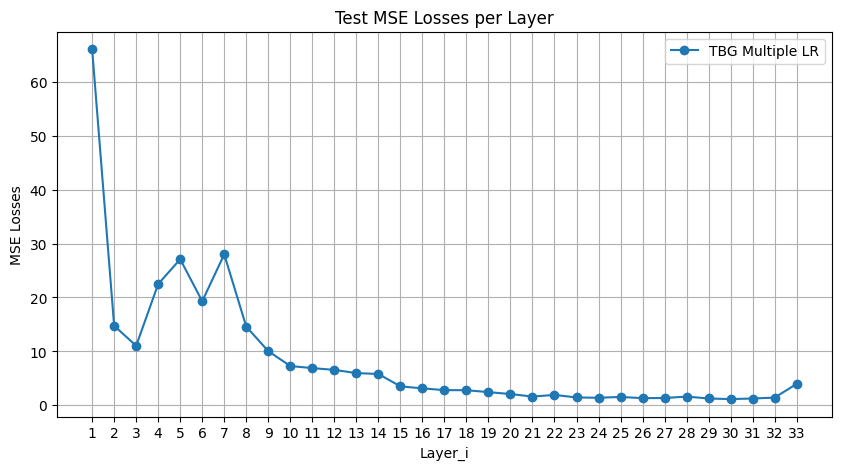

In [171]:
# Plot the 1-D pooled test losses
from datetime import datetime

def plot_1d_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name} per Layer')
    plt.xlabel('Layer_i')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices)  # Assuming all models have the same number of layers
    plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/test_{metric_name}_per_layer_for_{"_".join(model_names)}_{formatted_time}.jpg')
    plt.show()

plot_1d_metrics([lr_test_losses], ['TBG Multiple LR'])

Models trained on **later layer** embeddings achieved lower losses (as low as **~1.0**) on the pooled test set, with the last 10 layers having roughly the same performances.

How about training all layers with a single model instantiation?

Using device: cuda
Training on Dataset 1/33
Epoch 1/100, Training Loss: 0.9574, Validation Loss: 1.0545
Epoch 10/100, Training Loss: 0.7081, Validation Loss: 0.8686
Epoch 20/100, Training Loss: 0.6182, Validation Loss: 0.8692
Epoch 30/100, Training Loss: 0.5626, Validation Loss: 0.8738
Epoch 40/100, Training Loss: 0.5298, Validation Loss: 0.8834
Epoch 50/100, Training Loss: 0.5070, Validation Loss: 0.8959
Epoch 60/100, Training Loss: 0.4918, Validation Loss: 0.9085
Epoch 70/100, Training Loss: 0.4807, Validation Loss: 0.9115
Epoch 80/100, Training Loss: 0.4727, Validation Loss: 0.9224
Epoch 90/100, Training Loss: 0.4699, Validation Loss: 0.9323
Epoch 100/100, Training Loss: 0.4685, Validation Loss: 0.9318
Test Loss: 91.2676
Training on Dataset 2/33
Epoch 1/100, Training Loss: 3.3538, Validation Loss: 3.7534
Epoch 10/100, Training Loss: 0.8898, Validation Loss: 2.2717
Epoch 20/100, Training Loss: 0.5850, Validation Loss: 2.0023
Epoch 30/100, Training Loss: 0.4956, Validation Loss: 1.904

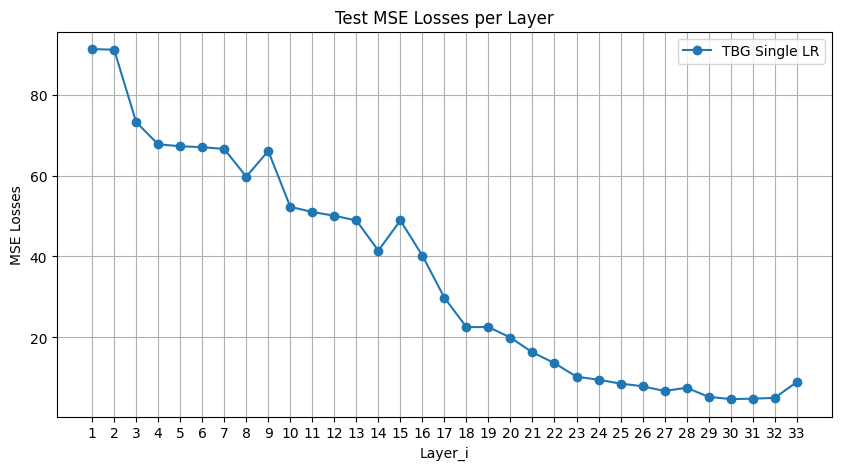

In [109]:
# Training with a single LR on all layer's datasets.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
tlr_test_losses = []
model = LinearModel(in_dim, out_dim)

for i, (train_loader, valid_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders)):
    print(f"Training on Dataset {i+1}/{len(tbg_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, epochs=epochs, title=f"LR on Dataset {i+1}", silent=True)
    test_loss = evaluate_on_test(model, tbg_pooled_test_dataloader, device)
    tlr_test_losses.append(test_loss)

plot_1d_metrics([tlr_test_losses], ['TBG Single LR'], 'MSE Losses')

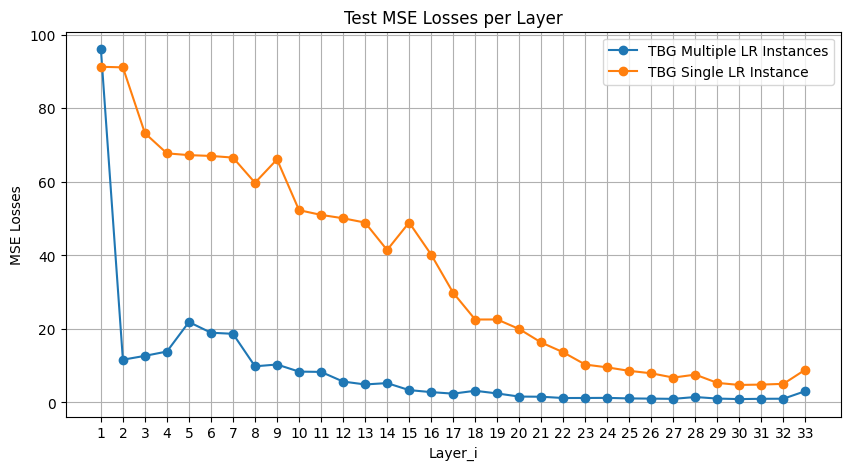

In [110]:
plot_1d_metrics([lr_test_losses, tlr_test_losses], ['TBG Multiple LR Instances','TBG Single LR Instance'], 'MSE Losses')

In [ ]:
# Training Loops: MLP for each layer.
in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
mlp_test_losses = []

for i, (train_loader, valid_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders)):
    model = MLP(in_dim, hid_dims, out_dim, dropout) 
    print(f"Training on Dataset {i+1}/{len(tbg_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, epochs=epochs, title=f"MLP on Dataset {i+1}")
    test_loss = evaluate_on_test(model, tbg_pooled_test_dataloader, device)
    mlp_test_losses.append(test_loss)

plot_1d_metrics([mlp_test_losses], ['TBG Multiple MLP'], 'MSE Losses')

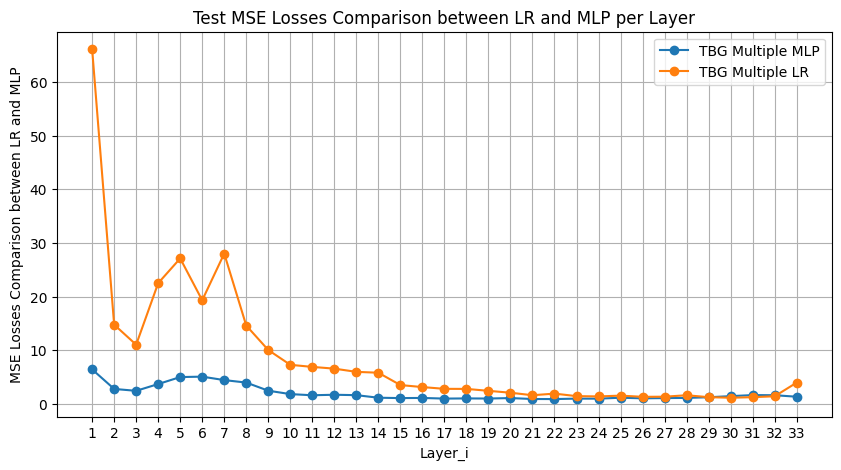

In [173]:
# Plot metrics (comparison between MLP and LR trained layer by layer, on pooled test set)
plot_1d_metrics([mlp_test_losses, lr_test_losses], ['TBG Multiple MLP', 'TBG Multiple LR'], "MSE Losses Comparison between LR and MLP")

Using device: cuda
Training on Dataset 1/33
Epoch 1/100, Training Loss: 1.2954, Validation Loss: 0.8320
Epoch 10/100, Training Loss: 0.6448, Validation Loss: 0.8571
Epoch 20/100, Training Loss: 0.5644, Validation Loss: 0.8761
Epoch 30/100, Training Loss: 0.5557, Validation Loss: 0.8454
Epoch 40/100, Training Loss: 0.5522, Validation Loss: 0.8909
Epoch 50/100, Training Loss: 0.5372, Validation Loss: 0.8921
Epoch 60/100, Training Loss: 0.5262, Validation Loss: 0.8700
Epoch 70/100, Training Loss: 0.5249, Validation Loss: 0.9174
Epoch 80/100, Training Loss: 0.5371, Validation Loss: 0.9055
Epoch 90/100, Training Loss: 0.5279, Validation Loss: 0.9106
Epoch 100/100, Training Loss: 0.5317, Validation Loss: 0.9100
Test Loss: 3.5118
Training on Dataset 2/33
Epoch 1/100, Training Loss: 0.8686, Validation Loss: 0.7985
Epoch 10/100, Training Loss: 0.4974, Validation Loss: 0.8342
Epoch 20/100, Training Loss: 0.4597, Validation Loss: 0.7603
Epoch 30/100, Training Loss: 0.4480, Validation Loss: 0.9506

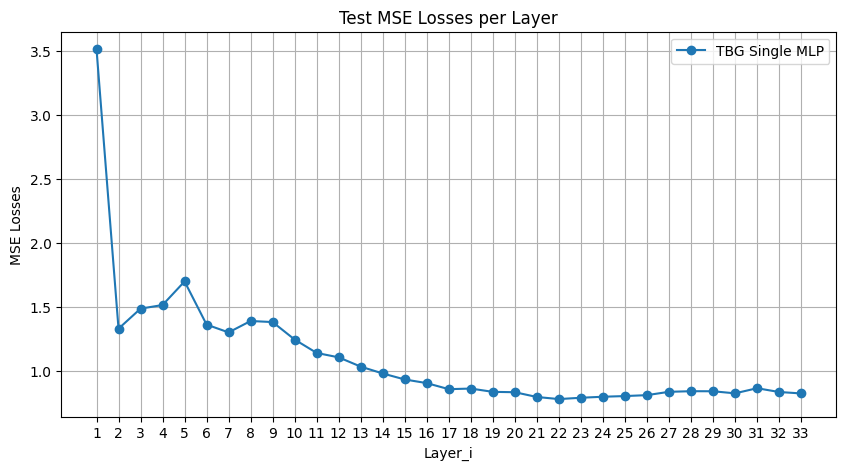

In [174]:
# Training with a single MLP on all datasets.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
tmlp_test_losses = []
model = MLP(in_dim, hid_dims, out_dim, dropout) 

for i, (train_loader, valid_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders)):
    print(f"Training on Dataset {i+1}/{len(tbg_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, epochs=epochs, title=f"LR on Dataset {i+1}", silent=True)
    test_loss = evaluate_on_test(model, tbg_pooled_test_dataloader, device)
    tmlp_test_losses.append(test_loss)

plot_1d_metrics([tmlp_test_losses], ['TBG Single MLP'], 'MSE Losses')

We see that it works better with MLP continually trained on all 33 layer embeddings and tested on the pooled test set. 

It is reasonable to conjecture that shuffling embeddings across layers would let the model generalize even better.

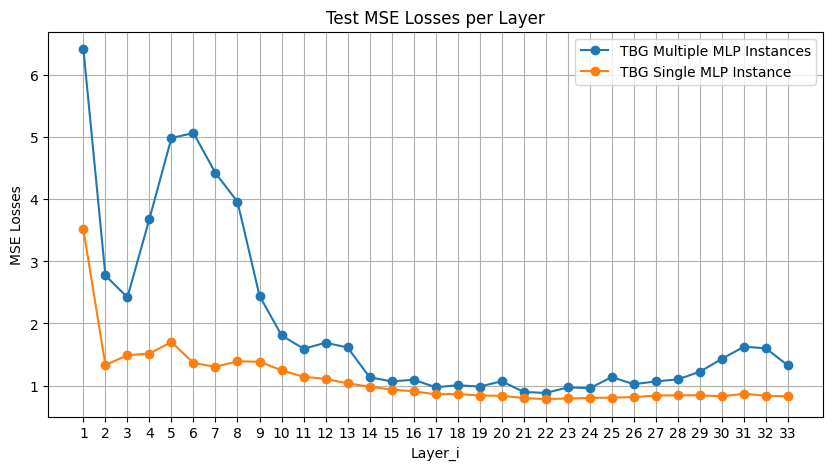

In [175]:
plot_1d_metrics([mlp_test_losses, tmlp_test_losses], ['TBG Multiple MLP Instances','TBG Single MLP Instance'], 'MSE Losses')

#### Binarize Entropy and Predict with Logistic Regression

We try binarizing the entropy scores and use logistic regression as with the accuracy prediction.

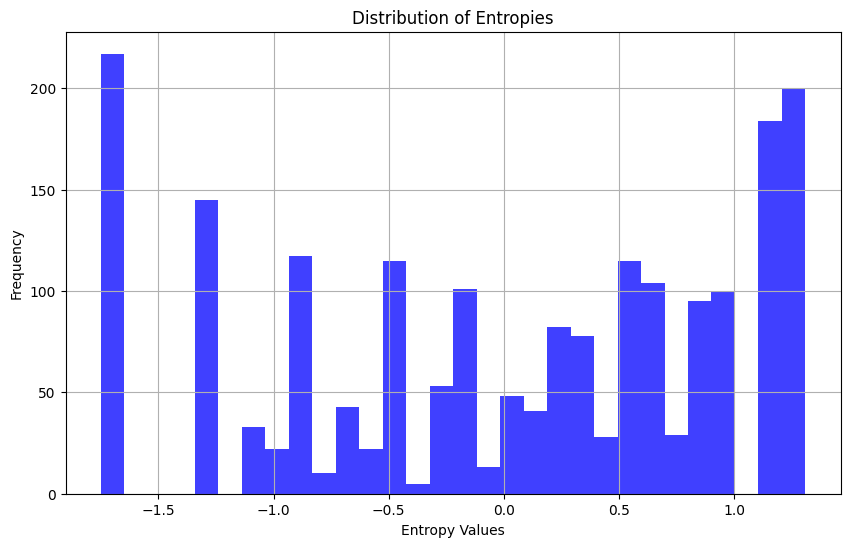

tensor(-1.7497) tensor(1.3102) tensor(1.0000) tensor(-1.3280e-07)


In [32]:
# Plot the entropy distribution
def plot_entropy_distribution(entropies):
    entropies_np = entropies.numpy()
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(entropies_np, bins=30, alpha=0.75, color='blue')
    plt.title('Distribution of Entropies')  # Title of the histogram
    plt.xlabel('Entropy Values')  # Label for the x-axis
    plt.ylabel('Frequency')  # Label for the y-axis
    plt.grid(True) 
    plt.show()

plot_entropy_distribution(ca_entropy)
print(ca_entropy.min(), ca_entropy.max(), ca_entropy.var(), ca_entropy.mean())

def binarize_entropy(entropies, thres=0.0):
    binary_entropies = torch.full_like(entropies, -1, dtype=torch.float)
    binary_entropies[entropies < thres] = 0
    binary_entropies[entropies > thres] = 1

    return binary_entropies

bca_entropy = binarize_entropy(ca_entropy, 0.0)

We observe bimodal distribution for the normalized entropy values. The distribution is slightly skewed. **We decide to bin at 0.0 for even splits for now.**

In [33]:
# Fractions of 1's for binarized entropy: ~55%
print(sum(bca_entropy)/len(bca_entropy))

tensor(0.5505)


In [138]:
# Train logistic regression model for binarized entropy
# Since we have empirically shown better performances of single model instantiation than multiples, we stick to training one LR or MLP for binarized case.
class LogisticRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LogisticRegression, self).__init__()
        self.linear = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        logits = self.linear(x)
        probabilities = torch.sigmoid(logits)
        return probabilities

class MLPClassifier(MLP):
    def __init__(self, in_dim, hid_dims, dropout):
        super().__init__(in_dim, hid_dims, out_dim=1, dropout=dropout)

    def forward(self, x):
        x = super().forward(x)
        x = torch.sigmoid(x) 
        return x

# Prepare new dataloaders for binarized case (NOTE: naming conflict)
tbg_train_dataloaders, tbg_valid_dataloaders, tbg_pooled_test_dataloader = create_dataloaders(tok_bef_gen_layered_datasets, bca_entropy, total_size, batch_size)

Using device: cuda
Training on Dataset 1/33
Epoch 1/100, Training Loss: 60.7996, Validation Loss: 47.8783, Training Accuracy: 0.6007
Epoch 10/100, Training Loss: 60.0455, Validation Loss: 47.6268, Training Accuracy: 0.6807
Epoch 20/100, Training Loss: 59.6673, Validation Loss: 47.6101, Training Accuracy: 0.7079
Epoch 30/100, Training Loss: 59.4453, Validation Loss: 47.6228, Training Accuracy: 0.7279
Epoch 40/100, Training Loss: 59.1864, Validation Loss: 47.6378, Training Accuracy: 0.7479
Epoch 50/100, Training Loss: 59.0922, Validation Loss: 47.6498, Training Accuracy: 0.7593
Epoch 60/100, Training Loss: 58.9394, Validation Loss: 47.6712, Training Accuracy: 0.7671
Epoch 70/100, Training Loss: 58.8276, Validation Loss: 47.6761, Training Accuracy: 0.7736
Epoch 80/100, Training Loss: 58.7518, Validation Loss: 47.6892, Training Accuracy: 0.7764
Epoch 90/100, Training Loss: 58.6528, Validation Loss: 47.6935, Training Accuracy: 0.7771
Epoch 100/100, Training Loss: 58.6011, Validation Loss: 4

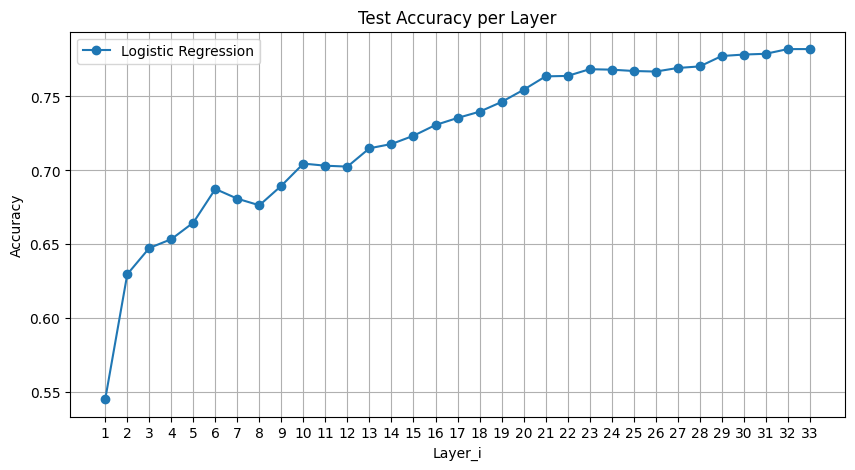

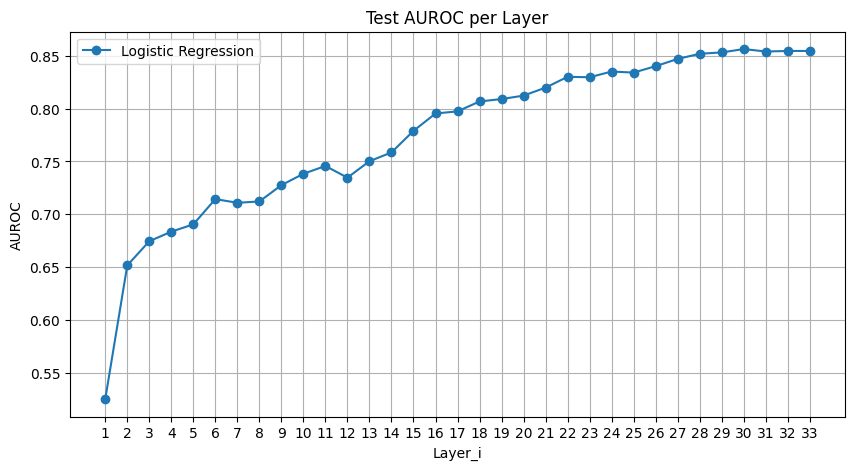

In [139]:
# Training with a single LR on all datasets.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
tblr_test_accs = []
tblr_test_aucs = []

model = LogisticRegression(in_dim, out_dim)

for i, (train_loader, valid_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders)):
    print(f"Training on Dataset {i+1}/{len(tbg_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"Logistic Regression on Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(model, tbg_pooled_test_dataloader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tblr_test_accs.append(test_acc)
    tblr_test_aucs.append(test_auc)

plot_1d_metrics([tblr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tblr_test_aucs], ['Logistic Regression'], 'AUROC')

Using device: cuda
Training on Dataset 1/33
Epoch 1/100, Training Loss: 60.6721, Validation Loss: 47.6005, Training Accuracy: 0.5757
Epoch 10/100, Training Loss: 58.3835, Validation Loss: 47.7621, Training Accuracy: 0.7593
Epoch 20/100, Training Loss: 58.2064, Validation Loss: 48.1364, Training Accuracy: 0.7650
Epoch 30/100, Training Loss: 58.1293, Validation Loss: 48.3068, Training Accuracy: 0.7786
Epoch 40/100, Training Loss: 58.0811, Validation Loss: 48.3447, Training Accuracy: 0.7721
Epoch 50/100, Training Loss: 58.0336, Validation Loss: 48.0813, Training Accuracy: 0.7679
Epoch 60/100, Training Loss: 57.9833, Validation Loss: 48.0434, Training Accuracy: 0.7829
Epoch 70/100, Training Loss: 58.0082, Validation Loss: 48.3062, Training Accuracy: 0.7757
Epoch 80/100, Training Loss: 57.9946, Validation Loss: 48.2430, Training Accuracy: 0.7707
Epoch 90/100, Training Loss: 57.9513, Validation Loss: 48.2813, Training Accuracy: 0.7800
Epoch 100/100, Training Loss: 57.9853, Validation Loss: 4

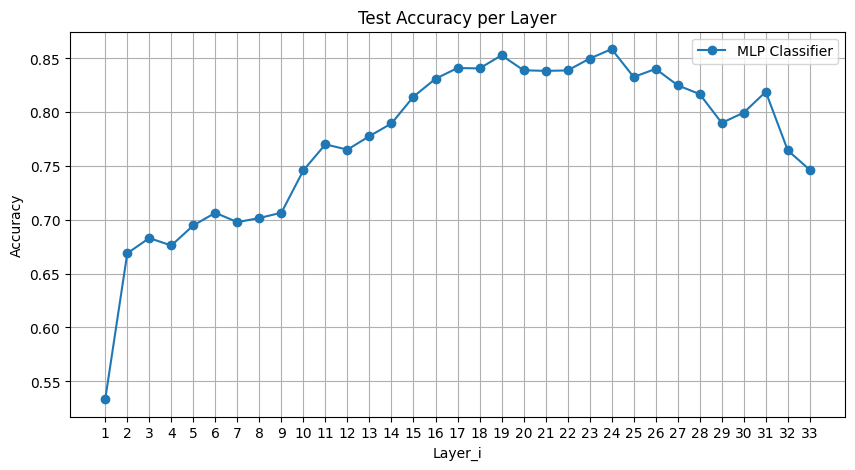

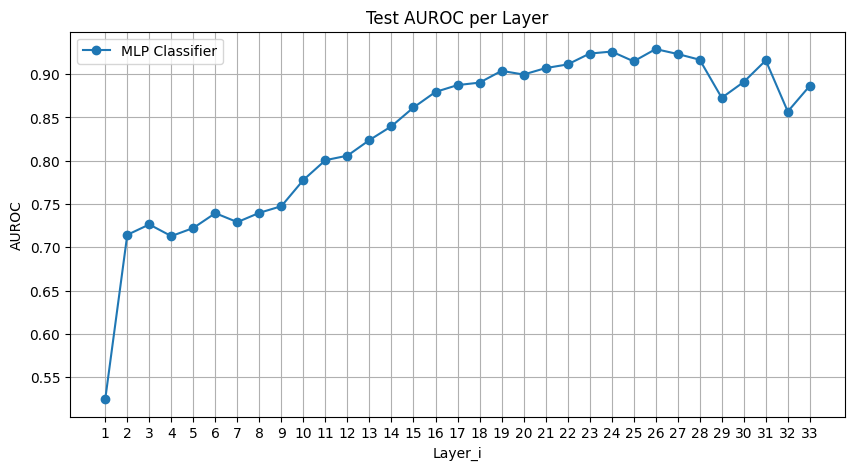

In [140]:
# Training with a single MLP on all datasets.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
tbmlp_test_accs = []
tbmlp_test_aucs = []
model = MLPClassifier(in_dim, hid_dims, dropout)

for i, (train_loader, valid_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders)):
    print(f"Training on Dataset {i+1}/{len(tbg_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(model, tbg_pooled_test_dataloader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tbmlp_test_accs.append(test_acc)
    tbmlp_test_aucs.append(test_auc)

plot_1d_metrics([tbmlp_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([tbmlp_test_aucs], ['MLP Classifier'], 'AUROC')

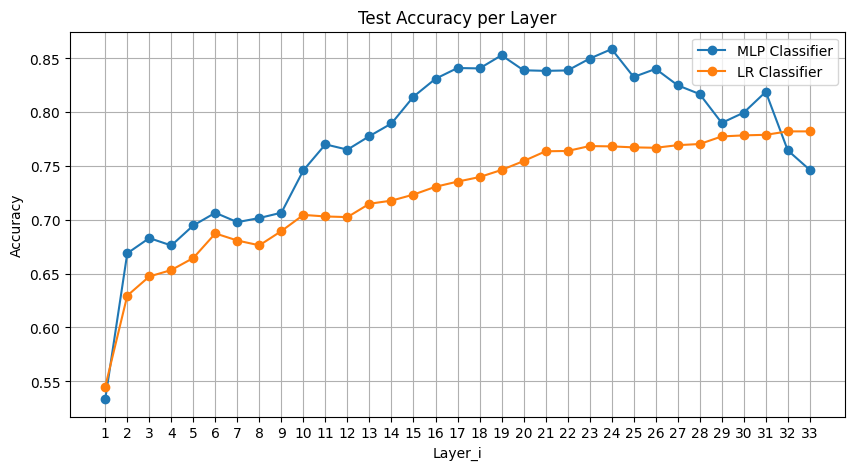

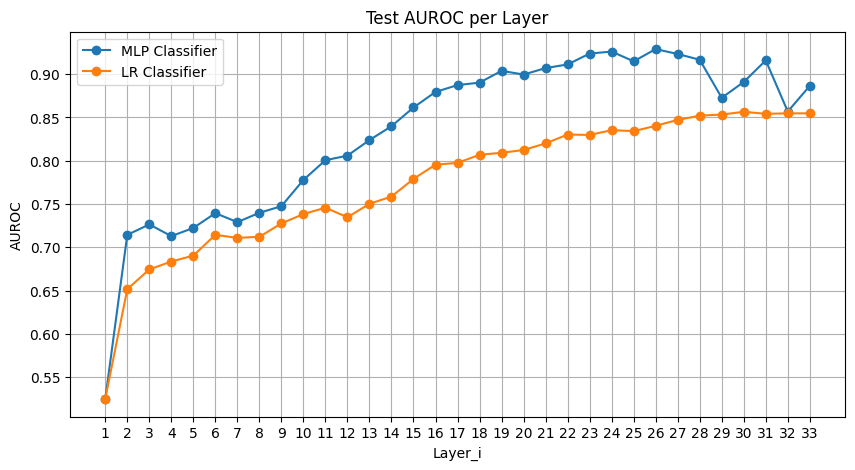

In [141]:
plot_1d_metrics([tbmlp_test_accs, tblr_test_accs], ['MLP Classifier','LR Classifier'], 'Accuracy')
plot_1d_metrics([tbmlp_test_aucs, tblr_test_aucs], ['MLP Classifier','LR Classifier'], 'AUROC')

### Explore Second Last generated Token (SLT)


In [40]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([2000, 33, 4544])


In [41]:
sec_last_tok_dataset.transpose(0, 1).shape

torch.Size([33, 2000, 4544])

In [42]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 2000, 4544]) torch.float32


In [44]:
# We may want to drop the first layer due to its homogeneity in values.
# print(slt_layered_datasets[0], slt_layered_datasets[0].shape)
slt_layered_datasets = slt_layered_datasets[1:]

In [118]:
# Inherit from previous section
# Make batched inputs and dataloaders (one for each layer)
total_size = 2000
batch_size = 32

slt_train_dataloaders, slt_valid_dataloaders, slt_pooled_test_dataloader = create_dataloaders(slt_layered_datasets, ca_entropy, total_size, batch_size)

Using device: cuda
Training on SLT Dataset 1/32
Epoch 1/100, Training Loss: 1.0289, Validation Loss: 0.9629
Epoch 10/100, Training Loss: 0.8844, Validation Loss: 0.9112
Epoch 20/100, Training Loss: 0.8346, Validation Loss: 0.9381
Epoch 30/100, Training Loss: 0.8092, Validation Loss: 0.9455
Epoch 40/100, Training Loss: 0.7947, Validation Loss: 0.9430
Epoch 50/100, Training Loss: 0.7703, Validation Loss: 0.9791
Epoch 60/100, Training Loss: 0.7608, Validation Loss: 0.9439
Epoch 70/100, Training Loss: 0.7411, Validation Loss: 0.9538
Epoch 80/100, Training Loss: 0.7444, Validation Loss: 0.9652
Epoch 90/100, Training Loss: 0.7377, Validation Loss: 1.0076
Epoch 100/100, Training Loss: 0.7212, Validation Loss: 0.9680


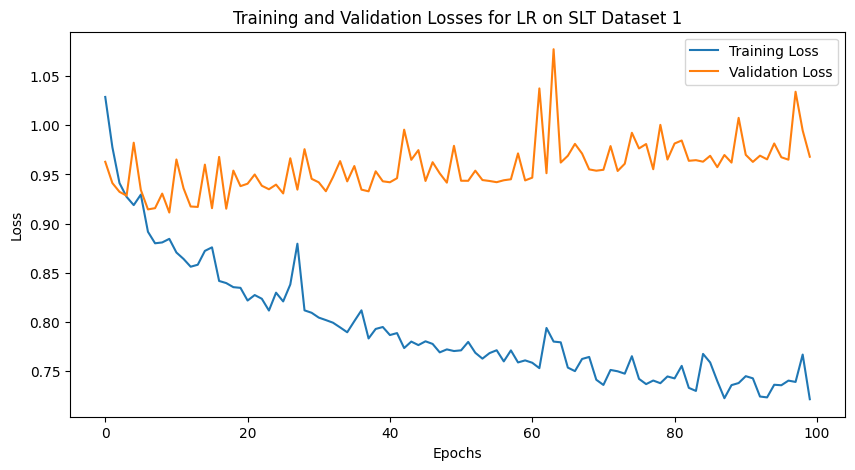

Test Loss: 39.0015
Training on SLT Dataset 2/32
Epoch 1/100, Training Loss: 1.0110, Validation Loss: 0.8915
Epoch 10/100, Training Loss: 0.9009, Validation Loss: 1.0853
Epoch 20/100, Training Loss: 0.8610, Validation Loss: 0.8687
Epoch 30/100, Training Loss: 0.8548, Validation Loss: 0.8612
Epoch 40/100, Training Loss: 0.8305, Validation Loss: 0.8744
Epoch 50/100, Training Loss: 0.8079, Validation Loss: 0.8606
Epoch 60/100, Training Loss: 0.8345, Validation Loss: 0.8770
Epoch 70/100, Training Loss: 0.7816, Validation Loss: 0.8702
Epoch 80/100, Training Loss: 0.8148, Validation Loss: 0.8829
Epoch 90/100, Training Loss: 0.7888, Validation Loss: 0.8413
Epoch 100/100, Training Loss: 0.7541, Validation Loss: 0.8384


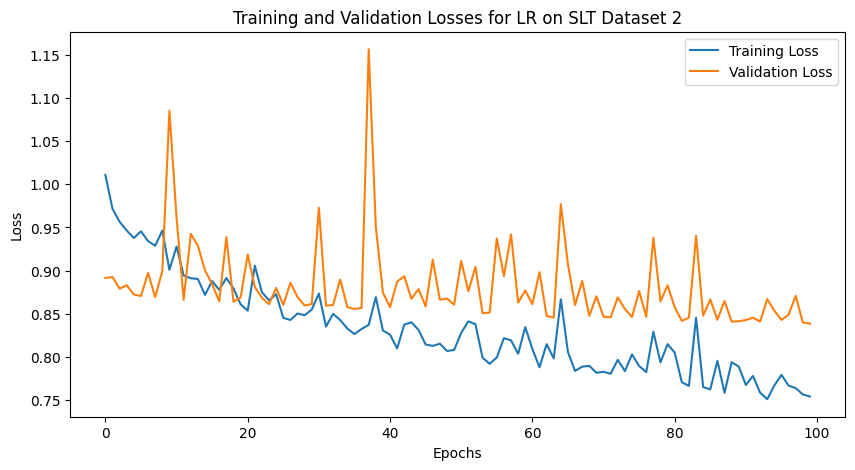

Test Loss: 25.9950
Training on SLT Dataset 3/32
Epoch 1/100, Training Loss: 0.9850, Validation Loss: 0.9708
Epoch 10/100, Training Loss: 0.8842, Validation Loss: 0.8674
Epoch 20/100, Training Loss: 0.8399, Validation Loss: 0.8380
Epoch 30/100, Training Loss: 0.7963, Validation Loss: 1.0249
Epoch 40/100, Training Loss: 0.7631, Validation Loss: 0.8803
Epoch 50/100, Training Loss: 0.7473, Validation Loss: 0.8164
Epoch 60/100, Training Loss: 0.7404, Validation Loss: 0.8469
Epoch 70/100, Training Loss: 0.7151, Validation Loss: 0.9175
Epoch 80/100, Training Loss: 0.7108, Validation Loss: 1.0113
Epoch 90/100, Training Loss: 0.7568, Validation Loss: 1.0021
Epoch 100/100, Training Loss: 0.6735, Validation Loss: 0.8064


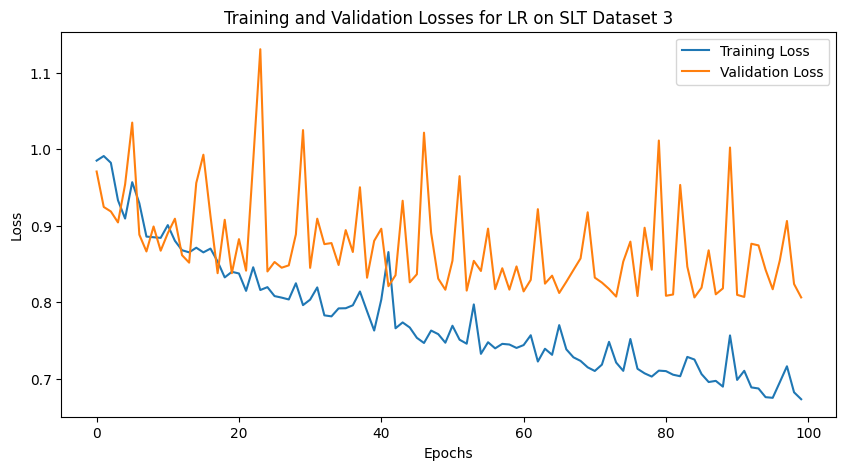

Test Loss: 23.4717
Training on SLT Dataset 4/32
Epoch 1/100, Training Loss: 1.0475, Validation Loss: 0.8580
Epoch 10/100, Training Loss: 0.8462, Validation Loss: 0.8055
Epoch 20/100, Training Loss: 0.8135, Validation Loss: 0.8027
Epoch 30/100, Training Loss: 0.7539, Validation Loss: 0.8125
Epoch 40/100, Training Loss: 0.7034, Validation Loss: 0.8655
Epoch 50/100, Training Loss: 0.6958, Validation Loss: 0.8000
Epoch 60/100, Training Loss: 0.6642, Validation Loss: 0.8021
Epoch 70/100, Training Loss: 0.6472, Validation Loss: 0.8404
Epoch 80/100, Training Loss: 0.6524, Validation Loss: 0.8017
Epoch 90/100, Training Loss: 0.6307, Validation Loss: 0.8153
Epoch 100/100, Training Loss: 0.6109, Validation Loss: 0.8269


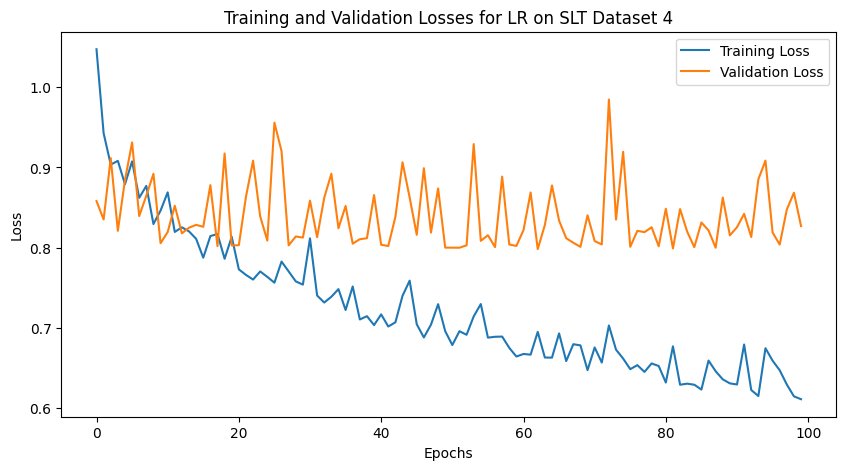

Test Loss: 19.0357
Training on SLT Dataset 5/32
Epoch 1/100, Training Loss: 1.0106, Validation Loss: 0.8441
Epoch 10/100, Training Loss: 0.7935, Validation Loss: 0.7363
Epoch 20/100, Training Loss: 0.7164, Validation Loss: 0.7207
Epoch 30/100, Training Loss: 0.6655, Validation Loss: 0.7375
Epoch 40/100, Training Loss: 0.7091, Validation Loss: 0.8179
Epoch 50/100, Training Loss: 0.5999, Validation Loss: 0.7241
Epoch 60/100, Training Loss: 0.5805, Validation Loss: 0.7368
Epoch 70/100, Training Loss: 0.5515, Validation Loss: 0.7338
Epoch 80/100, Training Loss: 0.5469, Validation Loss: 0.7606
Epoch 90/100, Training Loss: 0.5186, Validation Loss: 0.7391
Epoch 100/100, Training Loss: 0.5081, Validation Loss: 0.7624


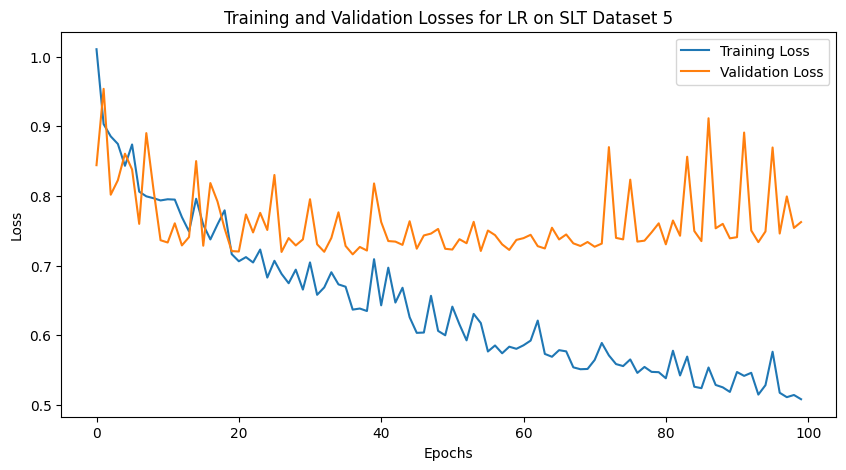

Test Loss: 19.1548
Training on SLT Dataset 6/32
Epoch 1/100, Training Loss: 0.9833, Validation Loss: 1.2034
Epoch 10/100, Training Loss: 0.7845, Validation Loss: 0.9542
Epoch 20/100, Training Loss: 0.7410, Validation Loss: 0.9827
Epoch 30/100, Training Loss: 0.6465, Validation Loss: 0.9251
Epoch 40/100, Training Loss: 0.6159, Validation Loss: 0.8983
Epoch 50/100, Training Loss: 0.5819, Validation Loss: 0.9490
Epoch 60/100, Training Loss: 0.5648, Validation Loss: 0.8733
Epoch 70/100, Training Loss: 0.5640, Validation Loss: 0.9159
Epoch 80/100, Training Loss: 0.5163, Validation Loss: 0.8798
Epoch 90/100, Training Loss: 0.5511, Validation Loss: 0.9623
Epoch 100/100, Training Loss: 0.5038, Validation Loss: 0.8871


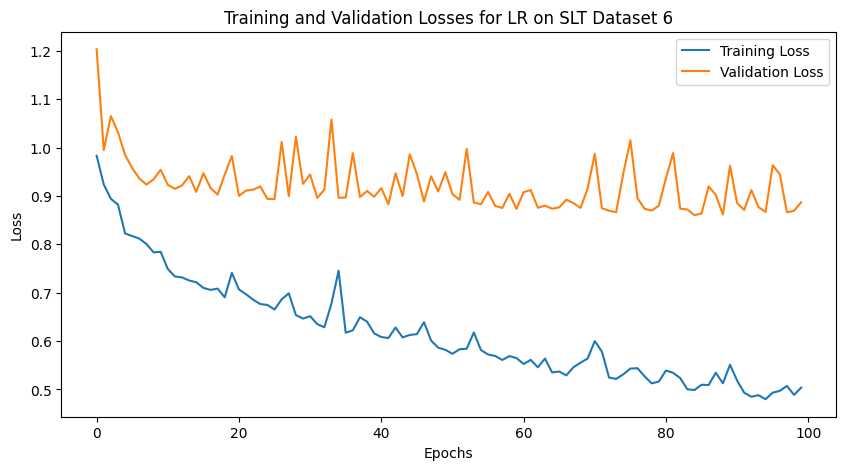

Test Loss: 19.8380
Training on SLT Dataset 7/32
Epoch 1/100, Training Loss: 1.0151, Validation Loss: 0.7210
Epoch 10/100, Training Loss: 0.7017, Validation Loss: 0.7144
Epoch 20/100, Training Loss: 0.6546, Validation Loss: 0.7065
Epoch 30/100, Training Loss: 0.5759, Validation Loss: 0.8053
Epoch 40/100, Training Loss: 0.5226, Validation Loss: 0.8077
Epoch 50/100, Training Loss: 0.4739, Validation Loss: 0.7409
Epoch 60/100, Training Loss: 0.4466, Validation Loss: 0.7939
Epoch 70/100, Training Loss: 0.4172, Validation Loss: 0.7476
Epoch 80/100, Training Loss: 0.4554, Validation Loss: 0.7845
Epoch 90/100, Training Loss: 0.3798, Validation Loss: 0.8158
Epoch 100/100, Training Loss: 0.3833, Validation Loss: 0.8149


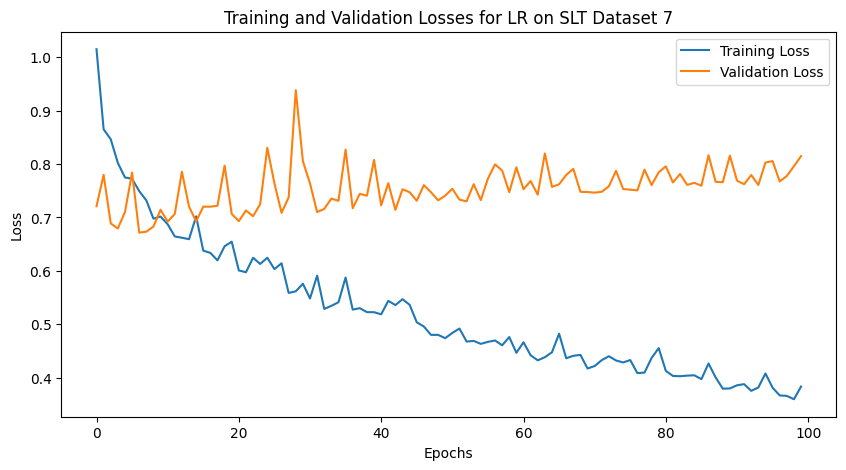

Test Loss: 17.2724
Training on SLT Dataset 8/32
Epoch 1/100, Training Loss: 1.0571, Validation Loss: 0.9932
Epoch 10/100, Training Loss: 0.6690, Validation Loss: 0.8537
Epoch 20/100, Training Loss: 0.5620, Validation Loss: 0.8917
Epoch 30/100, Training Loss: 0.5202, Validation Loss: 0.9038
Epoch 40/100, Training Loss: 0.4553, Validation Loss: 0.9080
Epoch 50/100, Training Loss: 0.3982, Validation Loss: 0.9379
Epoch 60/100, Training Loss: 0.3757, Validation Loss: 0.9445
Epoch 70/100, Training Loss: 0.3435, Validation Loss: 0.9562
Epoch 80/100, Training Loss: 0.3111, Validation Loss: 0.9868
Epoch 90/100, Training Loss: 0.3190, Validation Loss: 0.9987
Epoch 100/100, Training Loss: 0.2840, Validation Loss: 1.0220


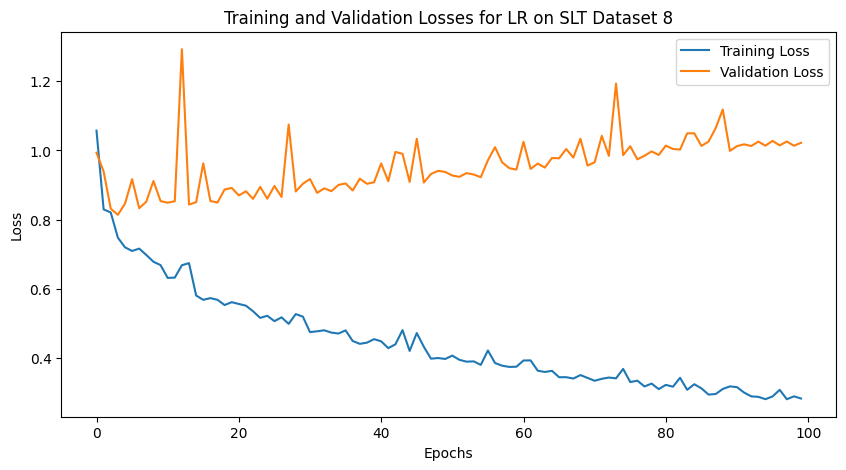

Test Loss: 18.0309
Training on SLT Dataset 9/32
Epoch 1/100, Training Loss: 0.9465, Validation Loss: 0.7346
Epoch 10/100, Training Loss: 0.6059, Validation Loss: 0.7180
Epoch 20/100, Training Loss: 0.5672, Validation Loss: 0.7541
Epoch 30/100, Training Loss: 0.5369, Validation Loss: 0.7988
Epoch 40/100, Training Loss: 0.4110, Validation Loss: 0.7950
Epoch 50/100, Training Loss: 0.3750, Validation Loss: 0.8077
Epoch 60/100, Training Loss: 0.3190, Validation Loss: 0.8313
Epoch 70/100, Training Loss: 0.2973, Validation Loss: 0.8556
Epoch 80/100, Training Loss: 0.2851, Validation Loss: 1.0697
Epoch 90/100, Training Loss: 0.2674, Validation Loss: 0.9317
Epoch 100/100, Training Loss: 0.2393, Validation Loss: 0.9565


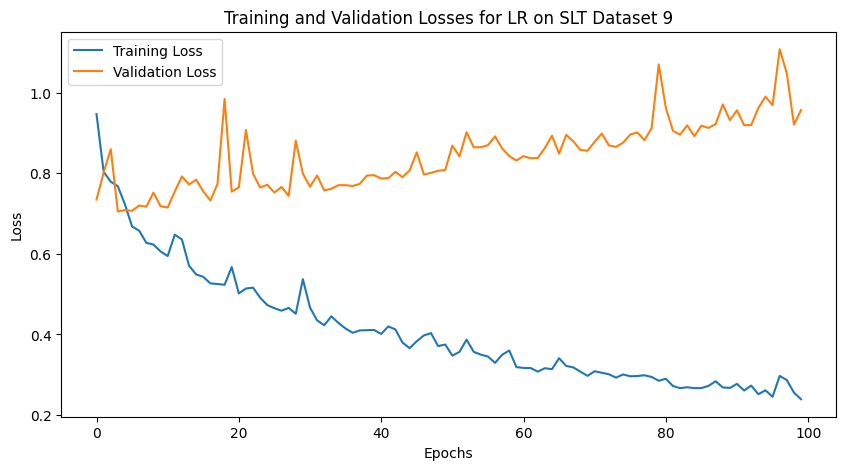

Test Loss: 15.6321
Training on SLT Dataset 10/32
Epoch 1/100, Training Loss: 1.0077, Validation Loss: 0.9723
Epoch 10/100, Training Loss: 0.5992, Validation Loss: 0.7682
Epoch 20/100, Training Loss: 0.4984, Validation Loss: 0.8335
Epoch 30/100, Training Loss: 0.4533, Validation Loss: 0.7226
Epoch 40/100, Training Loss: 0.3908, Validation Loss: 0.7108
Epoch 50/100, Training Loss: 0.3754, Validation Loss: 0.7015
Epoch 60/100, Training Loss: 0.3244, Validation Loss: 0.6946
Epoch 70/100, Training Loss: 0.2898, Validation Loss: 0.7511
Epoch 80/100, Training Loss: 0.2618, Validation Loss: 0.6973
Epoch 90/100, Training Loss: 0.2470, Validation Loss: 0.7400
Epoch 100/100, Training Loss: 0.2329, Validation Loss: 0.7117


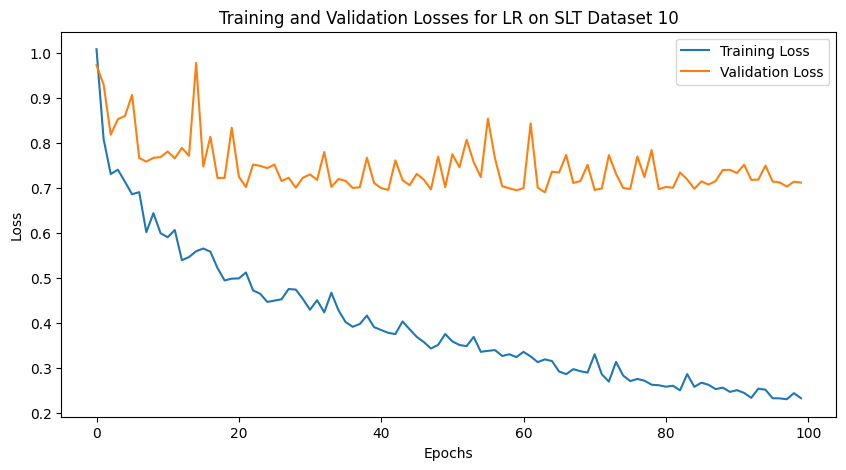

Test Loss: 12.3994
Training on SLT Dataset 11/32
Epoch 1/100, Training Loss: 0.9810, Validation Loss: 0.8563
Epoch 10/100, Training Loss: 0.5455, Validation Loss: 0.8711
Epoch 20/100, Training Loss: 0.4223, Validation Loss: 0.7723
Epoch 30/100, Training Loss: 0.3639, Validation Loss: 0.7929
Epoch 40/100, Training Loss: 0.3175, Validation Loss: 0.7948
Epoch 50/100, Training Loss: 0.2713, Validation Loss: 0.7932
Epoch 60/100, Training Loss: 0.2806, Validation Loss: 0.8099
Epoch 70/100, Training Loss: 0.2172, Validation Loss: 0.8454
Epoch 80/100, Training Loss: 0.1944, Validation Loss: 0.8527
Epoch 90/100, Training Loss: 0.1887, Validation Loss: 0.8505
Epoch 100/100, Training Loss: 0.1783, Validation Loss: 0.8906


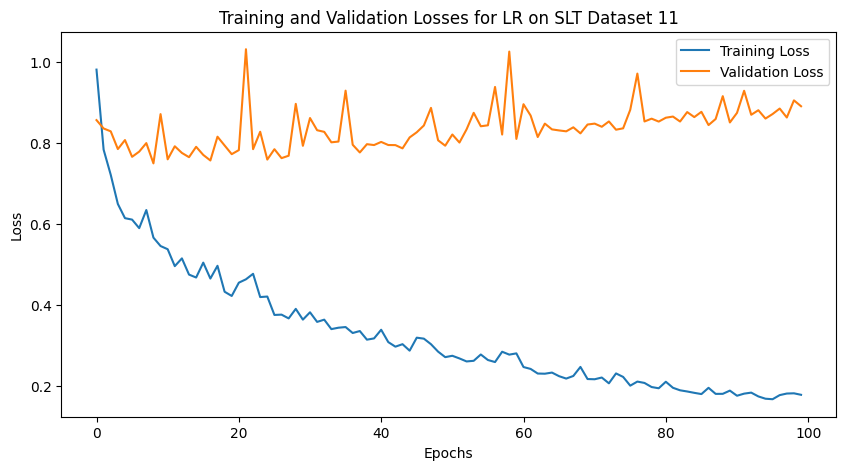

Test Loss: 14.1727
Training on SLT Dataset 12/32
Epoch 1/100, Training Loss: 0.9608, Validation Loss: 0.7697
Epoch 10/100, Training Loss: 0.5327, Validation Loss: 0.7866
Epoch 20/100, Training Loss: 0.4176, Validation Loss: 0.7878
Epoch 30/100, Training Loss: 0.3498, Validation Loss: 0.7926
Epoch 40/100, Training Loss: 0.3016, Validation Loss: 0.8231
Epoch 50/100, Training Loss: 0.2395, Validation Loss: 0.8988
Epoch 60/100, Training Loss: 0.2416, Validation Loss: 0.9013
Epoch 70/100, Training Loss: 0.2007, Validation Loss: 0.8731
Epoch 80/100, Training Loss: 0.1541, Validation Loss: 0.8834
Epoch 90/100, Training Loss: 0.1399, Validation Loss: 0.8851
Epoch 100/100, Training Loss: 0.1204, Validation Loss: 0.8833


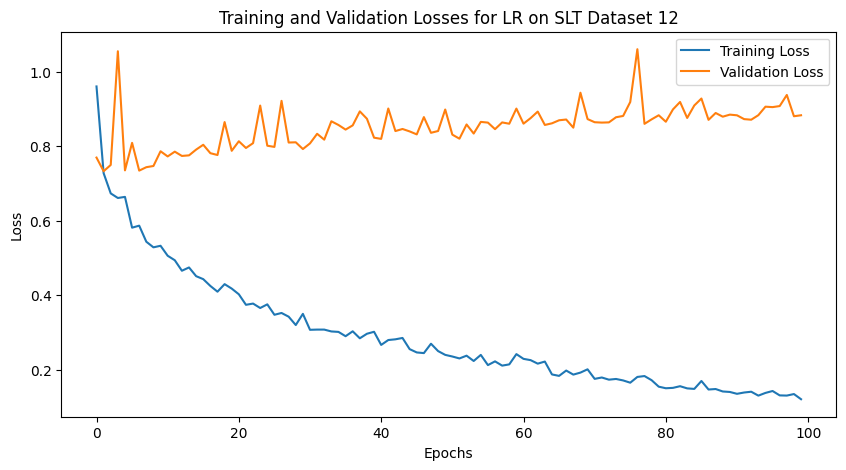

Test Loss: 12.6347
Training on SLT Dataset 13/32
Epoch 1/100, Training Loss: 0.9505, Validation Loss: 0.7016
Epoch 10/100, Training Loss: 0.4636, Validation Loss: 0.7211
Epoch 20/100, Training Loss: 0.3453, Validation Loss: 0.6873
Epoch 30/100, Training Loss: 0.2741, Validation Loss: 0.7029
Epoch 40/100, Training Loss: 0.2595, Validation Loss: 0.7395
Epoch 50/100, Training Loss: 0.2207, Validation Loss: 0.7954
Epoch 60/100, Training Loss: 0.1686, Validation Loss: 0.8225
Epoch 70/100, Training Loss: 0.1433, Validation Loss: 0.8497
Epoch 80/100, Training Loss: 0.1265, Validation Loss: 0.8428
Epoch 90/100, Training Loss: 0.1408, Validation Loss: 1.0101
Epoch 100/100, Training Loss: 0.1000, Validation Loss: 0.9531


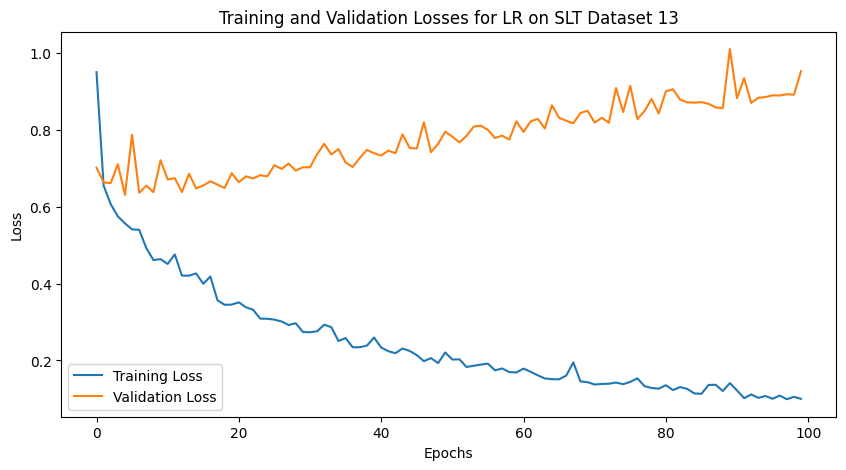

Test Loss: 13.3219
Training on SLT Dataset 14/32
Epoch 1/100, Training Loss: 1.0538, Validation Loss: 0.9065
Epoch 10/100, Training Loss: 0.3516, Validation Loss: 0.8204
Epoch 20/100, Training Loss: 0.2734, Validation Loss: 0.7745
Epoch 30/100, Training Loss: 0.1711, Validation Loss: 0.8417
Epoch 40/100, Training Loss: 0.1285, Validation Loss: 0.8855
Epoch 50/100, Training Loss: 0.0948, Validation Loss: 0.8786
Epoch 60/100, Training Loss: 0.0699, Validation Loss: 0.9409
Epoch 70/100, Training Loss: 0.0567, Validation Loss: 0.9934
Epoch 80/100, Training Loss: 0.0530, Validation Loss: 1.0212
Epoch 90/100, Training Loss: 0.0346, Validation Loss: 1.0565
Epoch 100/100, Training Loss: 0.0345, Validation Loss: 1.0940


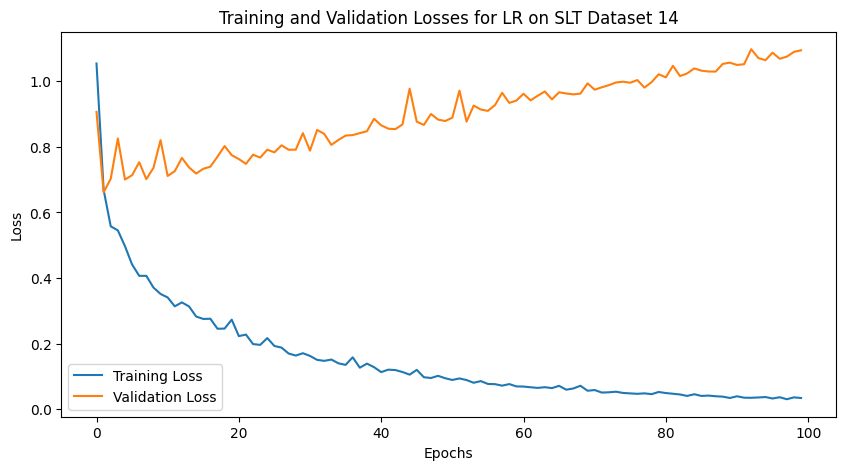

Test Loss: 6.5008
Training on SLT Dataset 15/32
Epoch 1/100, Training Loss: 0.8259, Validation Loss: 0.5599
Epoch 10/100, Training Loss: 0.3110, Validation Loss: 0.5520
Epoch 20/100, Training Loss: 0.1905, Validation Loss: 0.6058
Epoch 30/100, Training Loss: 0.1371, Validation Loss: 0.6696
Epoch 40/100, Training Loss: 0.1051, Validation Loss: 0.7034
Epoch 50/100, Training Loss: 0.0960, Validation Loss: 0.7896
Epoch 60/100, Training Loss: 0.0552, Validation Loss: 0.7740
Epoch 70/100, Training Loss: 0.0461, Validation Loss: 0.7863
Epoch 80/100, Training Loss: 0.0455, Validation Loss: 0.8262
Epoch 90/100, Training Loss: 0.0326, Validation Loss: 0.8350
Epoch 100/100, Training Loss: 0.0261, Validation Loss: 0.8588


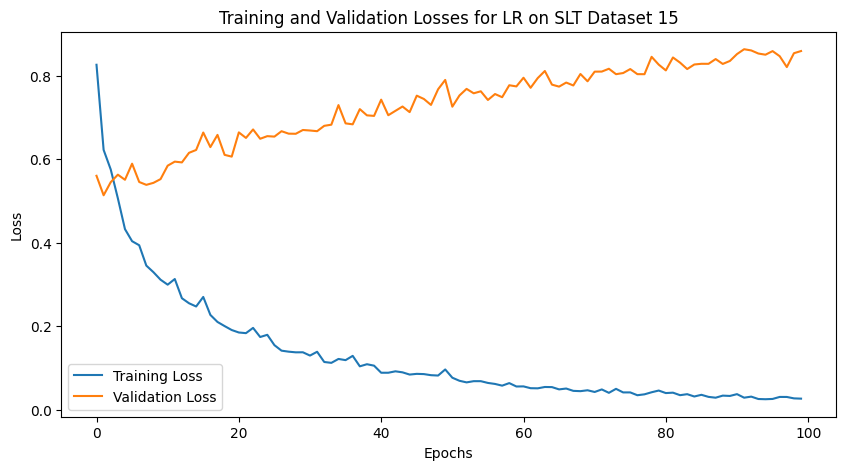

Test Loss: 5.1865
Training on SLT Dataset 16/32
Epoch 1/100, Training Loss: 0.8863, Validation Loss: 0.5407
Epoch 10/100, Training Loss: 0.2899, Validation Loss: 0.6047
Epoch 20/100, Training Loss: 0.1738, Validation Loss: 0.6528
Epoch 30/100, Training Loss: 0.1109, Validation Loss: 0.7309
Epoch 40/100, Training Loss: 0.0693, Validation Loss: 0.7728
Epoch 50/100, Training Loss: 0.0586, Validation Loss: 0.8115
Epoch 60/100, Training Loss: 0.0320, Validation Loss: 0.8513
Epoch 70/100, Training Loss: 0.0247, Validation Loss: 0.8876
Epoch 80/100, Training Loss: 0.0230, Validation Loss: 0.9433
Epoch 90/100, Training Loss: 0.0214, Validation Loss: 0.9308
Epoch 100/100, Training Loss: 0.0191, Validation Loss: 0.9798


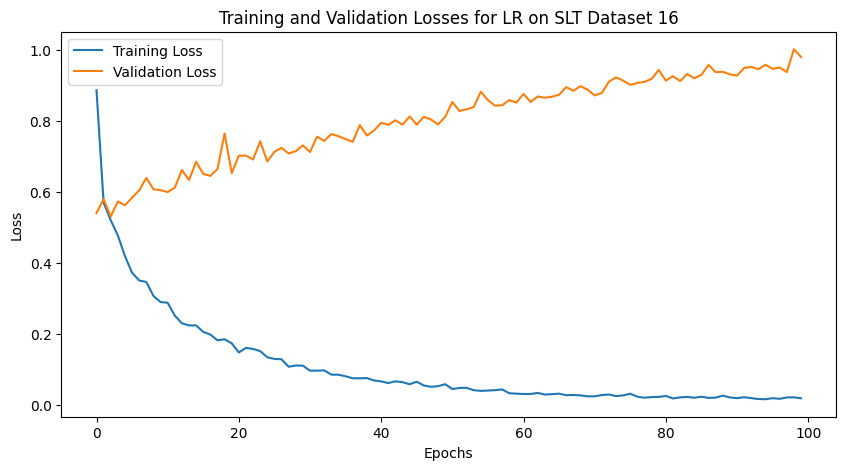

Test Loss: 5.7545
Training on SLT Dataset 17/32
Epoch 1/100, Training Loss: 0.8369, Validation Loss: 0.6654
Epoch 10/100, Training Loss: 0.2480, Validation Loss: 0.6950
Epoch 20/100, Training Loss: 0.1278, Validation Loss: 0.6743
Epoch 30/100, Training Loss: 0.0895, Validation Loss: 0.8093
Epoch 40/100, Training Loss: 0.0590, Validation Loss: 0.7969
Epoch 50/100, Training Loss: 0.0349, Validation Loss: 0.8168
Epoch 60/100, Training Loss: 0.0286, Validation Loss: 0.8509
Epoch 70/100, Training Loss: 0.0237, Validation Loss: 0.8700
Epoch 80/100, Training Loss: 0.0188, Validation Loss: 0.9210
Epoch 90/100, Training Loss: 0.0209, Validation Loss: 0.9113
Epoch 100/100, Training Loss: 0.0222, Validation Loss: 0.9750


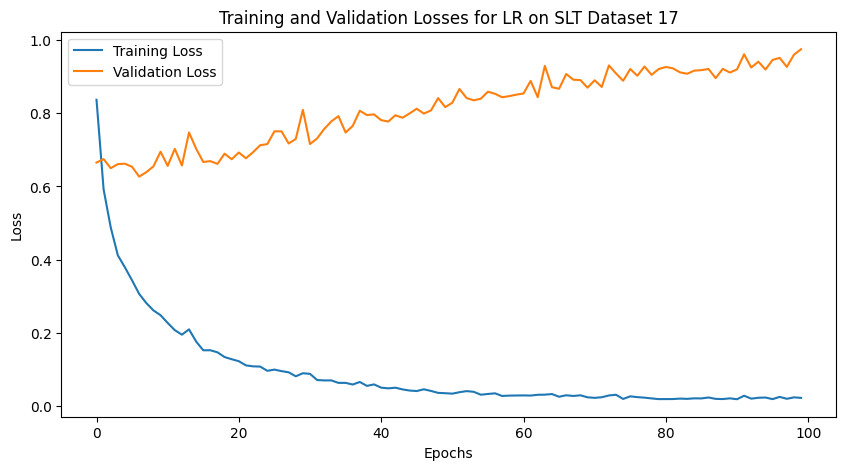

Test Loss: 3.5823
Training on SLT Dataset 18/32
Epoch 1/100, Training Loss: 0.8252, Validation Loss: 0.7893
Epoch 10/100, Training Loss: 0.2102, Validation Loss: 0.6520
Epoch 20/100, Training Loss: 0.1089, Validation Loss: 0.6953
Epoch 30/100, Training Loss: 0.0651, Validation Loss: 0.7482
Epoch 40/100, Training Loss: 0.0440, Validation Loss: 0.8173
Epoch 50/100, Training Loss: 0.0294, Validation Loss: 0.8434
Epoch 60/100, Training Loss: 0.0275, Validation Loss: 0.8617
Epoch 70/100, Training Loss: 0.0211, Validation Loss: 0.9045
Epoch 80/100, Training Loss: 0.0228, Validation Loss: 0.9172
Epoch 90/100, Training Loss: 0.0314, Validation Loss: 0.9549
Epoch 100/100, Training Loss: 0.0261, Validation Loss: 1.0350


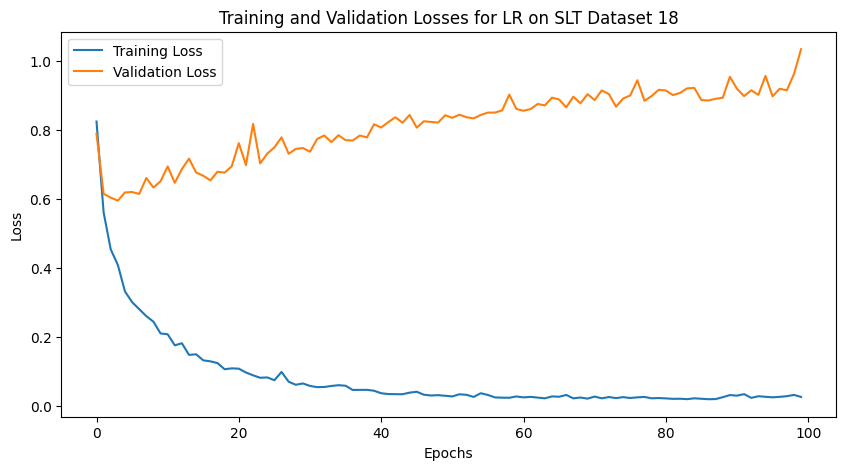

Test Loss: 3.3412
Training on SLT Dataset 19/32
Epoch 1/100, Training Loss: 0.8117, Validation Loss: 0.7408
Epoch 10/100, Training Loss: 0.1876, Validation Loss: 0.8447
Epoch 20/100, Training Loss: 0.1006, Validation Loss: 0.9114
Epoch 30/100, Training Loss: 0.0736, Validation Loss: 0.8841
Epoch 40/100, Training Loss: 0.0331, Validation Loss: 0.9215
Epoch 50/100, Training Loss: 0.0338, Validation Loss: 0.9603
Epoch 60/100, Training Loss: 0.0257, Validation Loss: 0.9802
Epoch 70/100, Training Loss: 0.0251, Validation Loss: 0.9584
Epoch 80/100, Training Loss: 0.0266, Validation Loss: 0.9558
Epoch 90/100, Training Loss: 0.0301, Validation Loss: 0.9548
Epoch 100/100, Training Loss: 0.0287, Validation Loss: 0.9691


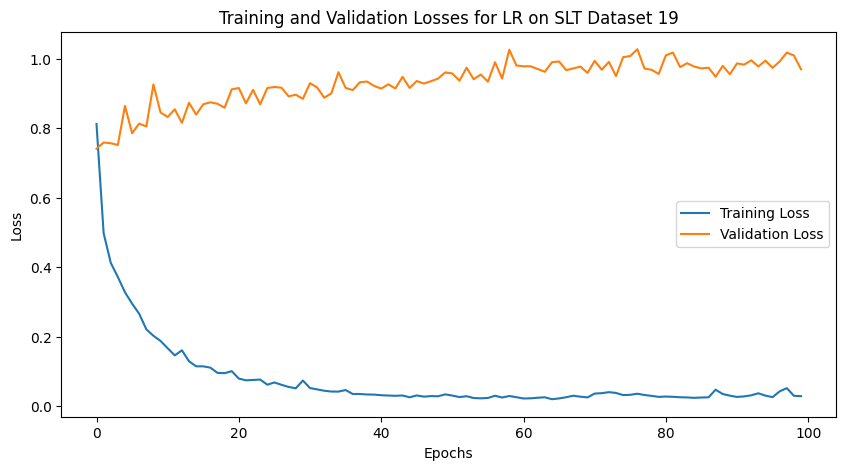

Test Loss: 2.3546
Training on SLT Dataset 20/32
Epoch 1/100, Training Loss: 0.8711, Validation Loss: 0.7575
Epoch 10/100, Training Loss: 0.1672, Validation Loss: 0.7850
Epoch 20/100, Training Loss: 0.0674, Validation Loss: 0.8400
Epoch 30/100, Training Loss: 0.0397, Validation Loss: 0.9328
Epoch 40/100, Training Loss: 0.0315, Validation Loss: 0.9972
Epoch 50/100, Training Loss: 0.0274, Validation Loss: 1.0428
Epoch 60/100, Training Loss: 0.0322, Validation Loss: 1.0764
Epoch 70/100, Training Loss: 0.0345, Validation Loss: 1.0580
Epoch 80/100, Training Loss: 0.0370, Validation Loss: 1.0670
Epoch 90/100, Training Loss: 0.0347, Validation Loss: 1.0557
Epoch 100/100, Training Loss: 0.0421, Validation Loss: 1.0843


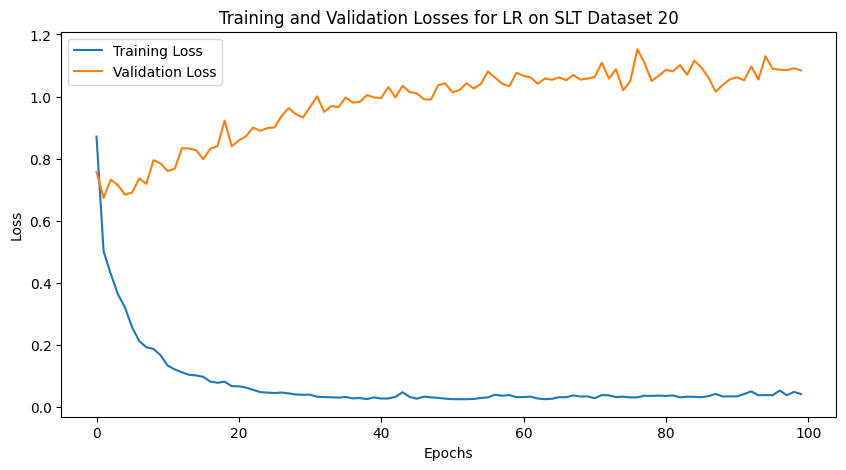

Test Loss: 4.0232
Training on SLT Dataset 21/32
Epoch 1/100, Training Loss: 0.9115, Validation Loss: 0.7190
Epoch 10/100, Training Loss: 0.1523, Validation Loss: 0.6150
Epoch 20/100, Training Loss: 0.0574, Validation Loss: 0.6794
Epoch 30/100, Training Loss: 0.0299, Validation Loss: 0.7484
Epoch 40/100, Training Loss: 0.0271, Validation Loss: 0.7754
Epoch 50/100, Training Loss: 0.0311, Validation Loss: 0.8095
Epoch 60/100, Training Loss: 0.0414, Validation Loss: 0.8103
Epoch 70/100, Training Loss: 0.0323, Validation Loss: 0.8557
Epoch 80/100, Training Loss: 0.0394, Validation Loss: 0.8301
Epoch 90/100, Training Loss: 0.0364, Validation Loss: 0.8509
Epoch 100/100, Training Loss: 0.0382, Validation Loss: 0.8268


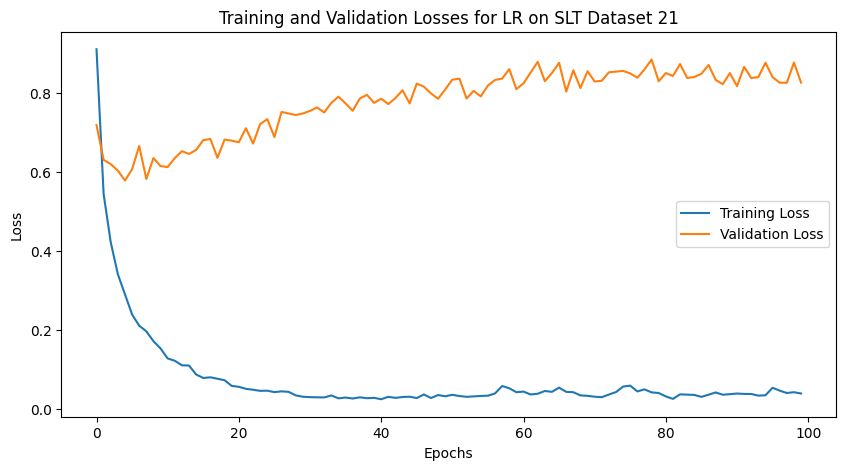

Test Loss: 2.0321
Training on SLT Dataset 22/32
Epoch 1/100, Training Loss: 0.8789, Validation Loss: 0.7944
Epoch 10/100, Training Loss: 0.1294, Validation Loss: 0.9335
Epoch 20/100, Training Loss: 0.0535, Validation Loss: 1.0968
Epoch 30/100, Training Loss: 0.0321, Validation Loss: 1.1222
Epoch 40/100, Training Loss: 0.0372, Validation Loss: 1.1657
Epoch 50/100, Training Loss: 0.0323, Validation Loss: 1.2168
Epoch 60/100, Training Loss: 0.0389, Validation Loss: 1.2383
Epoch 70/100, Training Loss: 0.0389, Validation Loss: 1.1744
Epoch 80/100, Training Loss: 0.0580, Validation Loss: 1.1858
Epoch 90/100, Training Loss: 0.0362, Validation Loss: 1.1874
Epoch 100/100, Training Loss: 0.0342, Validation Loss: 1.2094


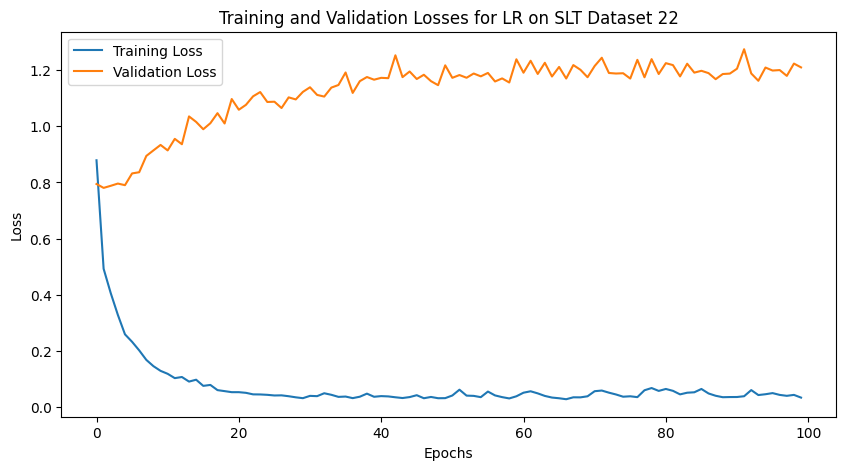

Test Loss: 1.8454
Training on SLT Dataset 23/32
Epoch 1/100, Training Loss: 0.9039, Validation Loss: 0.7726
Epoch 10/100, Training Loss: 0.1348, Validation Loss: 0.6881
Epoch 20/100, Training Loss: 0.0469, Validation Loss: 0.7997
Epoch 30/100, Training Loss: 0.0356, Validation Loss: 0.8644
Epoch 40/100, Training Loss: 0.0342, Validation Loss: 0.8948
Epoch 50/100, Training Loss: 0.0498, Validation Loss: 0.8849
Epoch 60/100, Training Loss: 0.0312, Validation Loss: 0.9470
Epoch 70/100, Training Loss: 0.0562, Validation Loss: 0.9206
Epoch 80/100, Training Loss: 0.0366, Validation Loss: 0.9065
Epoch 90/100, Training Loss: 0.0330, Validation Loss: 0.9452
Epoch 100/100, Training Loss: 0.0511, Validation Loss: 1.0264


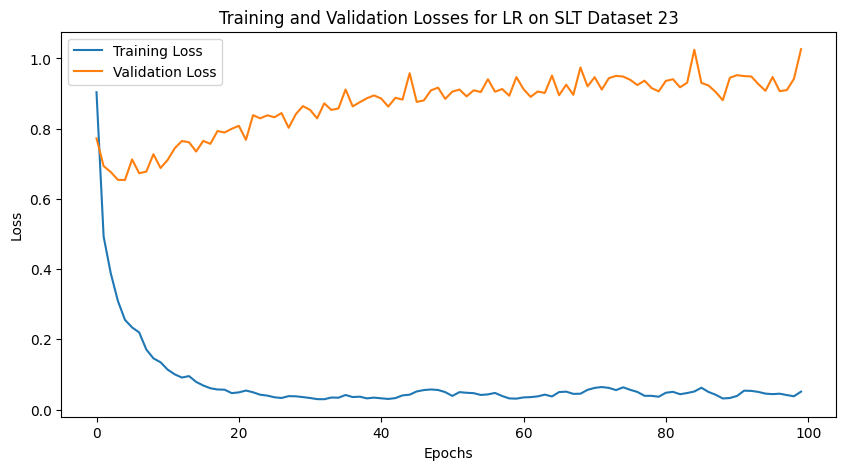

Test Loss: 1.7371
Training on SLT Dataset 24/32
Epoch 1/100, Training Loss: 1.0058, Validation Loss: 0.8356
Epoch 10/100, Training Loss: 0.1194, Validation Loss: 0.7854
Epoch 20/100, Training Loss: 0.0458, Validation Loss: 0.8061
Epoch 30/100, Training Loss: 0.0342, Validation Loss: 0.8596
Epoch 40/100, Training Loss: 0.0501, Validation Loss: 0.9701
Epoch 50/100, Training Loss: 0.0625, Validation Loss: 0.9019
Epoch 60/100, Training Loss: 0.0454, Validation Loss: 0.9018
Epoch 70/100, Training Loss: 0.0414, Validation Loss: 0.9427
Epoch 80/100, Training Loss: 0.0427, Validation Loss: 0.9147
Epoch 90/100, Training Loss: 0.0573, Validation Loss: 0.9523
Epoch 100/100, Training Loss: 0.0728, Validation Loss: 0.9305


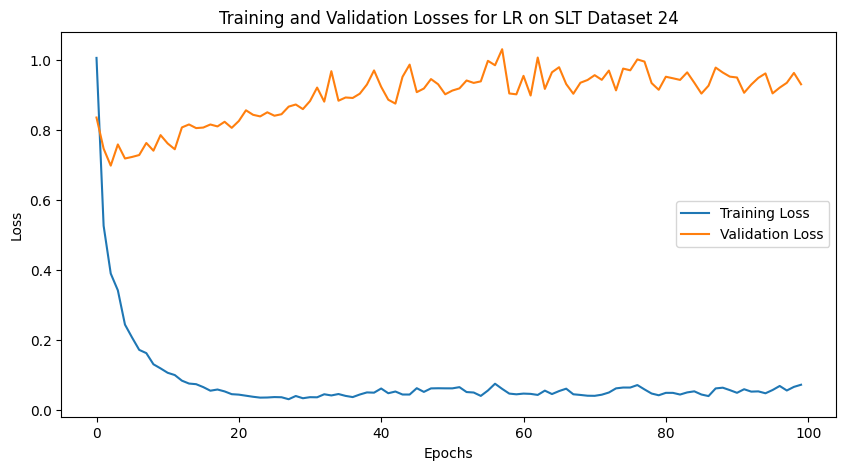

Test Loss: 2.5687
Training on SLT Dataset 25/32
Epoch 1/100, Training Loss: 1.2202, Validation Loss: 0.8878
Epoch 10/100, Training Loss: 0.1493, Validation Loss: 0.7822
Epoch 20/100, Training Loss: 0.0495, Validation Loss: 0.8261
Epoch 30/100, Training Loss: 0.0368, Validation Loss: 0.8883
Epoch 40/100, Training Loss: 0.0420, Validation Loss: 0.9891
Epoch 50/100, Training Loss: 0.0843, Validation Loss: 1.0091
Epoch 60/100, Training Loss: 0.0593, Validation Loss: 0.9589
Epoch 70/100, Training Loss: 0.0574, Validation Loss: 0.9700
Epoch 80/100, Training Loss: 0.0705, Validation Loss: 0.9930
Epoch 90/100, Training Loss: 0.0471, Validation Loss: 0.9388
Epoch 100/100, Training Loss: 0.0519, Validation Loss: 0.9685


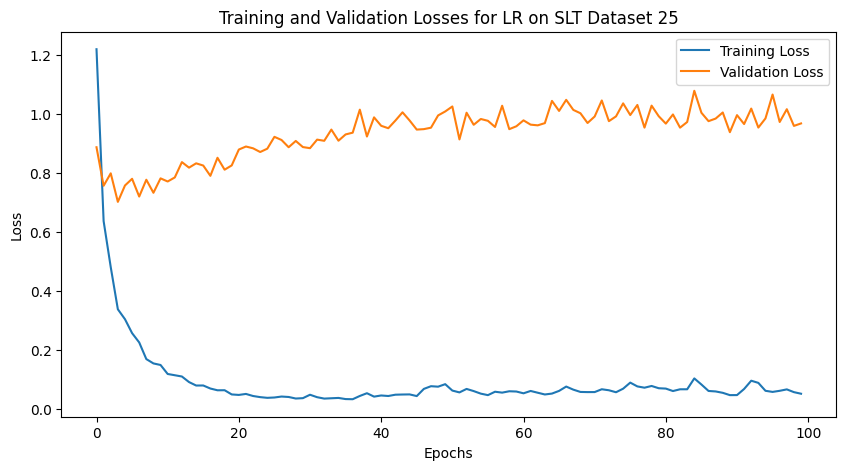

Test Loss: 1.7606
Training on SLT Dataset 26/32
Epoch 1/100, Training Loss: 1.1353, Validation Loss: 0.8349
Epoch 10/100, Training Loss: 0.0978, Validation Loss: 0.8943
Epoch 20/100, Training Loss: 0.0601, Validation Loss: 0.8375
Epoch 30/100, Training Loss: 0.0494, Validation Loss: 0.9015
Epoch 40/100, Training Loss: 0.0986, Validation Loss: 0.9562
Epoch 50/100, Training Loss: 0.0820, Validation Loss: 0.9623
Epoch 60/100, Training Loss: 0.1278, Validation Loss: 0.9502
Epoch 70/100, Training Loss: 0.1165, Validation Loss: 0.9420
Epoch 80/100, Training Loss: 0.0717, Validation Loss: 1.0227
Epoch 90/100, Training Loss: 0.0755, Validation Loss: 0.9379
Epoch 100/100, Training Loss: 0.0841, Validation Loss: 0.9460


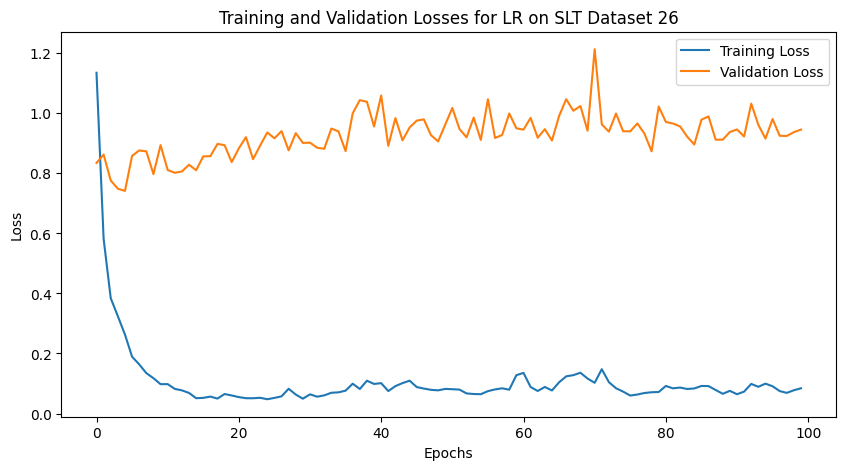

Test Loss: 1.2812
Training on SLT Dataset 27/32
Epoch 1/100, Training Loss: 1.3742, Validation Loss: 1.0299
Epoch 10/100, Training Loss: 0.0908, Validation Loss: 0.8451
Epoch 20/100, Training Loss: 0.0497, Validation Loss: 0.9358
Epoch 30/100, Training Loss: 0.0716, Validation Loss: 1.0012
Epoch 40/100, Training Loss: 0.1089, Validation Loss: 1.1424
Epoch 50/100, Training Loss: 0.1102, Validation Loss: 1.0525
Epoch 60/100, Training Loss: 0.1083, Validation Loss: 1.0838
Epoch 70/100, Training Loss: 0.1558, Validation Loss: 1.1306
Epoch 80/100, Training Loss: 0.1266, Validation Loss: 1.0598
Epoch 90/100, Training Loss: 0.0943, Validation Loss: 1.0395
Epoch 100/100, Training Loss: 0.1071, Validation Loss: 1.0632


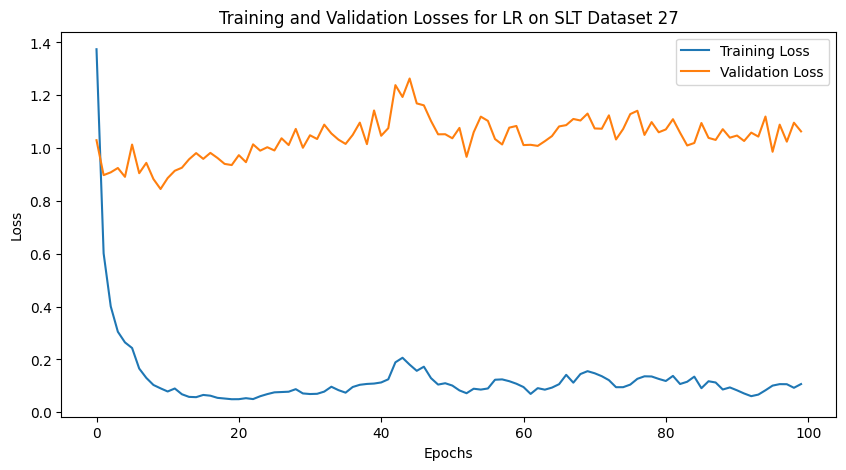

Test Loss: 1.2361
Training on SLT Dataset 28/32
Epoch 1/100, Training Loss: 1.6070, Validation Loss: 1.1102
Epoch 10/100, Training Loss: 0.1155, Validation Loss: 0.9365
Epoch 20/100, Training Loss: 0.0860, Validation Loss: 1.0204
Epoch 30/100, Training Loss: 0.1965, Validation Loss: 1.2064
Epoch 40/100, Training Loss: 0.1385, Validation Loss: 1.1838
Epoch 50/100, Training Loss: 0.1396, Validation Loss: 1.0205
Epoch 60/100, Training Loss: 0.1483, Validation Loss: 1.1310
Epoch 70/100, Training Loss: 0.0977, Validation Loss: 1.1755
Epoch 80/100, Training Loss: 0.1608, Validation Loss: 1.1577
Epoch 90/100, Training Loss: 0.1296, Validation Loss: 1.2692
Epoch 100/100, Training Loss: 0.1279, Validation Loss: 1.1295


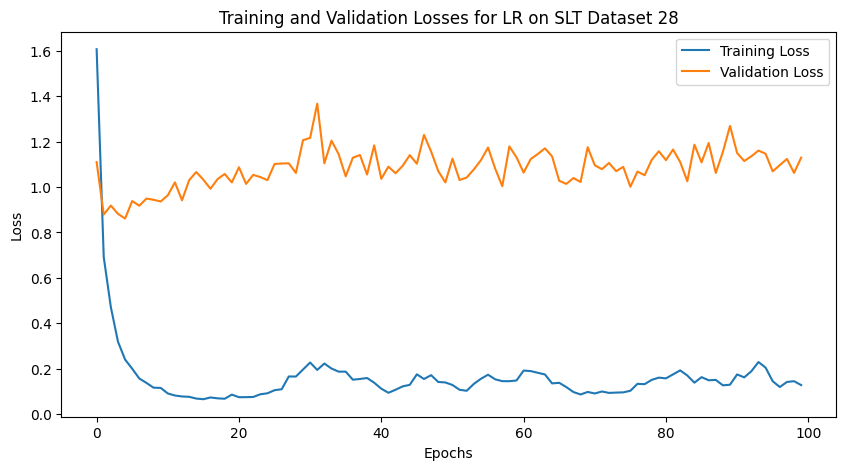

Test Loss: 1.2260
Training on SLT Dataset 29/32
Epoch 1/100, Training Loss: 1.6869, Validation Loss: 1.2016
Epoch 10/100, Training Loss: 0.0750, Validation Loss: 1.1104
Epoch 20/100, Training Loss: 0.0979, Validation Loss: 1.1433
Epoch 30/100, Training Loss: 0.1806, Validation Loss: 1.2357
Epoch 40/100, Training Loss: 0.1290, Validation Loss: 1.2372
Epoch 50/100, Training Loss: 0.1372, Validation Loss: 1.2700
Epoch 60/100, Training Loss: 0.1649, Validation Loss: 1.2936
Epoch 70/100, Training Loss: 0.1270, Validation Loss: 1.2457
Epoch 80/100, Training Loss: 0.2113, Validation Loss: 1.2290
Epoch 90/100, Training Loss: 0.1158, Validation Loss: 1.2004
Epoch 100/100, Training Loss: 0.1496, Validation Loss: 1.2764


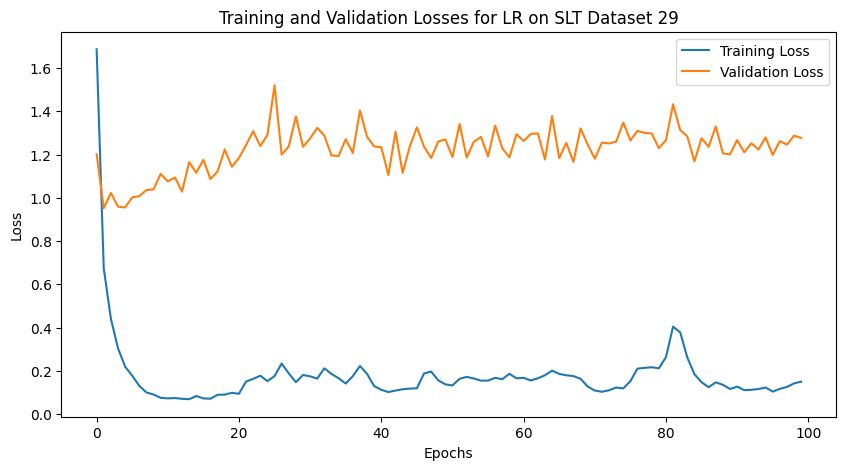

Test Loss: 0.9596
Training on SLT Dataset 30/32
Epoch 1/100, Training Loss: 1.5809, Validation Loss: 1.3003
Epoch 10/100, Training Loss: 0.0670, Validation Loss: 1.1050
Epoch 20/100, Training Loss: 0.1183, Validation Loss: 1.0891
Epoch 30/100, Training Loss: 0.1305, Validation Loss: 1.1877
Epoch 40/100, Training Loss: 0.1547, Validation Loss: 1.3342
Epoch 50/100, Training Loss: 0.2126, Validation Loss: 1.1859
Epoch 60/100, Training Loss: 0.1635, Validation Loss: 1.2675
Epoch 70/100, Training Loss: 0.1068, Validation Loss: 1.2186
Epoch 80/100, Training Loss: 0.2108, Validation Loss: 1.2914
Epoch 90/100, Training Loss: 0.1426, Validation Loss: 1.2884
Epoch 100/100, Training Loss: 0.1166, Validation Loss: 1.1527


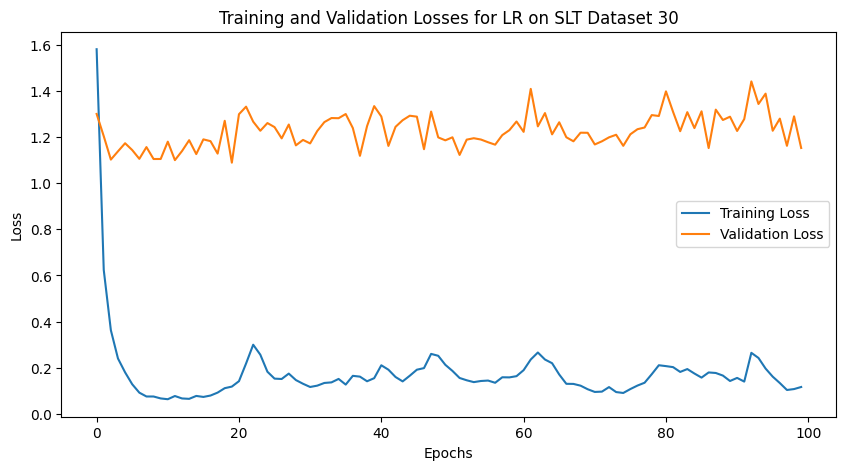

Test Loss: 1.0061
Training on SLT Dataset 31/32
Epoch 1/100, Training Loss: 1.9110, Validation Loss: 1.3320
Epoch 10/100, Training Loss: 0.0507, Validation Loss: 1.3095
Epoch 20/100, Training Loss: 0.0797, Validation Loss: 1.4193
Epoch 30/100, Training Loss: 0.2349, Validation Loss: 1.4416
Epoch 40/100, Training Loss: 0.1813, Validation Loss: 1.5906
Epoch 50/100, Training Loss: 0.1298, Validation Loss: 1.4445
Epoch 60/100, Training Loss: 0.1480, Validation Loss: 1.3721
Epoch 70/100, Training Loss: 0.0941, Validation Loss: 1.4258
Epoch 80/100, Training Loss: 0.1305, Validation Loss: 1.4104
Epoch 90/100, Training Loss: 0.1397, Validation Loss: 1.4435
Epoch 100/100, Training Loss: 0.1603, Validation Loss: 1.4767


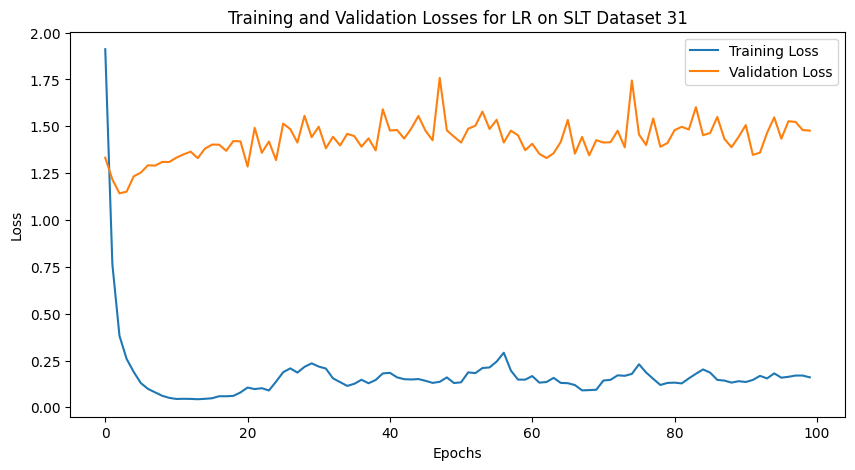

Test Loss: 1.1375
Training on SLT Dataset 32/32
Epoch 1/100, Training Loss: 0.8852, Validation Loss: 0.6658
Epoch 10/100, Training Loss: 0.0833, Validation Loss: 0.6963
Epoch 20/100, Training Loss: 0.0392, Validation Loss: 0.7066
Epoch 30/100, Training Loss: 0.0246, Validation Loss: 0.7291
Epoch 40/100, Training Loss: 0.0300, Validation Loss: 0.7334
Epoch 50/100, Training Loss: 0.0320, Validation Loss: 0.7410
Epoch 60/100, Training Loss: 0.0336, Validation Loss: 0.7197
Epoch 70/100, Training Loss: 0.0311, Validation Loss: 0.7297
Epoch 80/100, Training Loss: 0.0330, Validation Loss: 0.7591
Epoch 90/100, Training Loss: 0.0295, Validation Loss: 0.7328
Epoch 100/100, Training Loss: 0.0435, Validation Loss: 0.7402


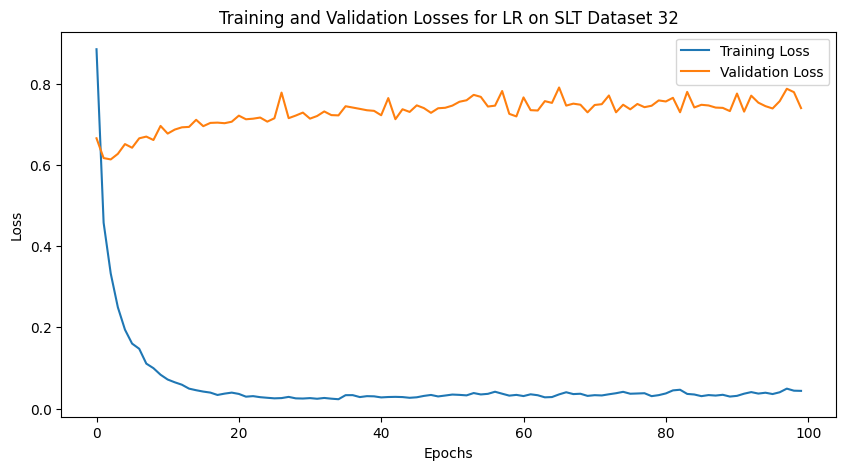

Test Loss: 1.9635


In [119]:
# Training Loops: single LR.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
slr_test_losses = []

for i, (train_loader, valid_loader) in enumerate(zip(slt_train_dataloaders, slt_valid_dataloaders)):
    print(f"Training on SLT Dataset {i+1}/{len(slt_train_dataloaders)}")
    model = LinearModel(in_dim, out_dim)
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, epochs=epochs, title=f"LR on SLT Dataset {i+1}")
    test_loss = evaluate_on_test(model, slt_pooled_test_dataloader, device)
    slr_test_losses.append(test_loss)

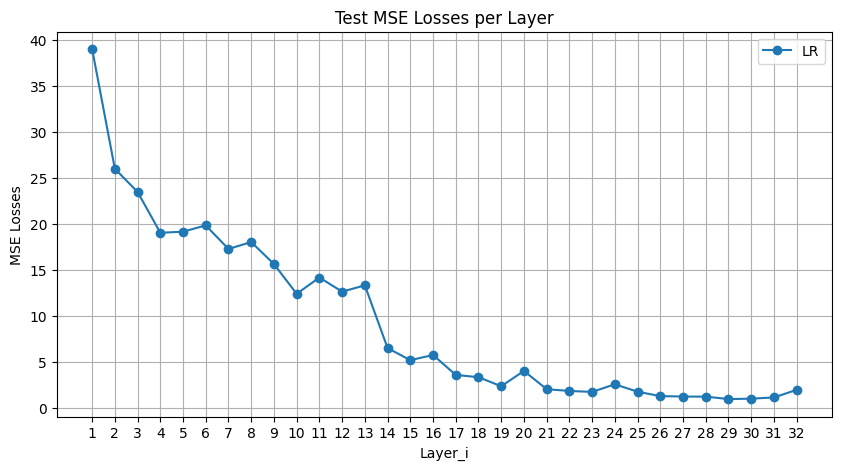

In [120]:
plot_1d_metrics([slr_test_losses], ['LR'], 'MSE Losses')

Training on SLT Dataset 1/32
Epoch 1/100, Training Loss: 1.2029, Validation Loss: 0.9986
Epoch 10/100, Training Loss: 0.6405, Validation Loss: 1.0868
Epoch 20/100, Training Loss: 0.4423, Validation Loss: 1.4661
Epoch 30/100, Training Loss: 0.3223, Validation Loss: 1.7570
Epoch 40/100, Training Loss: 0.2830, Validation Loss: 1.0390
Epoch 50/100, Training Loss: 0.2123, Validation Loss: 1.2524
Epoch 60/100, Training Loss: 0.1992, Validation Loss: 1.0167
Epoch 70/100, Training Loss: 0.1920, Validation Loss: 1.0429
Epoch 80/100, Training Loss: 0.1816, Validation Loss: 1.0262
Epoch 90/100, Training Loss: 0.1551, Validation Loss: 1.0455
Epoch 100/100, Training Loss: 0.1611, Validation Loss: 1.0391


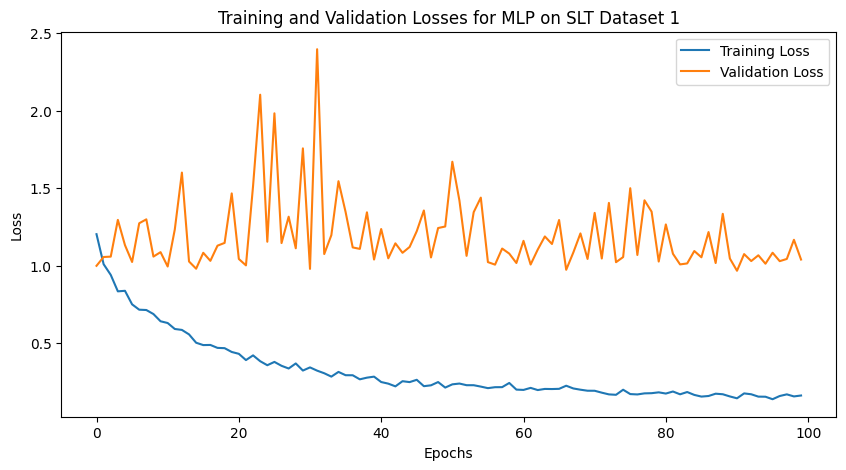

Test Loss: 59.2729
Training on SLT Dataset 2/32
Epoch 1/100, Training Loss: 0.5246, Validation Loss: 0.7007
Epoch 10/100, Training Loss: 0.2541, Validation Loss: 0.5965
Epoch 20/100, Training Loss: 0.2229, Validation Loss: 0.4487
Epoch 30/100, Training Loss: 0.1793, Validation Loss: 0.5591
Epoch 40/100, Training Loss: 0.1554, Validation Loss: 1.0345
Epoch 50/100, Training Loss: 0.1382, Validation Loss: 0.5401
Epoch 60/100, Training Loss: 0.1352, Validation Loss: 0.6457
Epoch 70/100, Training Loss: 0.1287, Validation Loss: 0.5712
Epoch 80/100, Training Loss: 0.1205, Validation Loss: 0.5827
Epoch 90/100, Training Loss: 0.1222, Validation Loss: 0.6035
Epoch 100/100, Training Loss: 0.1290, Validation Loss: 0.5550


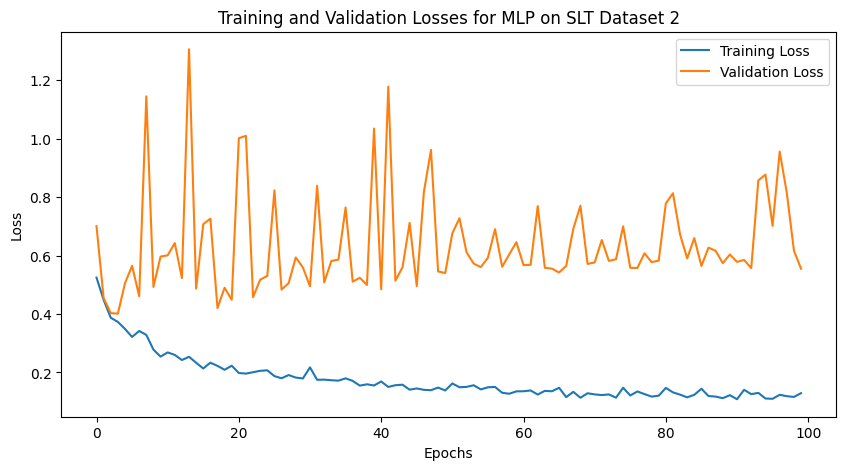

Test Loss: 63.2028
Training on SLT Dataset 3/32
Epoch 1/100, Training Loss: 0.4054, Validation Loss: 0.2779
Epoch 10/100, Training Loss: 0.2300, Validation Loss: 0.2781
Epoch 20/100, Training Loss: 0.1487, Validation Loss: 0.3505
Epoch 30/100, Training Loss: 0.1221, Validation Loss: 0.3444
Epoch 40/100, Training Loss: 0.1074, Validation Loss: 0.3399
Epoch 50/100, Training Loss: 0.1105, Validation Loss: 0.5096
Epoch 60/100, Training Loss: 0.0998, Validation Loss: 0.3720
Epoch 70/100, Training Loss: 0.0902, Validation Loss: 0.4146
Epoch 80/100, Training Loss: 0.0991, Validation Loss: 0.4045
Epoch 90/100, Training Loss: 0.1135, Validation Loss: 0.4196
Epoch 100/100, Training Loss: 0.0999, Validation Loss: 0.4697


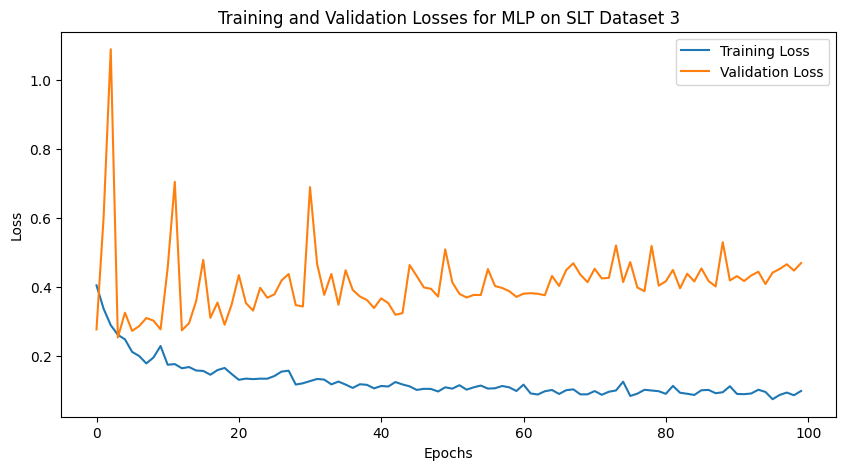

Test Loss: 19.5084
Training on SLT Dataset 4/32
Epoch 1/100, Training Loss: 0.3951, Validation Loss: 0.4018
Epoch 10/100, Training Loss: 0.1388, Validation Loss: 0.3135
Epoch 20/100, Training Loss: 0.1088, Validation Loss: 0.3011
Epoch 30/100, Training Loss: 0.1030, Validation Loss: 0.3535
Epoch 40/100, Training Loss: 0.1207, Validation Loss: 0.3407
Epoch 50/100, Training Loss: 0.1047, Validation Loss: 0.3486
Epoch 60/100, Training Loss: 0.0908, Validation Loss: 0.3511
Epoch 70/100, Training Loss: 0.0904, Validation Loss: 0.4084
Epoch 80/100, Training Loss: 0.0879, Validation Loss: 0.3688
Epoch 90/100, Training Loss: 0.0764, Validation Loss: 0.3746
Epoch 100/100, Training Loss: 0.0840, Validation Loss: 0.4100


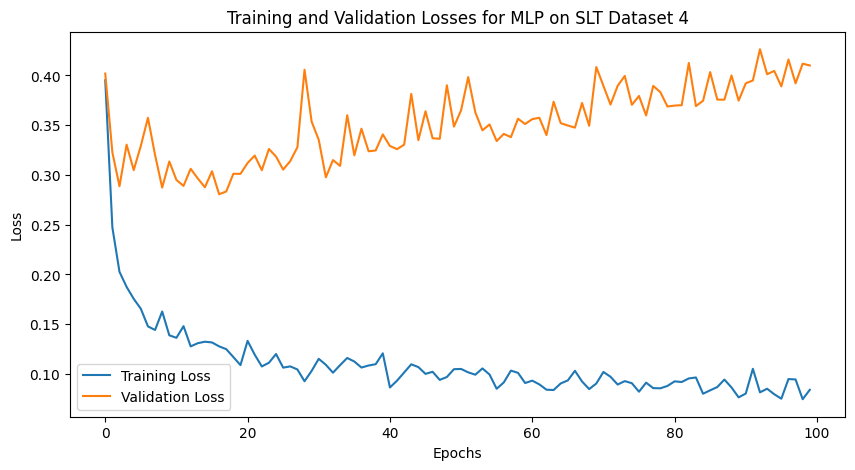

Test Loss: 6.2855
Training on SLT Dataset 5/32
Epoch 1/100, Training Loss: 0.3005, Validation Loss: 0.2164
Epoch 10/100, Training Loss: 0.1123, Validation Loss: 0.1976
Epoch 20/100, Training Loss: 0.1039, Validation Loss: 0.2140
Epoch 30/100, Training Loss: 0.0891, Validation Loss: 0.2651
Epoch 40/100, Training Loss: 0.0931, Validation Loss: 0.2672
Epoch 50/100, Training Loss: 0.0842, Validation Loss: 0.2814
Epoch 60/100, Training Loss: 0.0858, Validation Loss: 0.2960
Epoch 70/100, Training Loss: 0.0875, Validation Loss: 0.2831
Epoch 80/100, Training Loss: 0.0782, Validation Loss: 0.2918
Epoch 90/100, Training Loss: 0.0722, Validation Loss: 0.3123
Epoch 100/100, Training Loss: 0.0773, Validation Loss: 0.3781


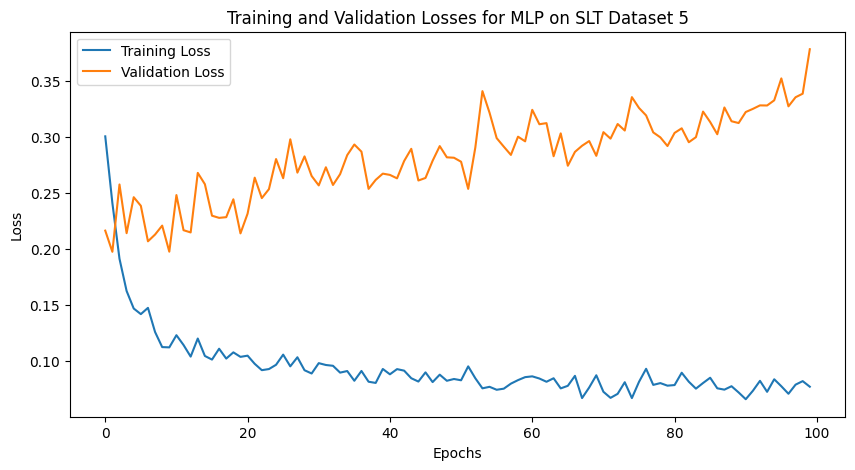

Test Loss: 2.9464
Training on SLT Dataset 6/32
Epoch 1/100, Training Loss: 0.2722, Validation Loss: 0.2307
Epoch 10/100, Training Loss: 0.1076, Validation Loss: 0.2052
Epoch 20/100, Training Loss: 0.0899, Validation Loss: 0.2296
Epoch 30/100, Training Loss: 0.0770, Validation Loss: 0.2348
Epoch 40/100, Training Loss: 0.0731, Validation Loss: 0.2401
Epoch 50/100, Training Loss: 0.0833, Validation Loss: 0.2707
Epoch 60/100, Training Loss: 0.0741, Validation Loss: 0.2963
Epoch 70/100, Training Loss: 0.0743, Validation Loss: 0.2866
Epoch 80/100, Training Loss: 0.0683, Validation Loss: 0.3553
Epoch 90/100, Training Loss: 0.0725, Validation Loss: 0.3381
Epoch 100/100, Training Loss: 0.0692, Validation Loss: 0.3518


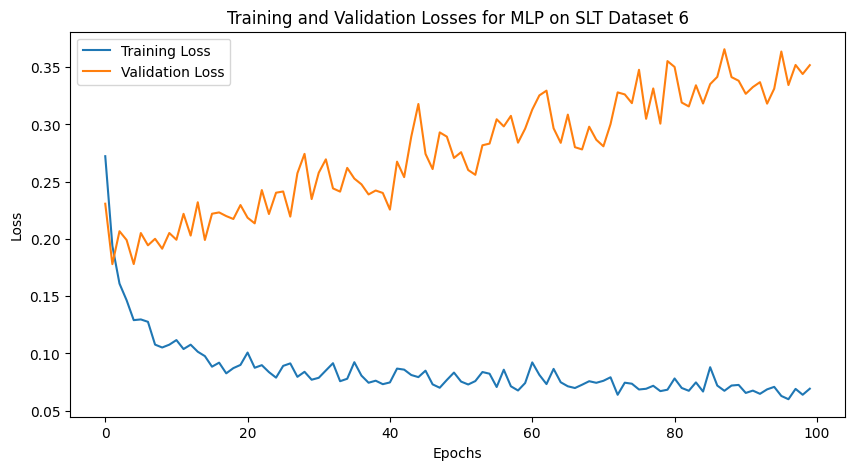

Test Loss: 2.8607
Training on SLT Dataset 7/32
Epoch 1/100, Training Loss: 0.3636, Validation Loss: 0.1977
Epoch 10/100, Training Loss: 0.1104, Validation Loss: 0.1810
Epoch 20/100, Training Loss: 0.0934, Validation Loss: 0.1975
Epoch 30/100, Training Loss: 0.0794, Validation Loss: 0.2065
Epoch 40/100, Training Loss: 0.0733, Validation Loss: 0.2234
Epoch 50/100, Training Loss: 0.0845, Validation Loss: 0.2304
Epoch 60/100, Training Loss: 0.0713, Validation Loss: 0.2734
Epoch 70/100, Training Loss: 0.0689, Validation Loss: 0.2637
Epoch 80/100, Training Loss: 0.0700, Validation Loss: 0.2590
Epoch 90/100, Training Loss: 0.0730, Validation Loss: 0.2798
Epoch 100/100, Training Loss: 0.0766, Validation Loss: 0.2990


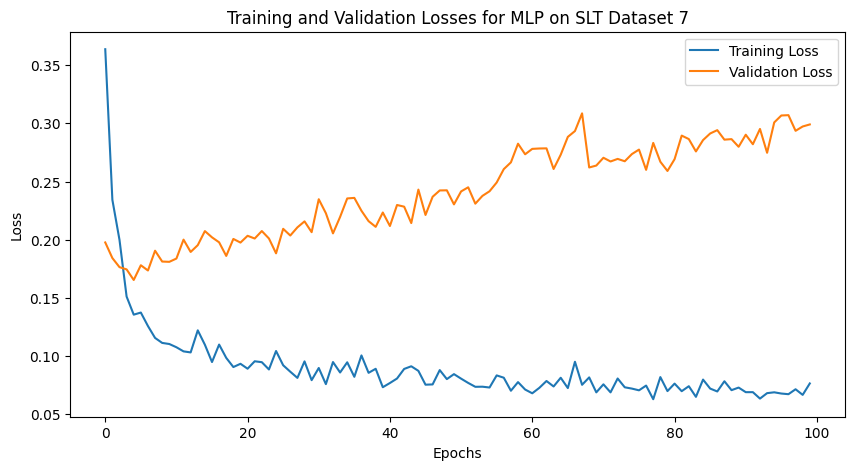

Test Loss: 2.0778
Training on SLT Dataset 8/32
Epoch 1/100, Training Loss: 0.2710, Validation Loss: 0.2418
Epoch 10/100, Training Loss: 0.1013, Validation Loss: 0.2327
Epoch 20/100, Training Loss: 0.0826, Validation Loss: 0.2635
Epoch 30/100, Training Loss: 0.0823, Validation Loss: 0.2772
Epoch 40/100, Training Loss: 0.0691, Validation Loss: 0.3294
Epoch 50/100, Training Loss: 0.0715, Validation Loss: 0.3187
Epoch 60/100, Training Loss: 0.0719, Validation Loss: 0.3348
Epoch 70/100, Training Loss: 0.0662, Validation Loss: 0.3325
Epoch 80/100, Training Loss: 0.0622, Validation Loss: 0.3569
Epoch 90/100, Training Loss: 0.0619, Validation Loss: 0.3781
Epoch 100/100, Training Loss: 0.0635, Validation Loss: 0.4071


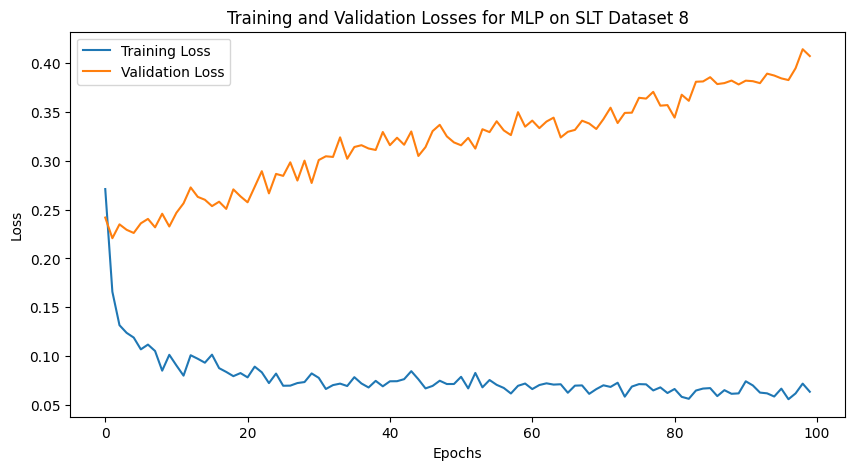

Test Loss: 1.4819
Training on SLT Dataset 9/32
Epoch 1/100, Training Loss: 0.2663, Validation Loss: 0.1618
Epoch 10/100, Training Loss: 0.0909, Validation Loss: 0.1859
Epoch 20/100, Training Loss: 0.0897, Validation Loss: 0.1997
Epoch 30/100, Training Loss: 0.0765, Validation Loss: 0.2245
Epoch 40/100, Training Loss: 0.0718, Validation Loss: 0.2240
Epoch 50/100, Training Loss: 0.0668, Validation Loss: 0.2317
Epoch 60/100, Training Loss: 0.0670, Validation Loss: 0.2590
Epoch 70/100, Training Loss: 0.0681, Validation Loss: 0.2774
Epoch 80/100, Training Loss: 0.0675, Validation Loss: 0.2947
Epoch 90/100, Training Loss: 0.0694, Validation Loss: 0.2781
Epoch 100/100, Training Loss: 0.0621, Validation Loss: 0.2957


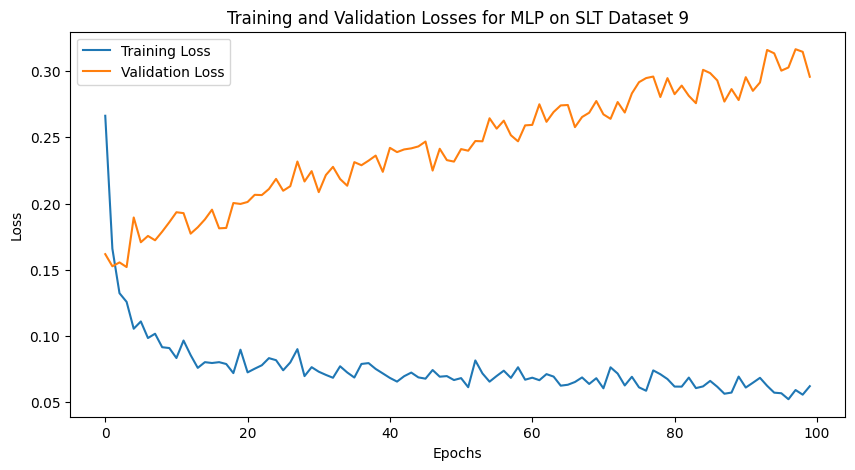

Test Loss: 1.2539
Training on SLT Dataset 10/32
Epoch 1/100, Training Loss: 0.2195, Validation Loss: 0.1992
Epoch 10/100, Training Loss: 0.0902, Validation Loss: 0.1760
Epoch 20/100, Training Loss: 0.0769, Validation Loss: 0.1867
Epoch 30/100, Training Loss: 0.0636, Validation Loss: 0.2038
Epoch 40/100, Training Loss: 0.0646, Validation Loss: 0.1955
Epoch 50/100, Training Loss: 0.0578, Validation Loss: 0.2038
Epoch 60/100, Training Loss: 0.0631, Validation Loss: 0.2097
Epoch 70/100, Training Loss: 0.0699, Validation Loss: 0.2246
Epoch 80/100, Training Loss: 0.0560, Validation Loss: 0.2191
Epoch 90/100, Training Loss: 0.0640, Validation Loss: 0.2437
Epoch 100/100, Training Loss: 0.0561, Validation Loss: 0.2334


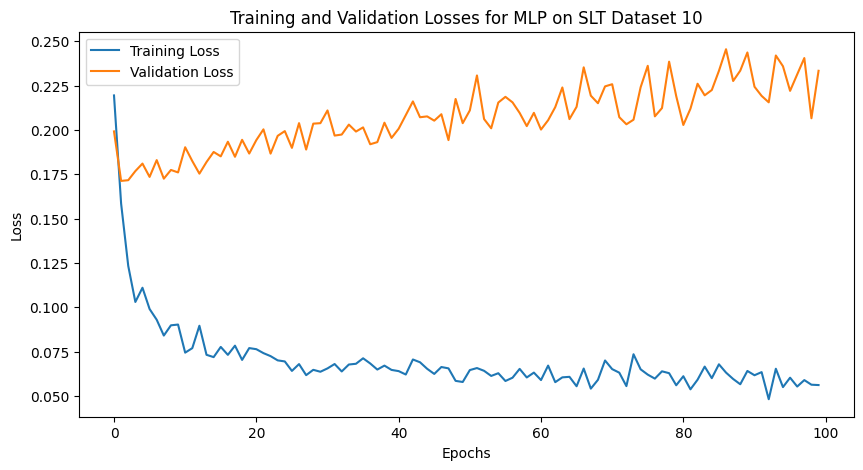

Test Loss: 1.0644
Training on SLT Dataset 11/32
Epoch 1/100, Training Loss: 0.2546, Validation Loss: 0.1810
Epoch 10/100, Training Loss: 0.0769, Validation Loss: 0.1600
Epoch 20/100, Training Loss: 0.0678, Validation Loss: 0.1889
Epoch 30/100, Training Loss: 0.0642, Validation Loss: 0.1908
Epoch 40/100, Training Loss: 0.0705, Validation Loss: 0.2144
Epoch 50/100, Training Loss: 0.0693, Validation Loss: 0.2140
Epoch 60/100, Training Loss: 0.0616, Validation Loss: 0.2255
Epoch 70/100, Training Loss: 0.0585, Validation Loss: 0.2253
Epoch 80/100, Training Loss: 0.0597, Validation Loss: 0.2389
Epoch 90/100, Training Loss: 0.0485, Validation Loss: 0.2590
Epoch 100/100, Training Loss: 0.0559, Validation Loss: 0.2604


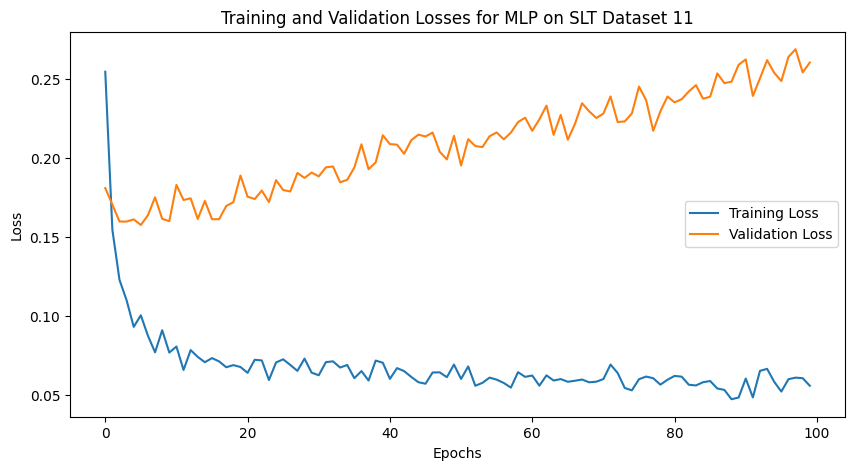

Test Loss: 1.0333
Training on SLT Dataset 12/32
Epoch 1/100, Training Loss: 0.2341, Validation Loss: 0.1613
Epoch 10/100, Training Loss: 0.0741, Validation Loss: 0.1541
Epoch 20/100, Training Loss: 0.0615, Validation Loss: 0.1650
Epoch 30/100, Training Loss: 0.0578, Validation Loss: 0.1821
Epoch 40/100, Training Loss: 0.0671, Validation Loss: 0.1911
Epoch 50/100, Training Loss: 0.0621, Validation Loss: 0.1936
Epoch 60/100, Training Loss: 0.0549, Validation Loss: 0.1977
Epoch 70/100, Training Loss: 0.0661, Validation Loss: 0.2064
Epoch 80/100, Training Loss: 0.0548, Validation Loss: 0.2294
Epoch 90/100, Training Loss: 0.0554, Validation Loss: 0.2298
Epoch 100/100, Training Loss: 0.0530, Validation Loss: 0.2313


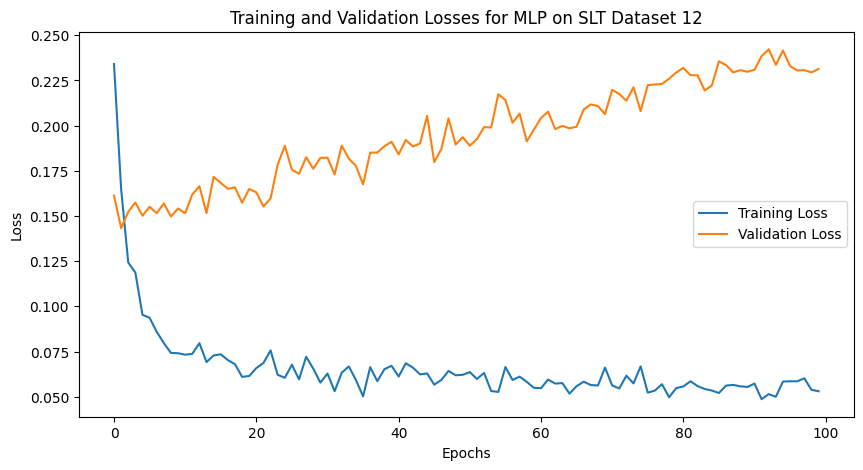

Test Loss: 0.9070
Training on SLT Dataset 13/32
Epoch 1/100, Training Loss: 0.2282, Validation Loss: 0.1614
Epoch 10/100, Training Loss: 0.0730, Validation Loss: 0.1693
Epoch 20/100, Training Loss: 0.0625, Validation Loss: 0.1544
Epoch 30/100, Training Loss: 0.0635, Validation Loss: 0.1813
Epoch 40/100, Training Loss: 0.0542, Validation Loss: 0.1700
Epoch 50/100, Training Loss: 0.0552, Validation Loss: 0.1756
Epoch 60/100, Training Loss: 0.0523, Validation Loss: 0.1847
Epoch 70/100, Training Loss: 0.0566, Validation Loss: 0.2024
Epoch 80/100, Training Loss: 0.0537, Validation Loss: 0.2005
Epoch 90/100, Training Loss: 0.0486, Validation Loss: 0.2129
Epoch 100/100, Training Loss: 0.0486, Validation Loss: 0.2338


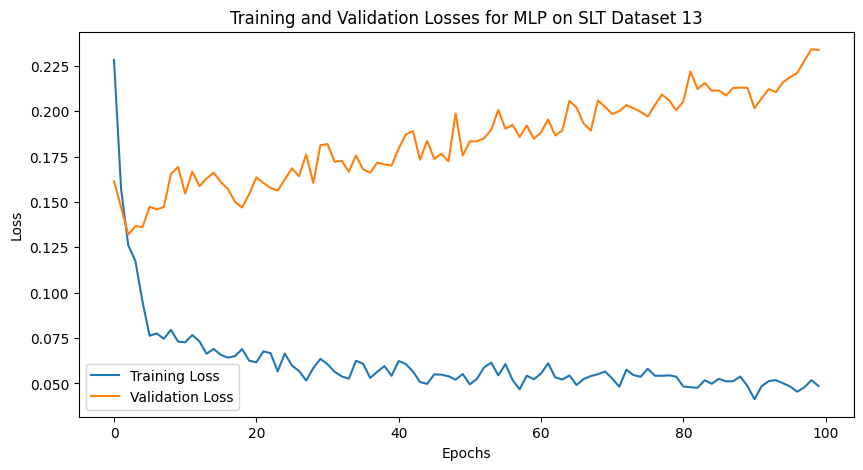

Test Loss: 0.8173
Training on SLT Dataset 14/32
Epoch 1/100, Training Loss: 0.2344, Validation Loss: 0.1622
Epoch 10/100, Training Loss: 0.0709, Validation Loss: 0.1945
Epoch 20/100, Training Loss: 0.0571, Validation Loss: 0.1897
Epoch 30/100, Training Loss: 0.0563, Validation Loss: 0.1869
Epoch 40/100, Training Loss: 0.0480, Validation Loss: 0.2328
Epoch 50/100, Training Loss: 0.0489, Validation Loss: 0.2278
Epoch 60/100, Training Loss: 0.0515, Validation Loss: 0.2373
Epoch 70/100, Training Loss: 0.0474, Validation Loss: 0.2728
Epoch 80/100, Training Loss: 0.0470, Validation Loss: 0.2634
Epoch 90/100, Training Loss: 0.0489, Validation Loss: 0.2612
Epoch 100/100, Training Loss: 0.0482, Validation Loss: 0.2604


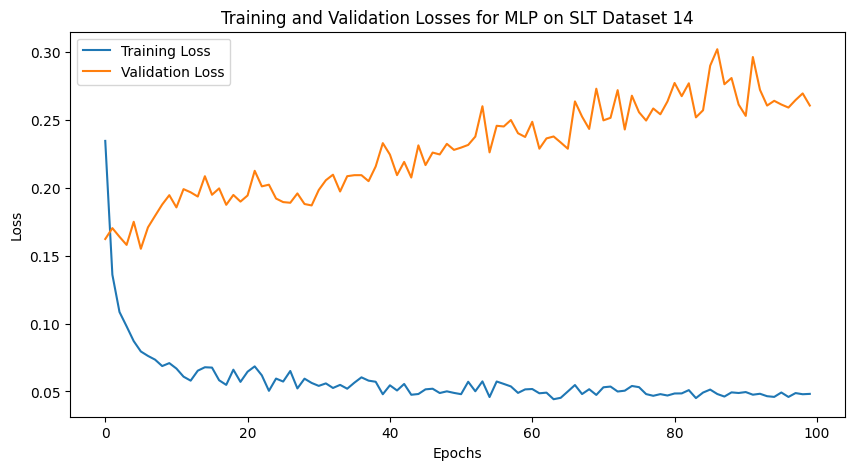

Test Loss: 0.7114
Training on SLT Dataset 15/32
Epoch 1/100, Training Loss: 0.1672, Validation Loss: 0.0852
Epoch 10/100, Training Loss: 0.0658, Validation Loss: 0.1007
Epoch 20/100, Training Loss: 0.0563, Validation Loss: 0.1195
Epoch 30/100, Training Loss: 0.0509, Validation Loss: 0.1297
Epoch 40/100, Training Loss: 0.0515, Validation Loss: 0.1188
Epoch 50/100, Training Loss: 0.0499, Validation Loss: 0.1293
Epoch 60/100, Training Loss: 0.0559, Validation Loss: 0.1272
Epoch 70/100, Training Loss: 0.0450, Validation Loss: 0.1352
Epoch 80/100, Training Loss: 0.0418, Validation Loss: 0.1308
Epoch 90/100, Training Loss: 0.0496, Validation Loss: 0.1465
Epoch 100/100, Training Loss: 0.0405, Validation Loss: 0.1645


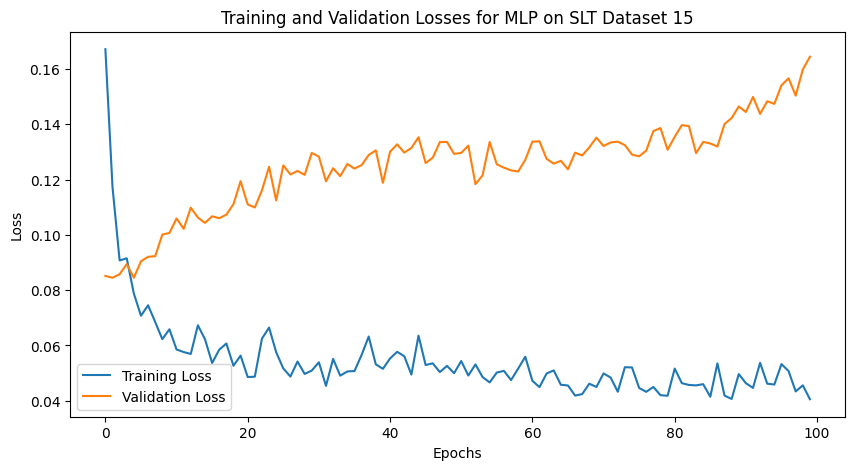

Test Loss: 0.6791
Training on SLT Dataset 16/32
Epoch 1/100, Training Loss: 0.1396, Validation Loss: 0.0896
Epoch 10/100, Training Loss: 0.0533, Validation Loss: 0.1272
Epoch 20/100, Training Loss: 0.0532, Validation Loss: 0.1244
Epoch 30/100, Training Loss: 0.0569, Validation Loss: 0.1290
Epoch 40/100, Training Loss: 0.0537, Validation Loss: 0.1447
Epoch 50/100, Training Loss: 0.0471, Validation Loss: 0.1462
Epoch 60/100, Training Loss: 0.0418, Validation Loss: 0.1478
Epoch 70/100, Training Loss: 0.0424, Validation Loss: 0.1542
Epoch 80/100, Training Loss: 0.0382, Validation Loss: 0.1622
Epoch 90/100, Training Loss: 0.0391, Validation Loss: 0.1661
Epoch 100/100, Training Loss: 0.0368, Validation Loss: 0.1744


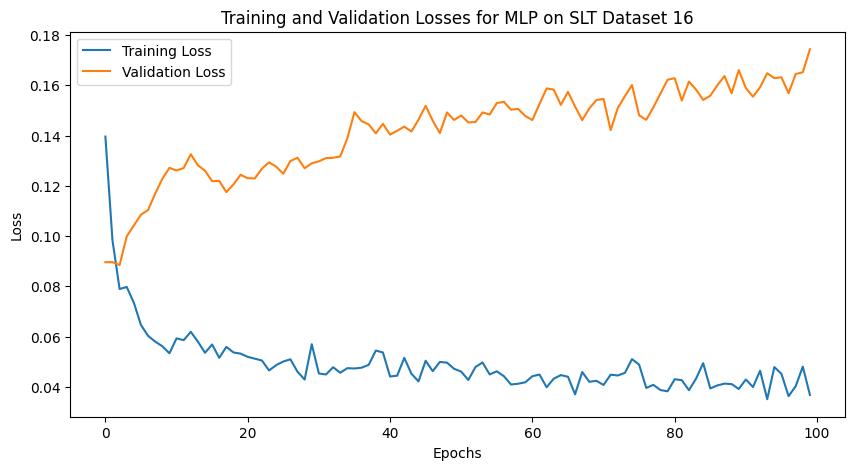

Test Loss: 0.6521
Training on SLT Dataset 17/32
Epoch 1/100, Training Loss: 0.1148, Validation Loss: 0.0785
Epoch 10/100, Training Loss: 0.0495, Validation Loss: 0.0957
Epoch 20/100, Training Loss: 0.0539, Validation Loss: 0.0945
Epoch 30/100, Training Loss: 0.0421, Validation Loss: 0.1048
Epoch 40/100, Training Loss: 0.0467, Validation Loss: 0.1105
Epoch 50/100, Training Loss: 0.0395, Validation Loss: 0.1133
Epoch 60/100, Training Loss: 0.0452, Validation Loss: 0.1255
Epoch 70/100, Training Loss: 0.0420, Validation Loss: 0.1230
Epoch 80/100, Training Loss: 0.0370, Validation Loss: 0.1302
Epoch 90/100, Training Loss: 0.0395, Validation Loss: 0.1314
Epoch 100/100, Training Loss: 0.0416, Validation Loss: 0.1393


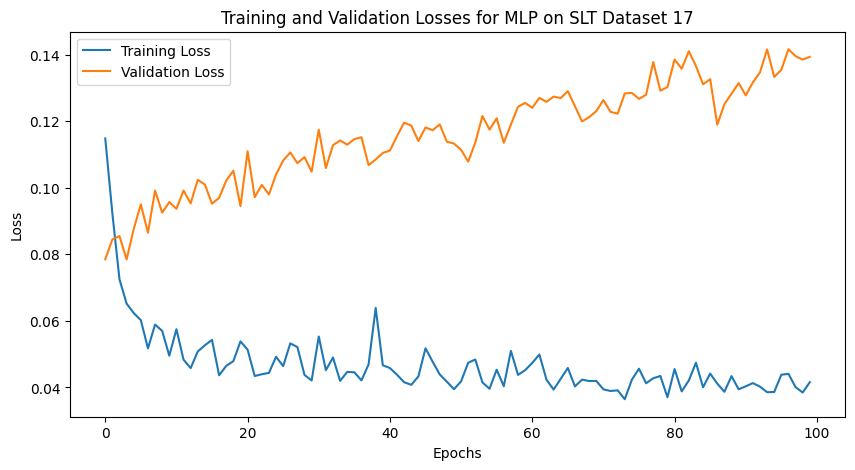

Test Loss: 0.6170
Training on SLT Dataset 18/32
Epoch 1/100, Training Loss: 0.1114, Validation Loss: 0.0329
Epoch 10/100, Training Loss: 0.0548, Validation Loss: 0.0399
Epoch 20/100, Training Loss: 0.0474, Validation Loss: 0.0464
Epoch 30/100, Training Loss: 0.0437, Validation Loss: 0.0556
Epoch 40/100, Training Loss: 0.0409, Validation Loss: 0.0608
Epoch 50/100, Training Loss: 0.0428, Validation Loss: 0.0692
Epoch 60/100, Training Loss: 0.0473, Validation Loss: 0.0706
Epoch 70/100, Training Loss: 0.0387, Validation Loss: 0.0757
Epoch 80/100, Training Loss: 0.0407, Validation Loss: 0.0749
Epoch 90/100, Training Loss: 0.0396, Validation Loss: 0.0798
Epoch 100/100, Training Loss: 0.0353, Validation Loss: 0.0875


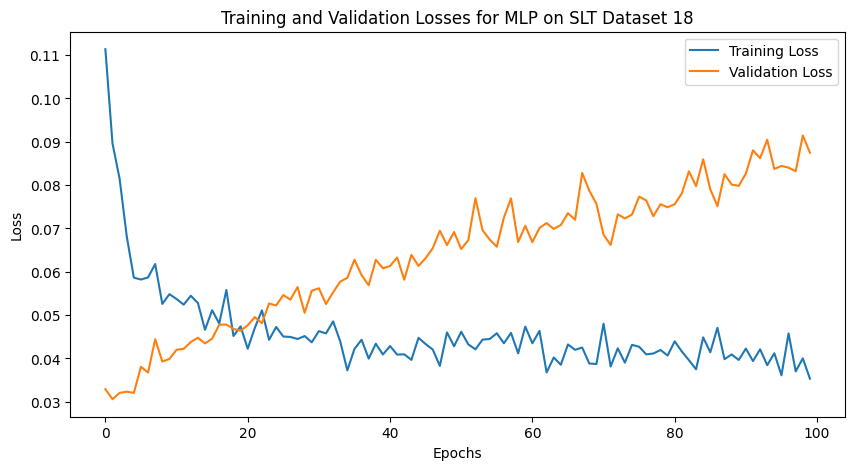

Test Loss: 0.5926
Training on SLT Dataset 19/32
Epoch 1/100, Training Loss: 0.0987, Validation Loss: 0.0485
Epoch 10/100, Training Loss: 0.0444, Validation Loss: 0.0564
Epoch 20/100, Training Loss: 0.0414, Validation Loss: 0.0629
Epoch 30/100, Training Loss: 0.0423, Validation Loss: 0.0713
Epoch 40/100, Training Loss: 0.0401, Validation Loss: 0.0763
Epoch 50/100, Training Loss: 0.0444, Validation Loss: 0.0740
Epoch 60/100, Training Loss: 0.0434, Validation Loss: 0.0750
Epoch 70/100, Training Loss: 0.0476, Validation Loss: 0.0826
Epoch 80/100, Training Loss: 0.0388, Validation Loss: 0.0877
Epoch 90/100, Training Loss: 0.0448, Validation Loss: 0.0980
Epoch 100/100, Training Loss: 0.0357, Validation Loss: 0.0910


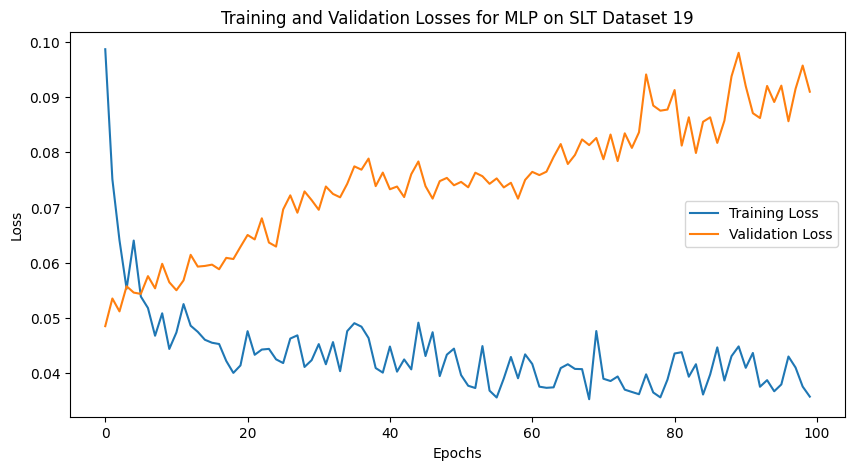

Test Loss: 0.5847
Training on SLT Dataset 20/32
Epoch 1/100, Training Loss: 0.0989, Validation Loss: 0.1197
Epoch 10/100, Training Loss: 0.0461, Validation Loss: 0.1210
Epoch 20/100, Training Loss: 0.0452, Validation Loss: 0.1240
Epoch 30/100, Training Loss: 0.0429, Validation Loss: 0.1223
Epoch 40/100, Training Loss: 0.0410, Validation Loss: 0.1204
Epoch 50/100, Training Loss: 0.0400, Validation Loss: 0.1187
Epoch 60/100, Training Loss: 0.0405, Validation Loss: 0.1212
Epoch 70/100, Training Loss: 0.0373, Validation Loss: 0.1261
Epoch 80/100, Training Loss: 0.0357, Validation Loss: 0.1381
Epoch 90/100, Training Loss: 0.0378, Validation Loss: 0.1425
Epoch 100/100, Training Loss: 0.0360, Validation Loss: 0.1350


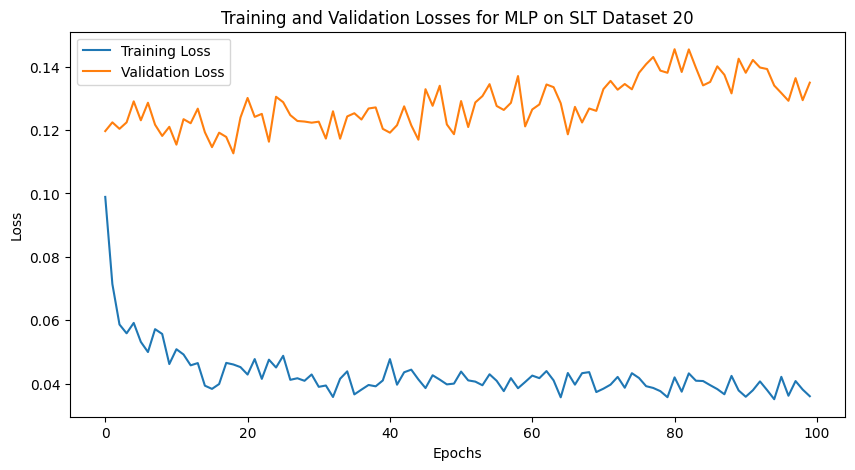

Test Loss: 0.5265
Training on SLT Dataset 21/32
Epoch 1/100, Training Loss: 0.0861, Validation Loss: 0.0340
Epoch 10/100, Training Loss: 0.0426, Validation Loss: 0.0397
Epoch 20/100, Training Loss: 0.0485, Validation Loss: 0.0510
Epoch 30/100, Training Loss: 0.0386, Validation Loss: 0.0535
Epoch 40/100, Training Loss: 0.0461, Validation Loss: 0.0557
Epoch 50/100, Training Loss: 0.0448, Validation Loss: 0.0645
Epoch 60/100, Training Loss: 0.0316, Validation Loss: 0.0633
Epoch 70/100, Training Loss: 0.0355, Validation Loss: 0.0683
Epoch 80/100, Training Loss: 0.0442, Validation Loss: 0.0693
Epoch 90/100, Training Loss: 0.0368, Validation Loss: 0.0716
Epoch 100/100, Training Loss: 0.0353, Validation Loss: 0.0717


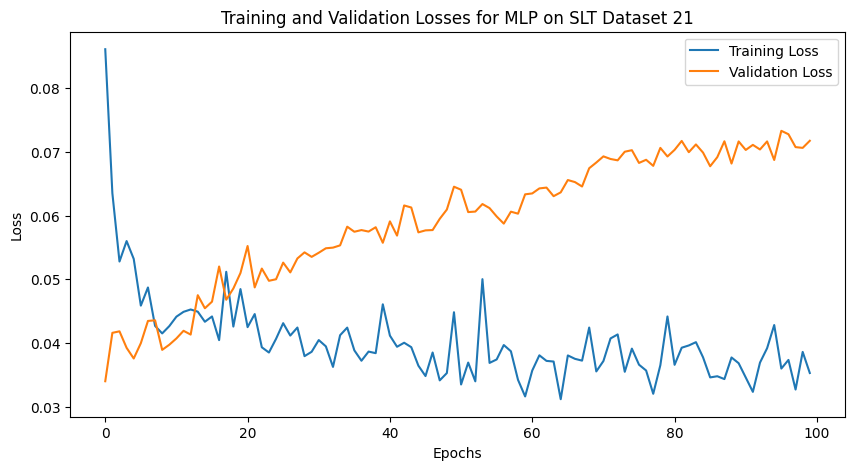

Test Loss: 0.5269
Training on SLT Dataset 22/32
Epoch 1/100, Training Loss: 0.0737, Validation Loss: 0.0361
Epoch 10/100, Training Loss: 0.0437, Validation Loss: 0.0450
Epoch 20/100, Training Loss: 0.0387, Validation Loss: 0.0568
Epoch 30/100, Training Loss: 0.0377, Validation Loss: 0.0664
Epoch 40/100, Training Loss: 0.0399, Validation Loss: 0.0741
Epoch 50/100, Training Loss: 0.0384, Validation Loss: 0.0722
Epoch 60/100, Training Loss: 0.0362, Validation Loss: 0.0796
Epoch 70/100, Training Loss: 0.0360, Validation Loss: 0.0798
Epoch 80/100, Training Loss: 0.0405, Validation Loss: 0.0789
Epoch 90/100, Training Loss: 0.0343, Validation Loss: 0.0821
Epoch 100/100, Training Loss: 0.0390, Validation Loss: 0.0839


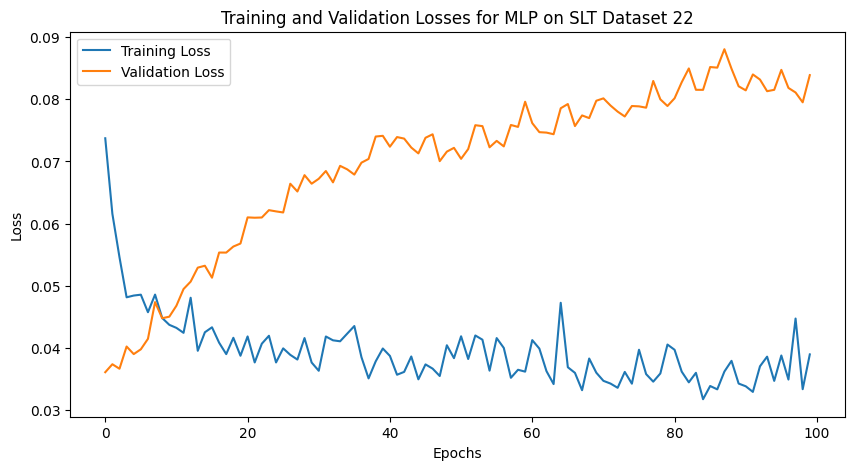

Test Loss: 0.5550
Training on SLT Dataset 23/32
Epoch 1/100, Training Loss: 0.0625, Validation Loss: 0.0221
Epoch 10/100, Training Loss: 0.0460, Validation Loss: 0.0274
Epoch 20/100, Training Loss: 0.0350, Validation Loss: 0.0382
Epoch 30/100, Training Loss: 0.0354, Validation Loss: 0.0400
Epoch 40/100, Training Loss: 0.0313, Validation Loss: 0.0383
Epoch 50/100, Training Loss: 0.0315, Validation Loss: 0.0444
Epoch 60/100, Training Loss: 0.0386, Validation Loss: 0.0461
Epoch 70/100, Training Loss: 0.0385, Validation Loss: 0.0448
Epoch 80/100, Training Loss: 0.0335, Validation Loss: 0.0462
Epoch 90/100, Training Loss: 0.0369, Validation Loss: 0.0457
Epoch 100/100, Training Loss: 0.0336, Validation Loss: 0.0458


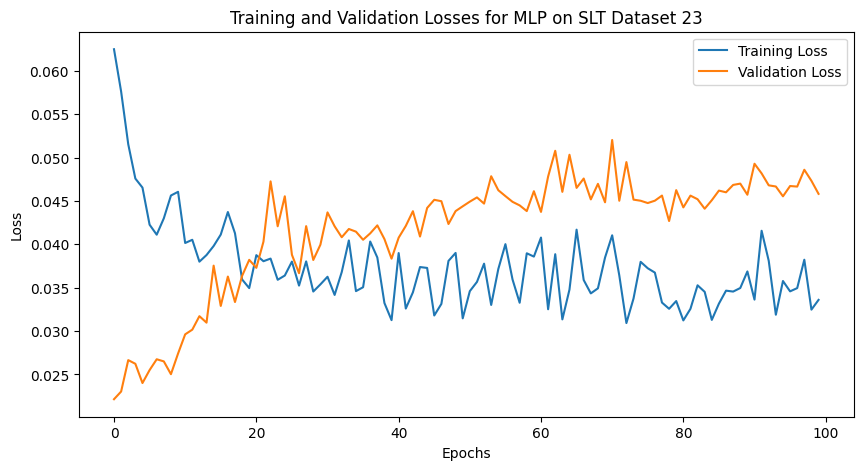

Test Loss: 0.5485
Training on SLT Dataset 24/32
Epoch 1/100, Training Loss: 0.0597, Validation Loss: 0.0216
Epoch 10/100, Training Loss: 0.0374, Validation Loss: 0.0252
Epoch 20/100, Training Loss: 0.0361, Validation Loss: 0.0316
Epoch 30/100, Training Loss: 0.0350, Validation Loss: 0.0331
Epoch 40/100, Training Loss: 0.0320, Validation Loss: 0.0378
Epoch 50/100, Training Loss: 0.0336, Validation Loss: 0.0372
Epoch 60/100, Training Loss: 0.0375, Validation Loss: 0.0394
Epoch 70/100, Training Loss: 0.0361, Validation Loss: 0.0404
Epoch 80/100, Training Loss: 0.0358, Validation Loss: 0.0426
Epoch 90/100, Training Loss: 0.0322, Validation Loss: 0.0450
Epoch 100/100, Training Loss: 0.0326, Validation Loss: 0.0448


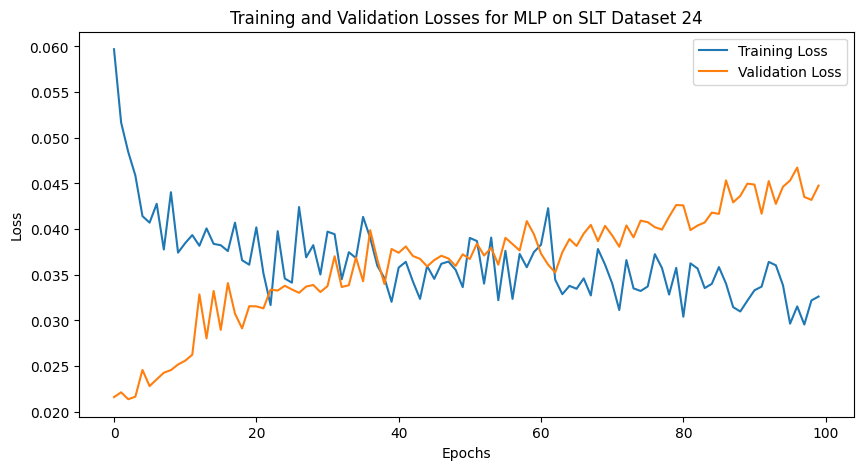

Test Loss: 0.5338
Training on SLT Dataset 25/32
Epoch 1/100, Training Loss: 0.0599, Validation Loss: 0.0302
Epoch 10/100, Training Loss: 0.0410, Validation Loss: 0.0419
Epoch 20/100, Training Loss: 0.0353, Validation Loss: 0.0499
Epoch 30/100, Training Loss: 0.0362, Validation Loss: 0.0580
Epoch 40/100, Training Loss: 0.0349, Validation Loss: 0.0573
Epoch 50/100, Training Loss: 0.0364, Validation Loss: 0.0635
Epoch 60/100, Training Loss: 0.0325, Validation Loss: 0.0615
Epoch 70/100, Training Loss: 0.0383, Validation Loss: 0.0654
Epoch 80/100, Training Loss: 0.0359, Validation Loss: 0.0683
Epoch 90/100, Training Loss: 0.0330, Validation Loss: 0.0731
Epoch 100/100, Training Loss: 0.0341, Validation Loss: 0.0715


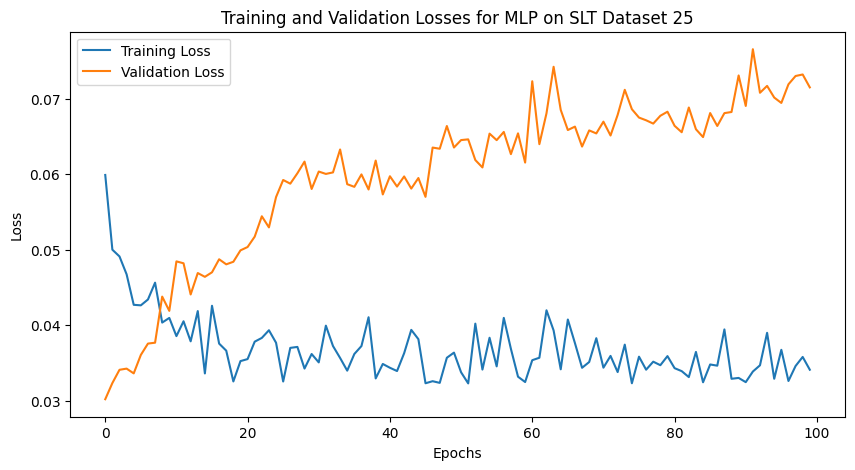

Test Loss: 0.5380
Training on SLT Dataset 26/32
Epoch 1/100, Training Loss: 0.0829, Validation Loss: 0.0275
Epoch 10/100, Training Loss: 0.0410, Validation Loss: 0.0335
Epoch 20/100, Training Loss: 0.0390, Validation Loss: 0.0402
Epoch 30/100, Training Loss: 0.0376, Validation Loss: 0.0469
Epoch 40/100, Training Loss: 0.0374, Validation Loss: 0.0513
Epoch 50/100, Training Loss: 0.0315, Validation Loss: 0.0480
Epoch 60/100, Training Loss: 0.0309, Validation Loss: 0.0511
Epoch 70/100, Training Loss: 0.0330, Validation Loss: 0.0544
Epoch 80/100, Training Loss: 0.0329, Validation Loss: 0.0554
Epoch 90/100, Training Loss: 0.0328, Validation Loss: 0.0599
Epoch 100/100, Training Loss: 0.0300, Validation Loss: 0.0625


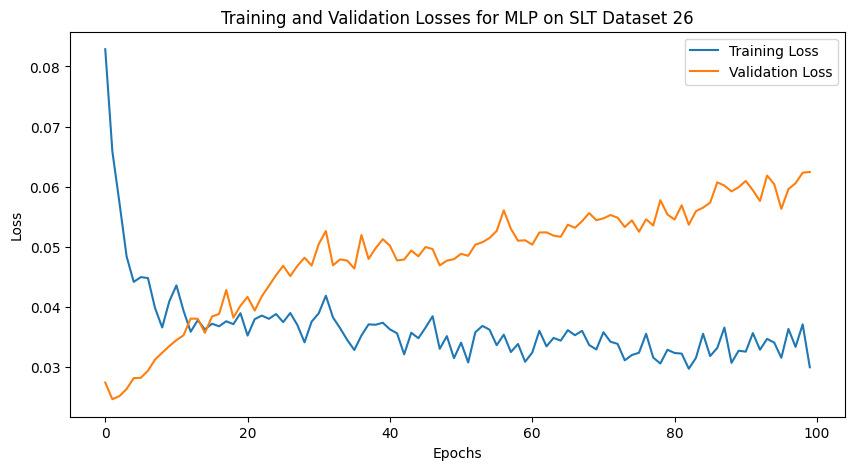

Test Loss: 0.5856
Training on SLT Dataset 27/32
Epoch 1/100, Training Loss: 0.0784, Validation Loss: 0.0397
Epoch 10/100, Training Loss: 0.0464, Validation Loss: 0.0453
Epoch 20/100, Training Loss: 0.0343, Validation Loss: 0.0534
Epoch 30/100, Training Loss: 0.0348, Validation Loss: 0.0555
Epoch 40/100, Training Loss: 0.0301, Validation Loss: 0.0561
Epoch 50/100, Training Loss: 0.0297, Validation Loss: 0.0588
Epoch 60/100, Training Loss: 0.0298, Validation Loss: 0.0593
Epoch 70/100, Training Loss: 0.0318, Validation Loss: 0.0606
Epoch 80/100, Training Loss: 0.0301, Validation Loss: 0.0598
Epoch 90/100, Training Loss: 0.0283, Validation Loss: 0.0642
Epoch 100/100, Training Loss: 0.0322, Validation Loss: 0.0654


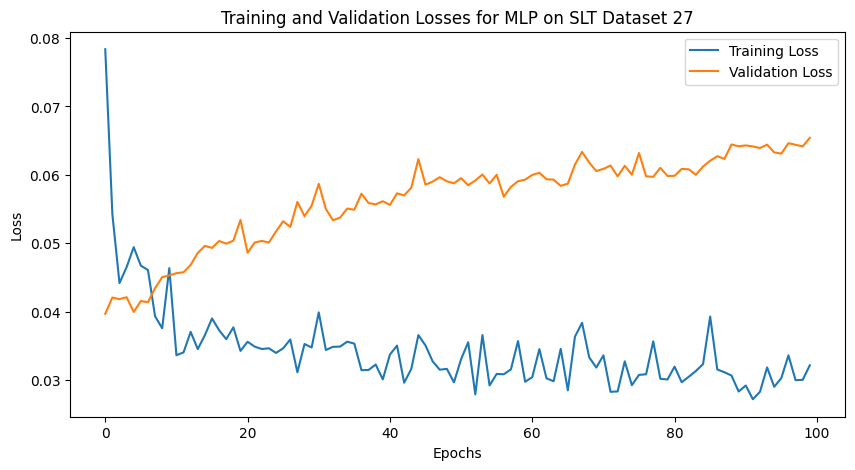

Test Loss: 0.5840
Training on SLT Dataset 28/32
Epoch 1/100, Training Loss: 0.0686, Validation Loss: 0.0341
Epoch 10/100, Training Loss: 0.0401, Validation Loss: 0.0486
Epoch 20/100, Training Loss: 0.0349, Validation Loss: 0.0585
Epoch 30/100, Training Loss: 0.0364, Validation Loss: 0.0607
Epoch 40/100, Training Loss: 0.0365, Validation Loss: 0.0609
Epoch 50/100, Training Loss: 0.0331, Validation Loss: 0.0614
Epoch 60/100, Training Loss: 0.0351, Validation Loss: 0.0622
Epoch 70/100, Training Loss: 0.0312, Validation Loss: 0.0661
Epoch 80/100, Training Loss: 0.0304, Validation Loss: 0.0682
Epoch 90/100, Training Loss: 0.0309, Validation Loss: 0.0672
Epoch 100/100, Training Loss: 0.0314, Validation Loss: 0.0708


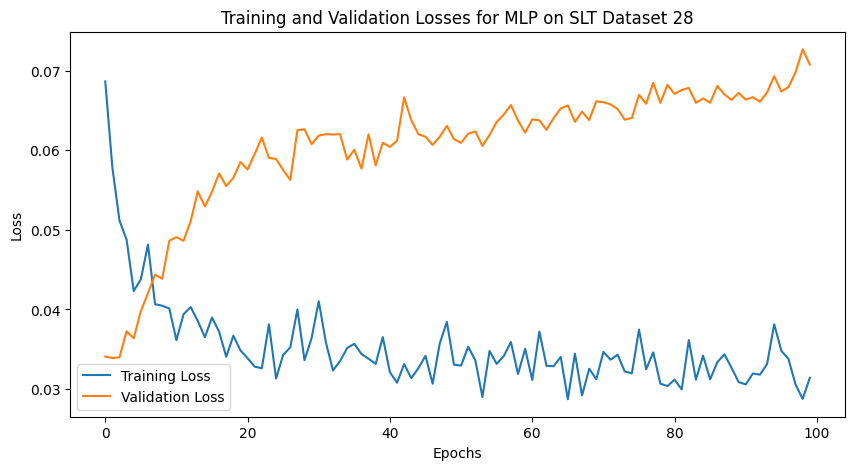

Test Loss: 0.5950
Training on SLT Dataset 29/32
Epoch 1/100, Training Loss: 0.0654, Validation Loss: 0.0193
Epoch 10/100, Training Loss: 0.0414, Validation Loss: 0.0295
Epoch 20/100, Training Loss: 0.0349, Validation Loss: 0.0367
Epoch 30/100, Training Loss: 0.0333, Validation Loss: 0.0407
Epoch 40/100, Training Loss: 0.0319, Validation Loss: 0.0468
Epoch 50/100, Training Loss: 0.0374, Validation Loss: 0.0468
Epoch 60/100, Training Loss: 0.0366, Validation Loss: 0.0499
Epoch 70/100, Training Loss: 0.0312, Validation Loss: 0.0506
Epoch 80/100, Training Loss: 0.0364, Validation Loss: 0.0544
Epoch 90/100, Training Loss: 0.0316, Validation Loss: 0.0544
Epoch 100/100, Training Loss: 0.0319, Validation Loss: 0.0550


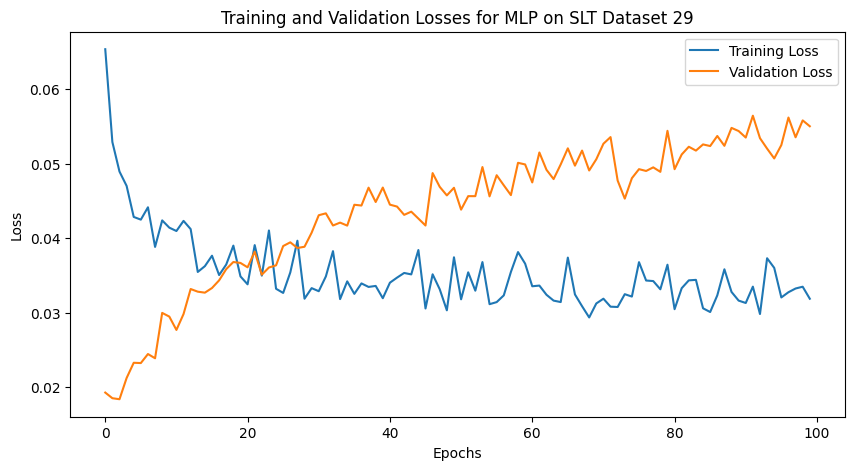

Test Loss: 0.5962
Training on SLT Dataset 30/32
Epoch 1/100, Training Loss: 0.0676, Validation Loss: 0.0209
Epoch 10/100, Training Loss: 0.0409, Validation Loss: 0.0295
Epoch 20/100, Training Loss: 0.0359, Validation Loss: 0.0367
Epoch 30/100, Training Loss: 0.0341, Validation Loss: 0.0389
Epoch 40/100, Training Loss: 0.0340, Validation Loss: 0.0389
Epoch 50/100, Training Loss: 0.0365, Validation Loss: 0.0403
Epoch 60/100, Training Loss: 0.0331, Validation Loss: 0.0417
Epoch 70/100, Training Loss: 0.0369, Validation Loss: 0.0428
Epoch 80/100, Training Loss: 0.0304, Validation Loss: 0.0453
Epoch 90/100, Training Loss: 0.0345, Validation Loss: 0.0462
Epoch 100/100, Training Loss: 0.0305, Validation Loss: 0.0480


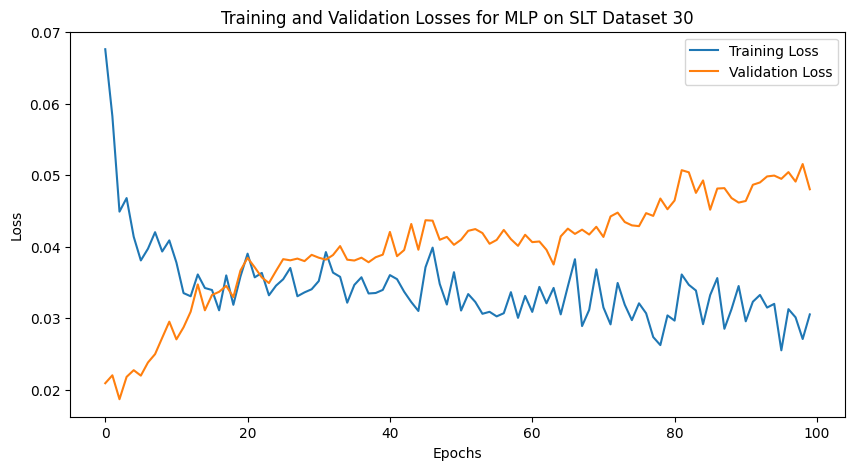

Test Loss: 0.5749
Training on SLT Dataset 31/32
Epoch 1/100, Training Loss: 0.0706, Validation Loss: 0.0307
Epoch 10/100, Training Loss: 0.0331, Validation Loss: 0.0390
Epoch 20/100, Training Loss: 0.0330, Validation Loss: 0.0392
Epoch 30/100, Training Loss: 0.0304, Validation Loss: 0.0384
Epoch 40/100, Training Loss: 0.0344, Validation Loss: 0.0423
Epoch 50/100, Training Loss: 0.0271, Validation Loss: 0.0455
Epoch 60/100, Training Loss: 0.0305, Validation Loss: 0.0447
Epoch 70/100, Training Loss: 0.0339, Validation Loss: 0.0466
Epoch 80/100, Training Loss: 0.0283, Validation Loss: 0.0449
Epoch 90/100, Training Loss: 0.0274, Validation Loss: 0.0490
Epoch 100/100, Training Loss: 0.0293, Validation Loss: 0.0488


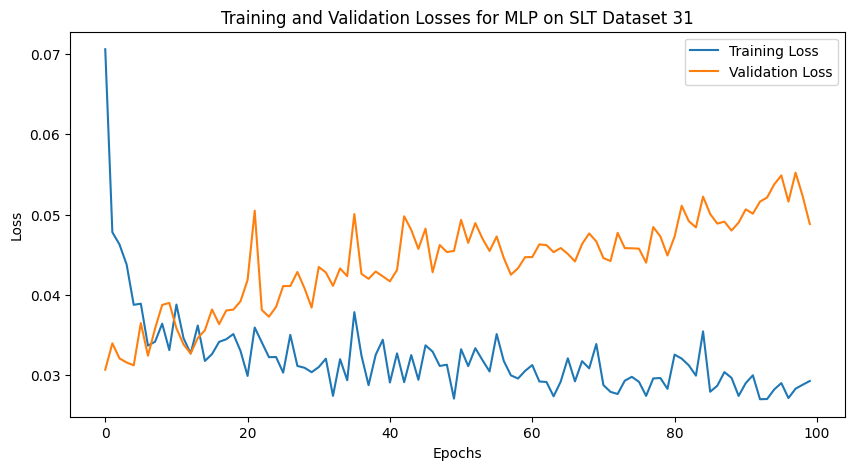

Test Loss: 0.5985
Training on SLT Dataset 32/32
Epoch 1/100, Training Loss: 0.1310, Validation Loss: 0.0531
Epoch 10/100, Training Loss: 0.0458, Validation Loss: 0.0432
Epoch 20/100, Training Loss: 0.0363, Validation Loss: 0.0557
Epoch 30/100, Training Loss: 0.0378, Validation Loss: 0.0684
Epoch 40/100, Training Loss: 0.0295, Validation Loss: 0.0654
Epoch 50/100, Training Loss: 0.0326, Validation Loss: 0.0712
Epoch 60/100, Training Loss: 0.0327, Validation Loss: 0.0692
Epoch 70/100, Training Loss: 0.0334, Validation Loss: 0.0707
Epoch 80/100, Training Loss: 0.0316, Validation Loss: 0.0764
Epoch 90/100, Training Loss: 0.0344, Validation Loss: 0.0749
Epoch 100/100, Training Loss: 0.0313, Validation Loss: 0.0758


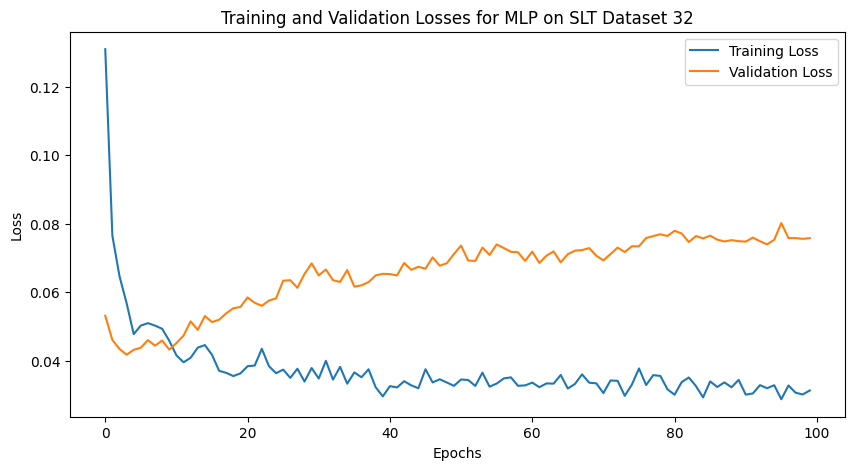

Test Loss: 0.5514


In [123]:
# Training Loops: single MLP.
in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
smlp_test_losses = []
model = MLP(in_dim, hid_dims, out_dim, dropout) 

for i, (train_loader, valid_loader) in enumerate(zip(slt_train_dataloaders, slt_valid_dataloaders)):
    print(f"Training on SLT Dataset {i+1}/{len(slt_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, epochs=epochs, title=f"MLP on SLT Dataset {i+1}")
    test_loss = evaluate_on_test(model, slt_pooled_test_dataloader, device)
    smlp_test_losses.append(test_loss)

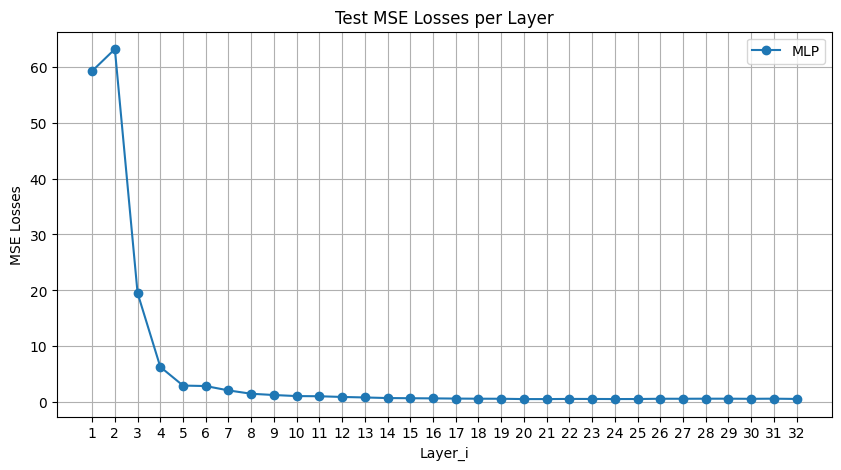

In [124]:
# plot_1d_metrics([[smlp_test_losses[4]]*3 + mlp_test_losses[4:]], ['MLP'], 'MSE Losses')
plot_1d_metrics([smlp_test_losses], ['MLP'], 'MSE Losses')

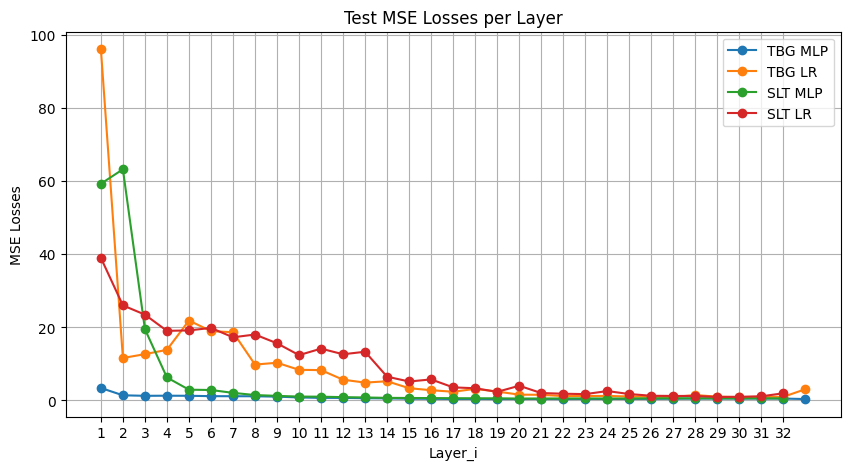

In [130]:
# Plot all MSE losses from MLP and LR on TBG and SLT.
plot_1d_metrics([tmlp_test_losses, lr_test_losses, smlp_test_losses, slr_test_losses], ['TBG MLP','TBG LR',
                                                                                     'SLT MLP','SLT LR'], 'MSE Losses',
               save_fig=True)

It is often the case that validation losses **do not decrease** over epochs and appear to be quite random. It might be due to OOD issue.

In [143]:
# Binarized entropy classification with SLT token.
slt_train_dataloaders, slt_valid_dataloaders, slt_pooled_test_dataloader = create_dataloaders(slt_layered_datasets, bca_entropy, total_size, batch_size)

Using device: cuda
Training on SLT Dataset 1/32
Epoch 1/100, Training Loss: 60.9492, Validation Loss: 47.6306, Training Accuracy: 0.5114
Epoch 10/100, Training Loss: 60.4348, Validation Loss: 47.2826, Training Accuracy: 0.6486
Epoch 20/100, Training Loss: 60.2960, Validation Loss: 47.1599, Training Accuracy: 0.6814
Epoch 30/100, Training Loss: 60.1488, Validation Loss: 47.1357, Training Accuracy: 0.6850
Epoch 40/100, Training Loss: 60.0708, Validation Loss: 47.1078, Training Accuracy: 0.6943
Epoch 50/100, Training Loss: 60.0098, Validation Loss: 47.0807, Training Accuracy: 0.7014
Epoch 60/100, Training Loss: 59.9438, Validation Loss: 47.0622, Training Accuracy: 0.7057
Epoch 70/100, Training Loss: 59.8908, Validation Loss: 47.0812, Training Accuracy: 0.7014
Epoch 80/100, Training Loss: 59.8982, Validation Loss: 47.0429, Training Accuracy: 0.6993
Epoch 90/100, Training Loss: 59.8187, Validation Loss: 47.0721, Training Accuracy: 0.7086
Epoch 100/100, Training Loss: 59.7708, Validation Los

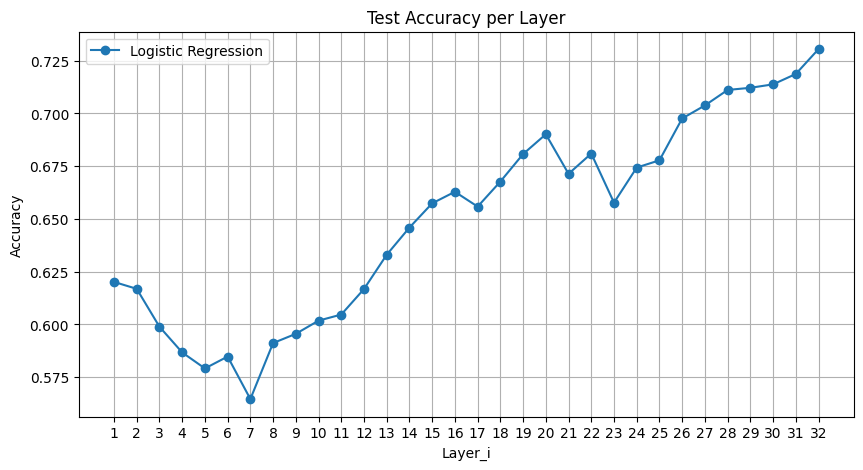

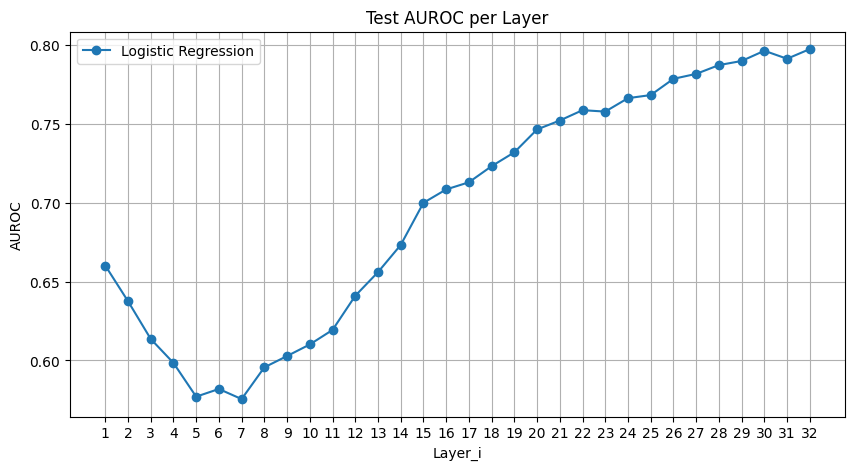

In [144]:
# Training with a single LR on all datasets.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
sblr_test_accs = []
sblr_test_aucs = []
model = LogisticRegression(in_dim, out_dim)

for i, (train_loader, valid_loader) in enumerate(zip(slt_train_dataloaders, slt_valid_dataloaders)):
    print(f"Training on SLT Dataset {i+1}/{len(slt_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"Logistic Regression on SLT Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(model, slt_pooled_test_dataloader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    sblr_test_accs.append(test_acc)
    sblr_test_aucs.append(test_auc)

plot_1d_metrics([sblr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([sblr_test_aucs], ['Logistic Regression'], 'AUROC')

Using device: cuda
Training on SLT Dataset 1/32
Epoch 1/100, Training Loss: 60.7619, Validation Loss: 47.2770, Training Accuracy: 0.5693
Epoch 10/100, Training Loss: 58.2931, Validation Loss: 47.3702, Training Accuracy: 0.8014
Epoch 20/100, Training Loss: 57.5603, Validation Loss: 47.6151, Training Accuracy: 0.8486
Epoch 30/100, Training Loss: 57.0133, Validation Loss: 47.3216, Training Accuracy: 0.8936
Epoch 40/100, Training Loss: 56.8578, Validation Loss: 46.9402, Training Accuracy: 0.9014
Epoch 50/100, Training Loss: 56.8118, Validation Loss: 47.4702, Training Accuracy: 0.9043
Epoch 60/100, Training Loss: 56.5052, Validation Loss: 47.1791, Training Accuracy: 0.9200
Epoch 70/100, Training Loss: 56.6125, Validation Loss: 47.3612, Training Accuracy: 0.9121
Epoch 80/100, Training Loss: 56.4079, Validation Loss: 47.3640, Training Accuracy: 0.9293
Epoch 90/100, Training Loss: 56.2726, Validation Loss: 47.1933, Training Accuracy: 0.9357
Epoch 100/100, Training Loss: 56.3016, Validation Los

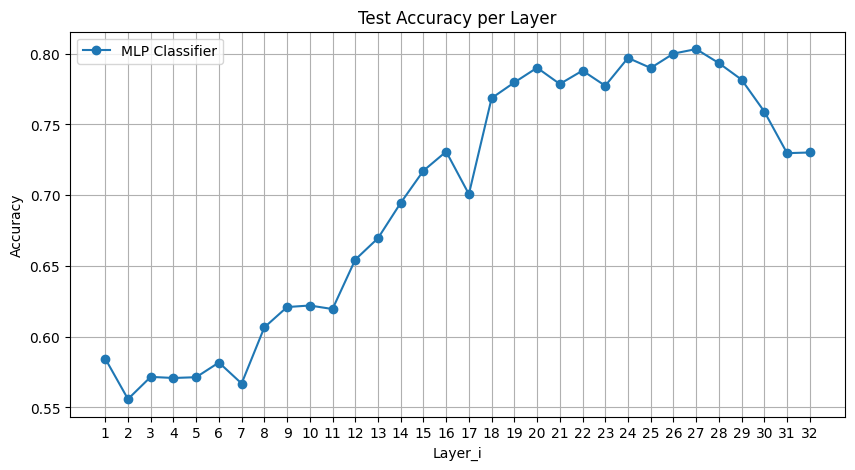

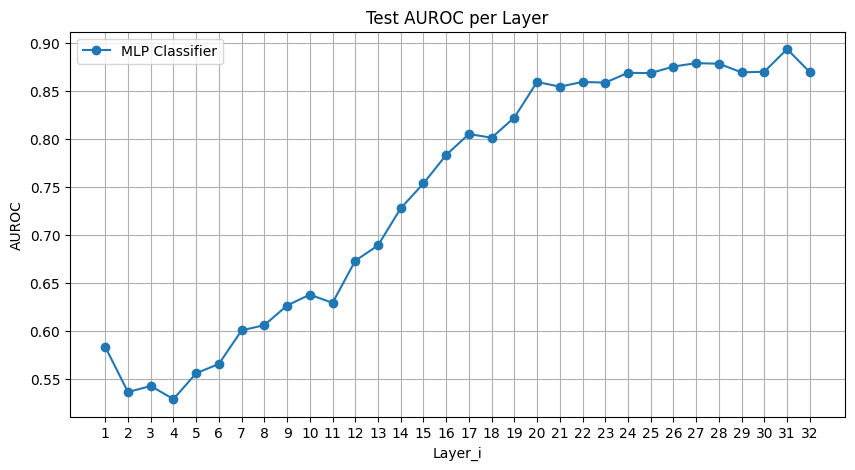

In [145]:
# Training with a single MLP on all datasets.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
sbmlp_test_accs = []
sbmlp_test_aucs = []
model = MLPClassifier(in_dim, hid_dims, dropout)

for i, (train_loader, valid_loader) in enumerate(zip(slt_train_dataloaders, slt_valid_dataloaders)):
    print(f"Training on SLT Dataset {i+1}/{len(slt_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on SLT Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(model, slt_pooled_test_dataloader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    sbmlp_test_accs.append(test_acc)
    sbmlp_test_aucs.append(test_auc)

plot_1d_metrics([sbmlp_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([sbmlp_test_aucs], ['MLP Classifier'], 'AUROC')

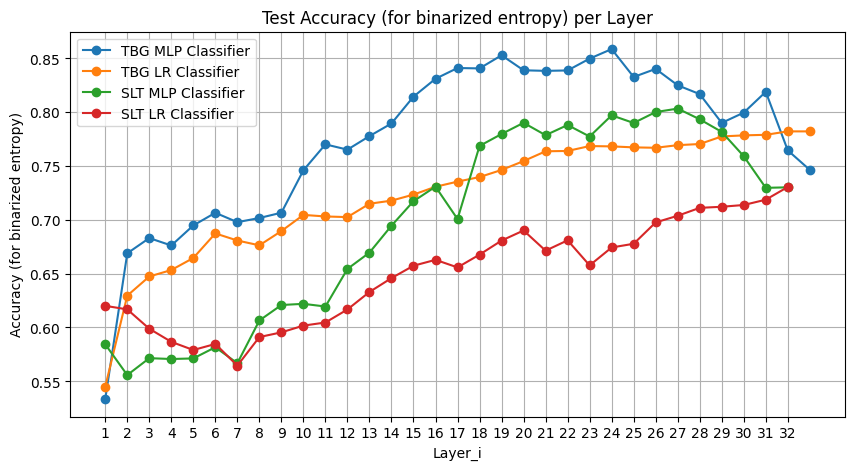

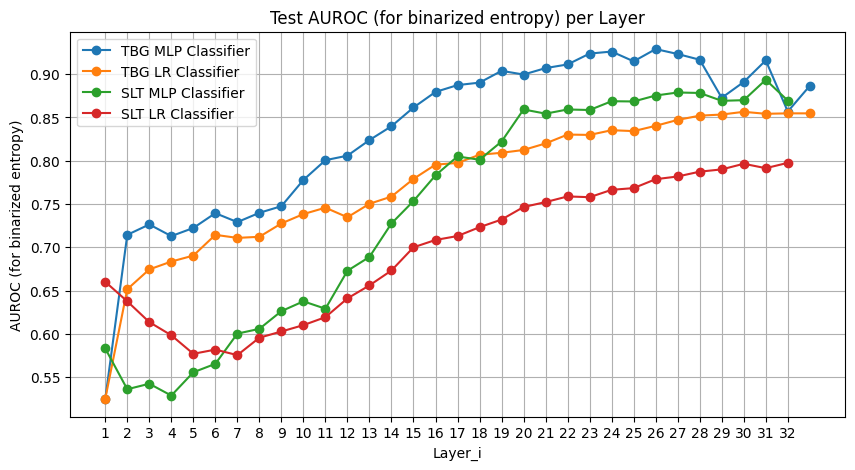

In [146]:
plot_1d_metrics([tbmlp_test_accs, tblr_test_accs, sbmlp_test_accs, sblr_test_accs], ['TBG MLP Classifier','TBG LR Classifier',
                                                                                     'SLT MLP Classifier','SLT LR Classifier'], 'Accuracy (for binarized entropy)',
               save_fig=True)

plot_1d_metrics([tbmlp_test_aucs, tblr_test_aucs, sbmlp_test_aucs, sblr_test_aucs], ['TBG MLP Classifier','TBG LR Classifier',
                                                                                     'SLT MLP Classifier','SLT LR Classifier'], 'AUROC (for binarized entropy)',
               save_fig=True)

## Use Linear Probe for Predicting Correctness of Generated Answers (or Accuracy)

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

We will use logistic regression for this task, and the binarized entropy prediction task from above.

### Token Before first Generation (TBG)

In [70]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([2000]) tensor([1., 1., 1., 1., 0., 0., 0., 0., 0., 0.])


In [147]:
# Create data loaders from tbg embeddings
tbg_train_dataloaders, tbg_valid_dataloaders, tbg_pooled_test_dataloader = create_dataloaders(tok_bef_gen_layered_datasets, accuracies, total_size, batch_size)

In [78]:
# Dummy accuracy.
corrects = 0
total = 0
for _, labels in tbg_pooled_test_dataloader:
    corrects += (labels > 0.0).int().sum()
    total += labels.size(0)
print(f"Dummy accuracy: {float(max(1-corrects/total,corrects/total)):.4f}")

Dummy accuracy: 0.5875


Using device: cuda
Training on TBG-Acc Dataset 1/33
Epoch 1/100, Training Loss: 46.0512, Validation Loss: 37.9164, Training Accuracy: 0.5379
Epoch 10/100, Training Loss: 45.4812, Validation Loss: 37.7179, Training Accuracy: 0.6193
Epoch 20/100, Training Loss: 45.1204, Validation Loss: 37.7147, Training Accuracy: 0.6443
Epoch 30/100, Training Loss: 44.8989, Validation Loss: 37.7264, Training Accuracy: 0.6764
Epoch 40/100, Training Loss: 44.6300, Validation Loss: 37.7337, Training Accuracy: 0.7000
Epoch 50/100, Training Loss: 44.4883, Validation Loss: 37.7503, Training Accuracy: 0.7157
Epoch 60/100, Training Loss: 44.3320, Validation Loss: 37.7552, Training Accuracy: 0.7236
Epoch 70/100, Training Loss: 44.1497, Validation Loss: 37.7634, Training Accuracy: 0.7329
Epoch 80/100, Training Loss: 44.0933, Validation Loss: 37.7680, Training Accuracy: 0.7364
Epoch 90/100, Training Loss: 43.9596, Validation Loss: 37.7840, Training Accuracy: 0.7379
Epoch 100/100, Training Loss: 43.9206, Validation

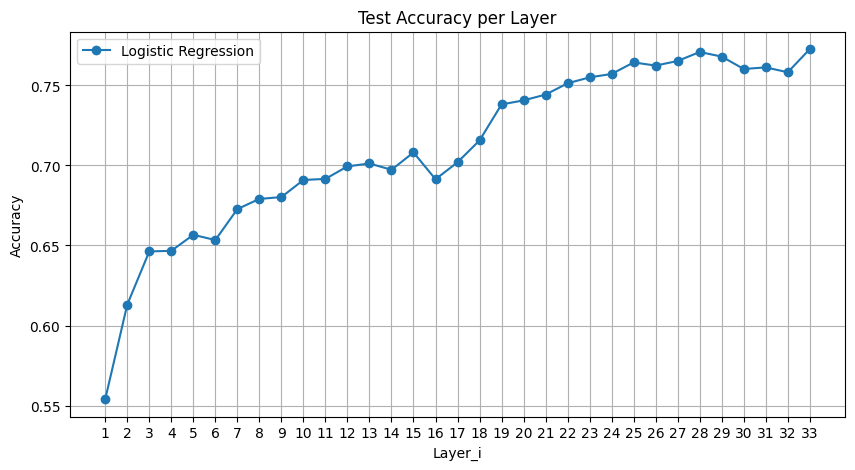

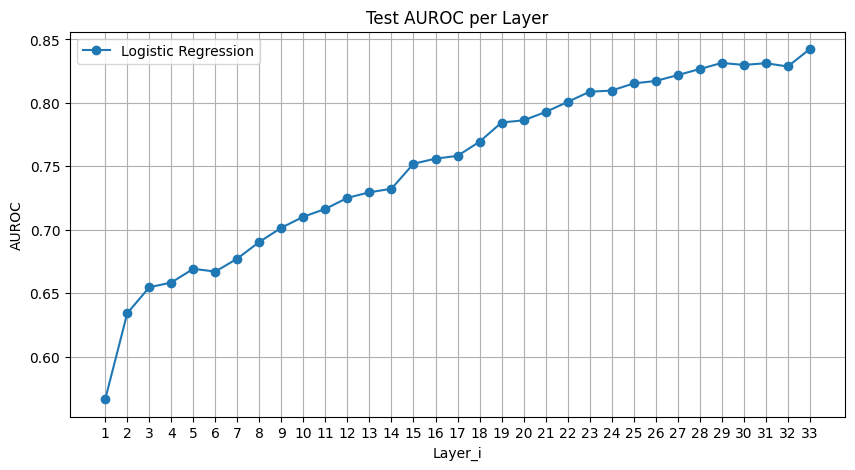

In [148]:
# Training Loops (Single LR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
talr_test_accs = []
talr_test_aucs = []
model = LogisticRegression(in_dim, out_dim)

for i, (train_loader, valid_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(tbg_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"Logistic Regression on TBG-Acc Dataset {i+1}", silent=True) # enable loss plots with silent=False
    test_loss, test_acc, test_auc = evaluate_on_test(model, tbg_pooled_test_dataloader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    talr_test_accs.append(test_acc)
    talr_test_aucs.append(test_auc)

plot_1d_metrics([talr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([talr_test_aucs], ['Logistic Regression'], 'AUROC')

Using device: cuda
Training on TBG-Acc Dataset 1/33
Epoch 1/100, Training Loss: 46.0611, Validation Loss: 37.5944, Training Accuracy: 0.5136
Epoch 10/100, Training Loss: 43.3624, Validation Loss: 37.8259, Training Accuracy: 0.7286
Epoch 20/100, Training Loss: 43.1955, Validation Loss: 37.9953, Training Accuracy: 0.7557
Epoch 30/100, Training Loss: 43.2448, Validation Loss: 38.3063, Training Accuracy: 0.7429
Epoch 40/100, Training Loss: 43.1980, Validation Loss: 38.0437, Training Accuracy: 0.7507
Epoch 50/100, Training Loss: 43.2025, Validation Loss: 38.0836, Training Accuracy: 0.7479
Epoch 60/100, Training Loss: 43.2368, Validation Loss: 38.2306, Training Accuracy: 0.7429
Epoch 70/100, Training Loss: 43.1443, Validation Loss: 38.1116, Training Accuracy: 0.7464
Epoch 80/100, Training Loss: 43.1370, Validation Loss: 37.7932, Training Accuracy: 0.7557
Epoch 90/100, Training Loss: 43.1847, Validation Loss: 37.9796, Training Accuracy: 0.7457
Epoch 100/100, Training Loss: 43.1470, Validation

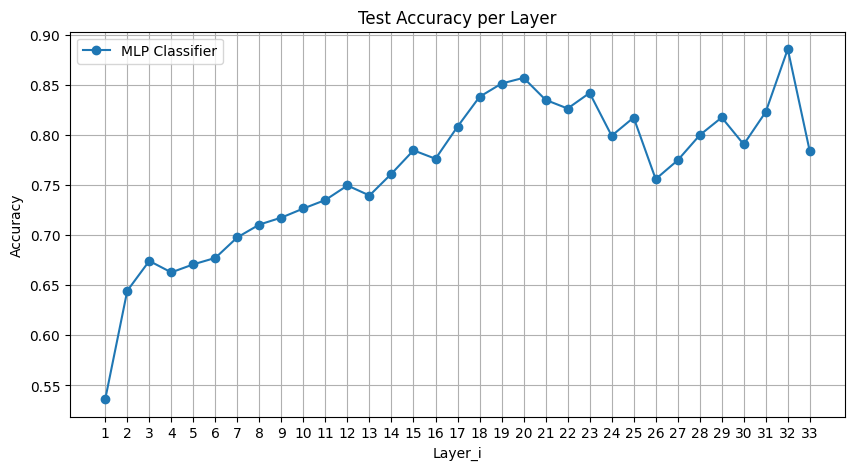

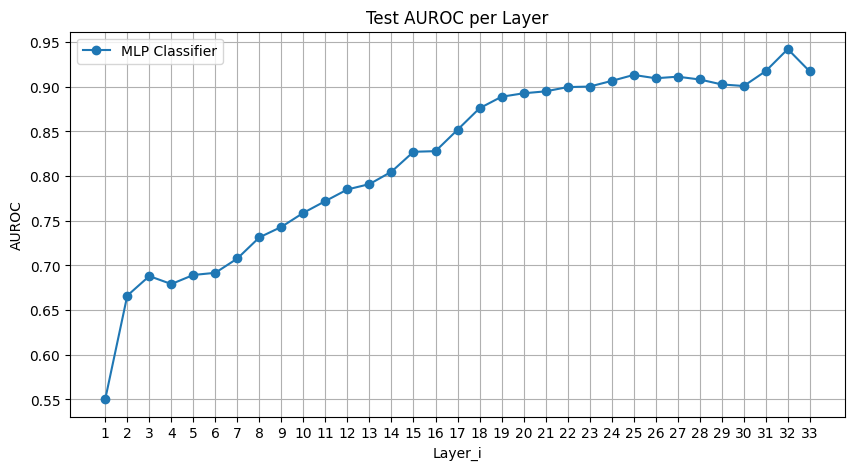

In [149]:
# Training with a single MLP.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
tamlp_test_accs = []
tamlp_test_aucs = []
model = MLPClassifier(in_dim, hid_dims, dropout)

for i, (train_loader, valid_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(tbg_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on TBG-Acc Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(model, tbg_pooled_test_dataloader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tamlp_test_accs.append(test_acc)
    tamlp_test_aucs.append(test_auc)

plot_1d_metrics([tamlp_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([tamlp_test_aucs], ['MLP Classifier'], 'AUROC')

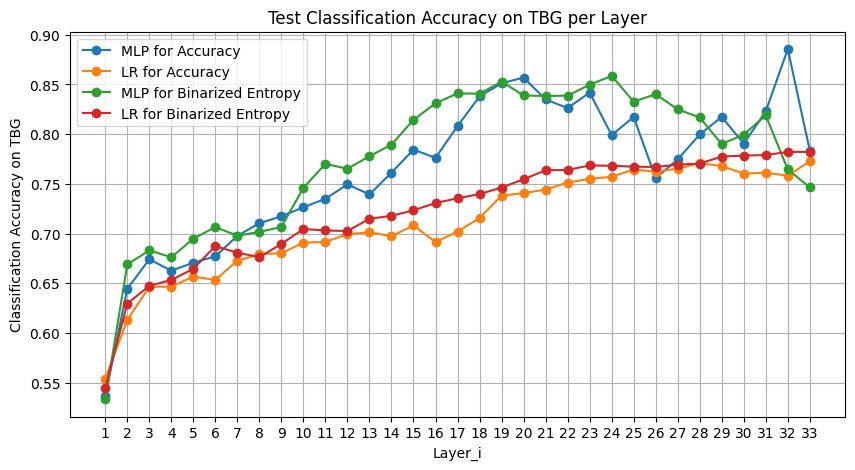

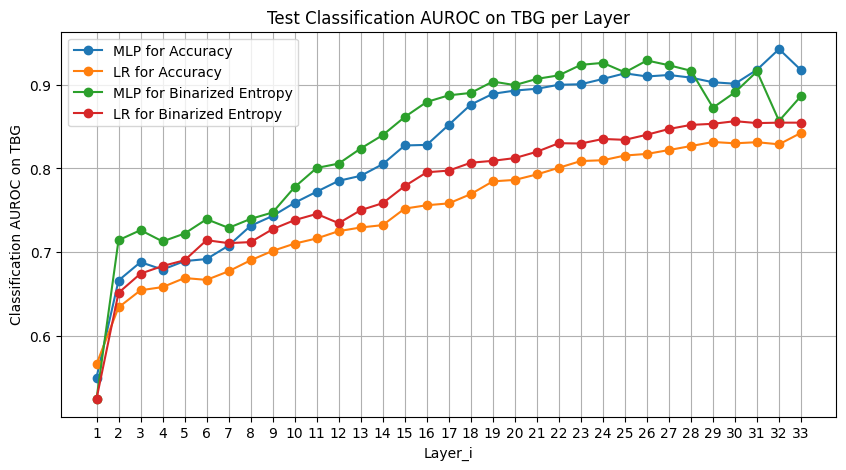

In [150]:
plot_1d_metrics([tamlp_test_accs, talr_test_accs, tbmlp_test_accs, tblr_test_accs], ['MLP for Accuracy','LR for Accuracy',
                                                                                     'MLP for Binarized Entropy','LR for Binarized Entropy'],
                'Classification Accuracy on TBG',
                save_fig=True)

plot_1d_metrics([tamlp_test_aucs, talr_test_aucs, tbmlp_test_aucs, tblr_test_aucs], ['MLP for Accuracy','LR for Accuracy',
                                                                                     'MLP for Binarized Entropy','LR for Binarized Entropy'],
                'Classification AUROC on TBG',
                save_fig=True)

We observe that for each model type, the classification accuracy over layers are **quite aligned** for both binarized entropy scores and accuracy scores. 

### Second Last Generated Token (SLT)

In [151]:
slt_train_dataloaders, slt_valid_dataloaders, slt_pooled_test_dataloader = create_dataloaders(slt_layered_datasets, accuracies, total_size, batch_size)

Using device: cuda
Training on SLT-Acc Dataset 1/32
Epoch 1/100, Training Loss: 44.8679, Validation Loss: 42.3178, Training Accuracy: 0.5321
Epoch 10/100, Training Loss: 44.4698, Validation Loss: 42.1431, Training Accuracy: 0.5907
Epoch 20/100, Training Loss: 44.3322, Validation Loss: 42.0977, Training Accuracy: 0.6071
Epoch 30/100, Training Loss: 44.1907, Validation Loss: 42.0926, Training Accuracy: 0.6321
Epoch 40/100, Training Loss: 44.1224, Validation Loss: 42.1069, Training Accuracy: 0.6443
Epoch 50/100, Training Loss: 44.0323, Validation Loss: 42.1204, Training Accuracy: 0.6536
Epoch 60/100, Training Loss: 43.9624, Validation Loss: 42.1157, Training Accuracy: 0.6429
Epoch 70/100, Training Loss: 43.8854, Validation Loss: 42.1284, Training Accuracy: 0.6586
Epoch 80/100, Training Loss: 43.8651, Validation Loss: 42.1276, Training Accuracy: 0.6614
Epoch 90/100, Training Loss: 43.8488, Validation Loss: 42.1320, Training Accuracy: 0.6636
Epoch 100/100, Training Loss: 43.7897, Validation

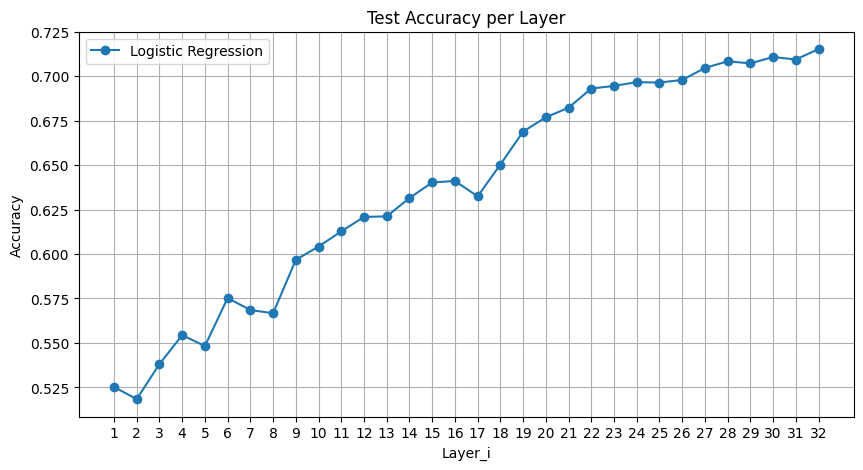

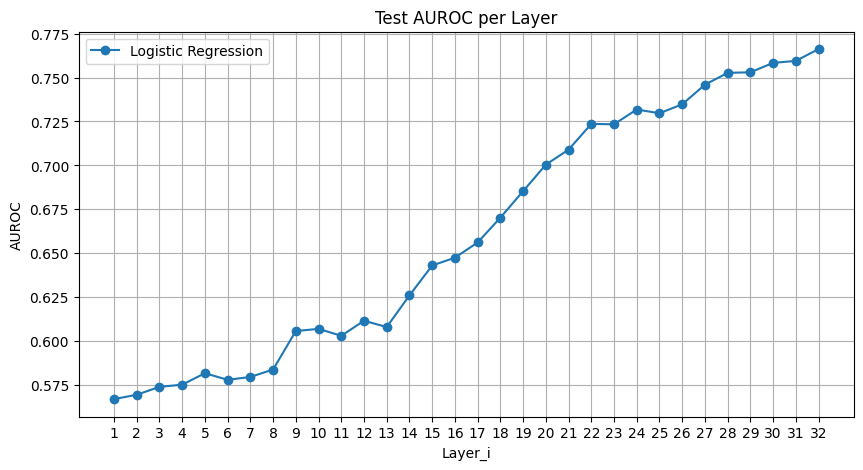

In [152]:
# Training with a single LR on all datasets.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [2048, 1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
salr_test_accs = []
salr_test_aucs = []
model = LogisticRegression(in_dim, out_dim)

for i, (train_loader, valid_loader) in enumerate(zip(slt_train_dataloaders, slt_valid_dataloaders)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(slt_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"Logistic Regression on SLT-Acc Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(model, slt_pooled_test_dataloader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    salr_test_accs.append(test_acc)
    salr_test_aucs.append(test_auc)

plot_1d_metrics([salr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([salr_test_aucs], ['Logistic Regression'], 'AUROC')

Using device: cuda
Training on SLT-Acc Dataset 1/32
Epoch 1/100, Training Loss: 44.8687, Validation Loss: 42.0384, Training Accuracy: 0.5121
Epoch 10/100, Training Loss: 42.2786, Validation Loss: 42.7462, Training Accuracy: 0.7757
Epoch 20/100, Training Loss: 41.4036, Validation Loss: 42.2892, Training Accuracy: 0.8336
Epoch 30/100, Training Loss: 40.7839, Validation Loss: 42.7560, Training Accuracy: 0.8671
Epoch 40/100, Training Loss: 40.3593, Validation Loss: 42.3456, Training Accuracy: 0.9007
Epoch 50/100, Training Loss: 40.1678, Validation Loss: 42.3897, Training Accuracy: 0.9193
Epoch 60/100, Training Loss: 40.0199, Validation Loss: 42.4099, Training Accuracy: 0.9279
Epoch 70/100, Training Loss: 40.1744, Validation Loss: 42.1812, Training Accuracy: 0.9121
Epoch 80/100, Training Loss: 39.8459, Validation Loss: 42.4160, Training Accuracy: 0.9386
Epoch 90/100, Training Loss: 40.2598, Validation Loss: 42.6518, Training Accuracy: 0.9057
Epoch 100/100, Training Loss: 40.0111, Validation

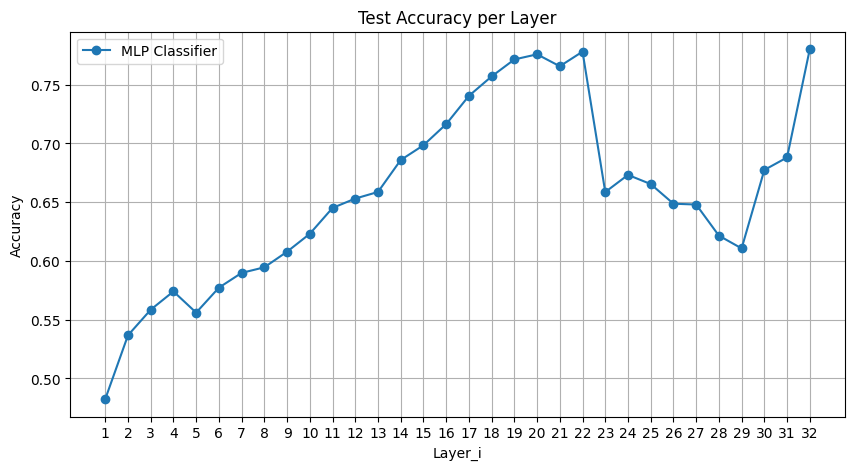

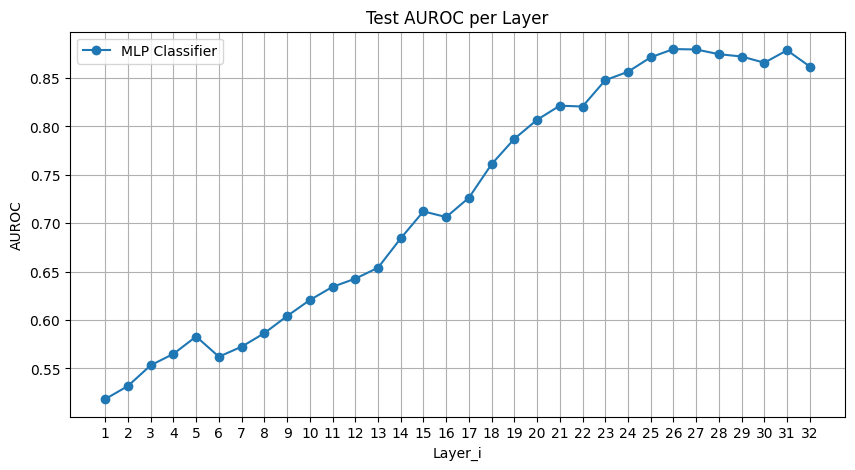

In [153]:
# Training with a single MLP.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
samlp_test_accs = []
samlp_test_aucs = []
model = MLPClassifier(in_dim, hid_dims, dropout)

for i, (train_loader, valid_loader) in enumerate(zip(slt_train_dataloaders, slt_valid_dataloaders)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(slt_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on SLT-Acc Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(model, slt_pooled_test_dataloader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    samlp_test_accs.append(test_acc)
    samlp_test_aucs.append(test_auc)

plot_1d_metrics([samlp_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([samlp_test_aucs], ['MLP Classifier'], 'AUROC')

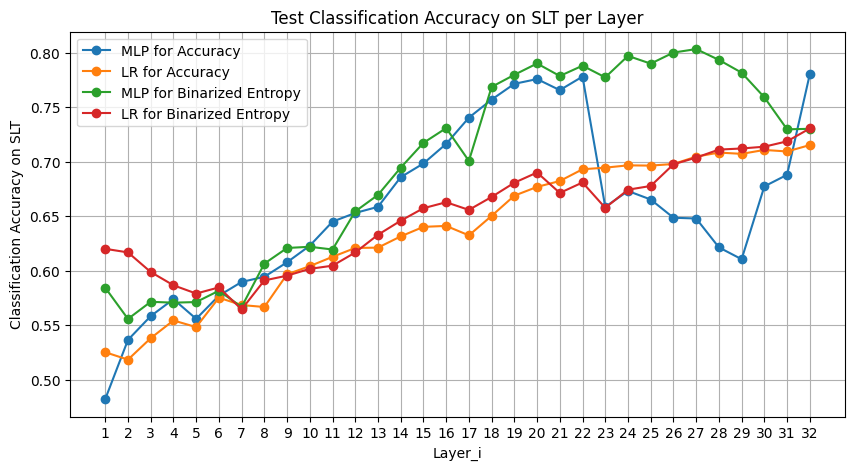

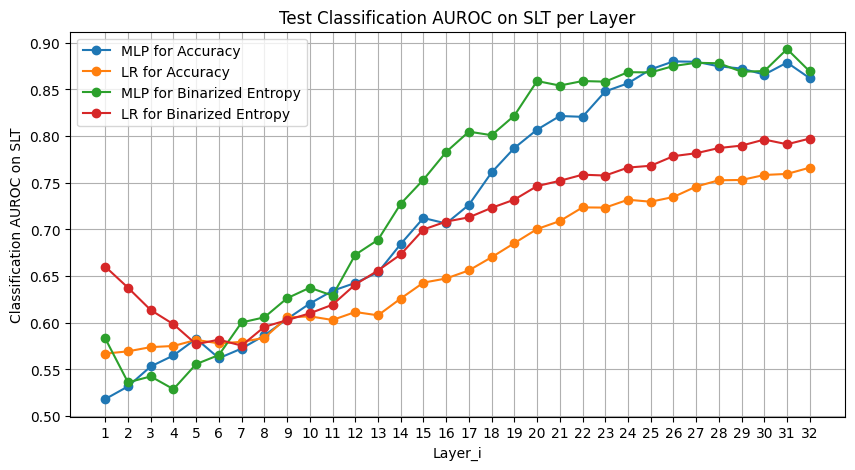

In [154]:
plot_1d_metrics([samlp_test_accs, salr_test_accs, sbmlp_test_accs, sblr_test_accs], ['MLP for Accuracy','LR for Accuracy',
                                                                                     'MLP for Binarized Entropy','LR for Binarized Entropy'],
                'Classification Accuracy on SLT',
                save_fig=True)

plot_1d_metrics([samlp_test_aucs, salr_test_aucs, sbmlp_test_aucs, sblr_test_aucs], ['MLP for Accuracy','LR for Accuracy',
                                                                                     'MLP for Binarized Entropy','LR for Binarized Entropy'],
                'Classification AUROC on SLT',
                save_fig=True)

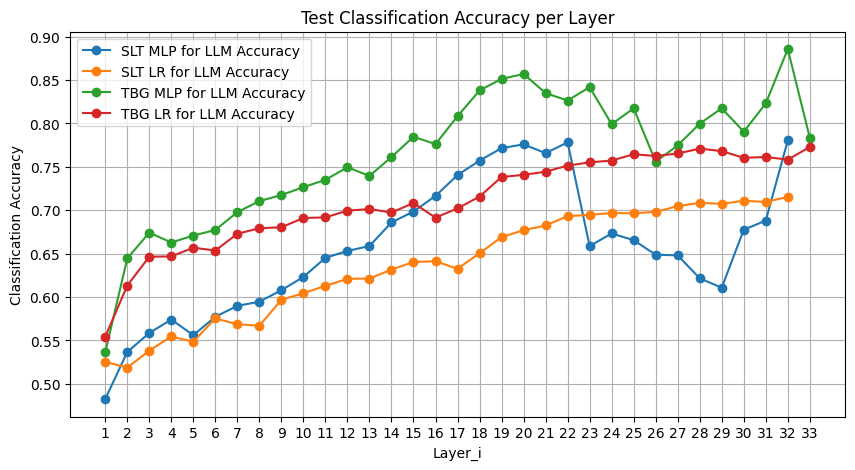

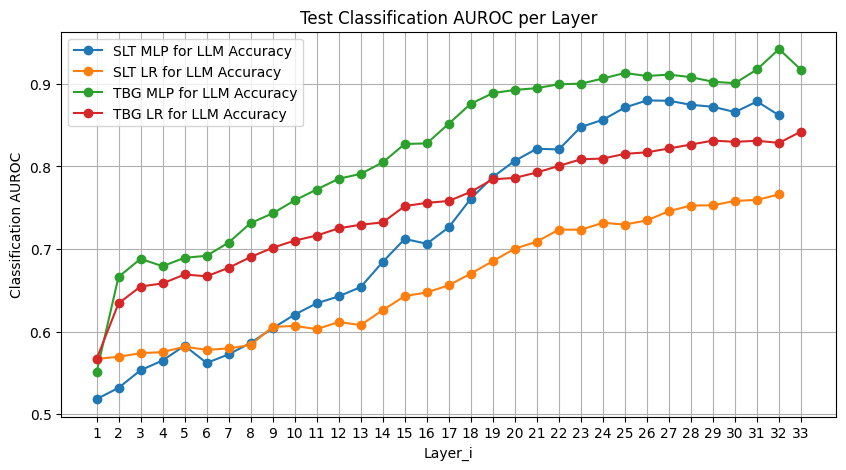

In [155]:
# Compare SLT and TBG performances on predicting acc.
plot_1d_metrics([samlp_test_accs, salr_test_accs, tamlp_test_accs, talr_test_accs], ['SLT MLP for LLM Accuracy','SLT LR for LLM Accuracy',
                                                                                     'TBG MLP for LLM Accuracy','TBG LR for LLM Accuracy'],
                'Classification Accuracy',
                save_fig=True)

plot_1d_metrics([samlp_test_aucs, salr_test_aucs, tamlp_test_aucs, talr_test_aucs], ['SLT MLP for LLM Accuracy','SLT LR for LLM Accuracy',
                                                                                     'TBG MLP for LLM Accuracy','TBG LR for LLM Accuracy'],
                'Classification AUROC',
                save_fig=True)

In [116]:
# Test correlation between binary SE and accuracy
from scipy.stats import pearsonr
correlation, p_value = pearsonr(bca_entropy.tolist(), accuracies.tolist())

print(f'Correlation: {correlation}')
print(f'p-value: {p_value}')

Correlation: -0.45456858843497516
p-value: 1.472429833930329e-102


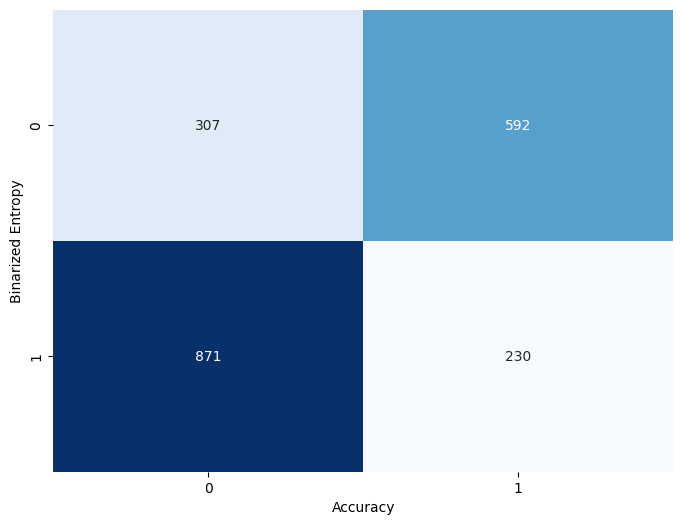

In [135]:
# Create a scatter plot of the binary SE against accuracies
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(bca_entropy.tolist(), accuracies.tolist())

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues', cbar=False)
# plt.title('Confusion Matrix')
plt.ylabel('Binarized Entropy')
plt.xlabel('Accuracy')
plt.show()

## Use Classifier for Binary SE for Predicting LLM Accuracy

We want to show that models trained on binary SE are more generalizable to new LLMs or new datasets when predicting their generation correctness.

We will first test this idea on TBG embeddings.

In [ ]:
# Train LR with TBG embeddings for binary SE.
tbg_train_dataloaders, tbg_valid_dataloaders, _ = create_dataloaders(tok_bef_gen_layered_datasets, bca_entropy, total_size, batch_size, set_seed=True)
# Test with accuracy test set (with the same random seed to ensure no data leakage)
# We should reverse the accuracy due to negative R.
r_accuracies = 1 - accuracies
_, _, tbg_pooled_test_dataloader = create_dataloaders(tok_bef_gen_layered_datasets, r_accuracies, total_size, batch_size, set_seed=True)

Using device: cuda
Training on TBG Dataset 1/33
Epoch 1/100, Training Loss: 59.5534, Validation Loss: 52.4306, Training Accuracy: 0.5564
Epoch 10/100, Training Loss: 58.8456, Validation Loss: 52.0294, Training Accuracy: 0.6579
Epoch 20/100, Training Loss: 58.4752, Validation Loss: 51.9284, Training Accuracy: 0.6871
Epoch 30/100, Training Loss: 58.2635, Validation Loss: 51.9318, Training Accuracy: 0.7164
Epoch 40/100, Training Loss: 58.1034, Validation Loss: 51.9386, Training Accuracy: 0.7293
Epoch 50/100, Training Loss: 57.9321, Validation Loss: 51.9235, Training Accuracy: 0.7450
Epoch 60/100, Training Loss: 57.7779, Validation Loss: 51.9585, Training Accuracy: 0.7529
Epoch 70/100, Training Loss: 57.6845, Validation Loss: 51.9796, Training Accuracy: 0.7586
Epoch 80/100, Training Loss: 57.6404, Validation Loss: 51.9925, Training Accuracy: 0.7629
Epoch 90/100, Training Loss: 57.5047, Validation Loss: 52.0168, Training Accuracy: 0.7671
Epoch 100/100, Training Loss: 57.4338, Validation Los

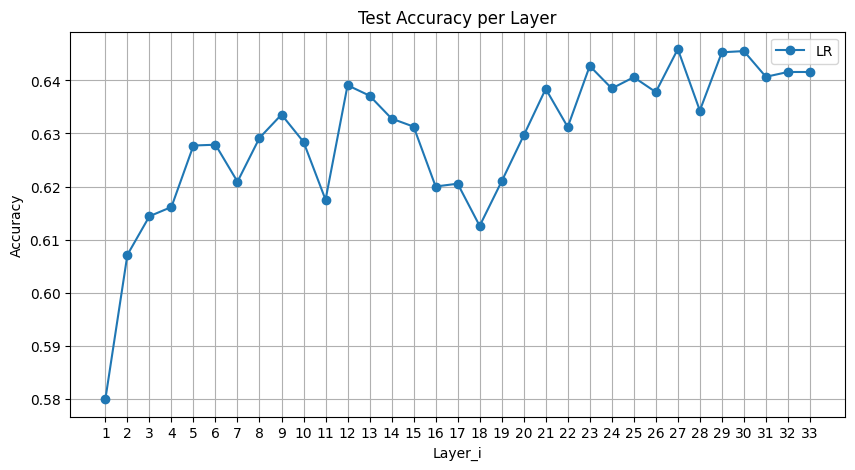

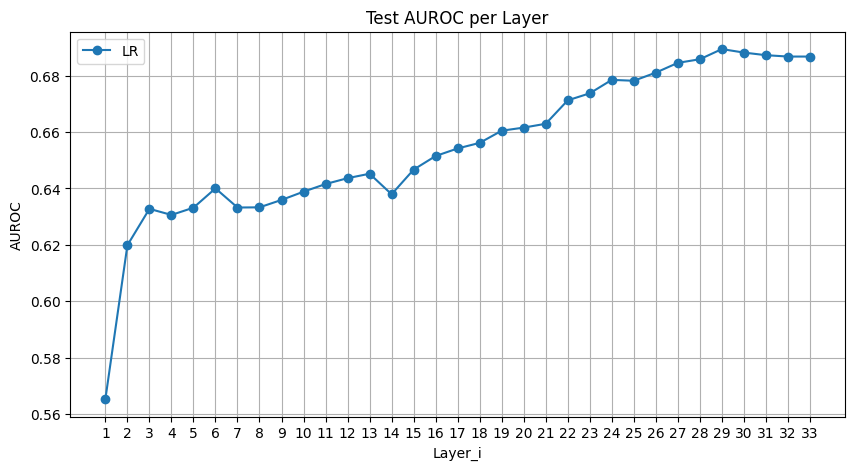

In [163]:
# Training Loops (Single LR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
tab_model = LogisticRegression(in_dim, out_dim)
tablr_test_accs = []
tablr_test_aucs = []

for i, (train_loader, valid_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders)):
    print(f"Training on TBG Dataset {i+1}/{len(tbg_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(tab_model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"Logistic Regression on TBG Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(tab_model, tbg_pooled_test_dataloader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tablr_test_accs.append(test_acc)
    tablr_test_aucs.append(test_auc)

plot_1d_metrics([tablr_test_accs], ['LR'], 'Accuracy')
plot_1d_metrics([tablr_test_aucs], ['LR'], 'AUROC')

Using device: cuda
Training on TBG Dataset 1/33
Epoch 1/100, Training Loss: 59.2937, Validation Loss: 52.0934, Training Accuracy: 0.5764
Epoch 10/100, Training Loss: 57.0902, Validation Loss: 52.2337, Training Accuracy: 0.7579
Epoch 20/100, Training Loss: 56.8722, Validation Loss: 52.5895, Training Accuracy: 0.7743
Epoch 30/100, Training Loss: 56.9082, Validation Loss: 52.4695, Training Accuracy: 0.7657
Epoch 40/100, Training Loss: 56.9330, Validation Loss: 52.4789, Training Accuracy: 0.7586
Epoch 50/100, Training Loss: 56.7999, Validation Loss: 52.5743, Training Accuracy: 0.7729
Epoch 60/100, Training Loss: 56.8267, Validation Loss: 52.5554, Training Accuracy: 0.7650
Epoch 70/100, Training Loss: 56.8271, Validation Loss: 52.4548, Training Accuracy: 0.7614
Epoch 80/100, Training Loss: 56.7758, Validation Loss: 52.5355, Training Accuracy: 0.7700
Epoch 90/100, Training Loss: 56.8162, Validation Loss: 52.5973, Training Accuracy: 0.7521
Epoch 100/100, Training Loss: 56.7214, Validation Los

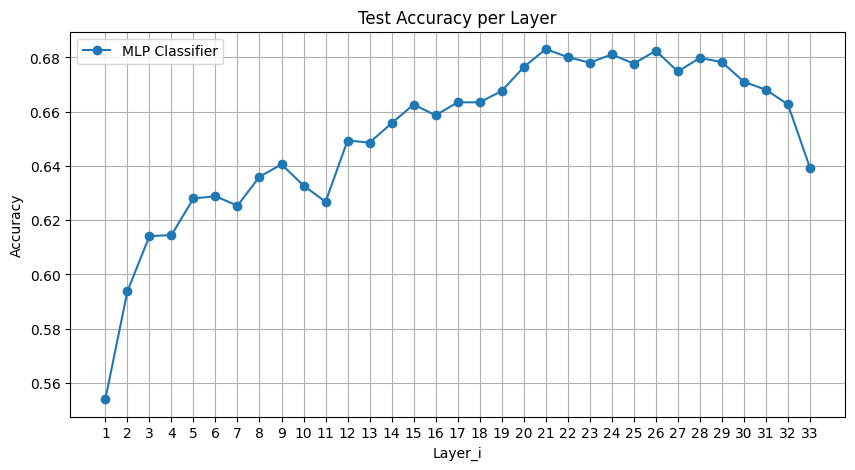

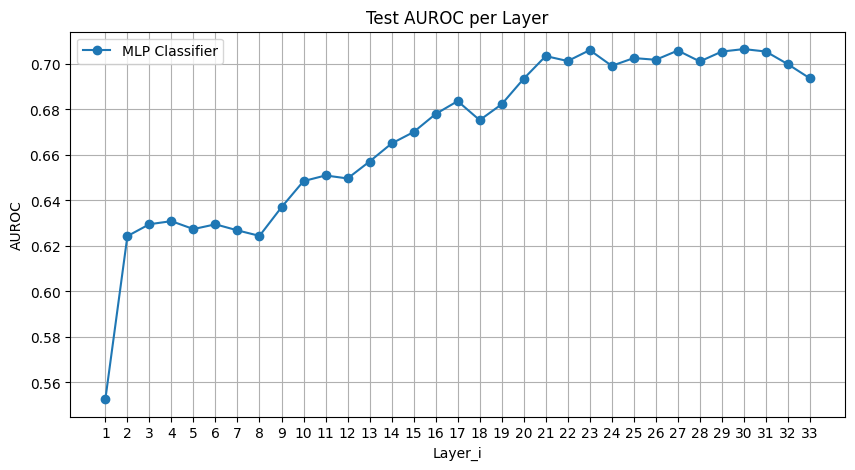

In [164]:
# Training Loops (Single MLP)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

in_dim = 4544   # Token embedding dimensions (e.g. Falcon-7B: 4544)
hid_dims = [1024, 512]
out_dim = 1    # Output dimension (scalar for semantic entropy)
dropout = 0.5  # Dropout rate

epochs = 100
tab_model = MLPClassifier(in_dim, hid_dims, dropout)
tabmlp_test_accs = []
tabmlp_test_aucs = []

for i, (train_loader, valid_loader) in enumerate(zip(tbg_train_dataloaders, tbg_valid_dataloaders)):
    print(f"Training on TBG Dataset {i+1}/{len(tbg_train_dataloaders)}")
    train_losses, valid_losses = train_and_evaluate(tab_model, train_loader, valid_loader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True,
                                                    epochs=epochs, title=f"MLP Classifier on TBG Dataset {i+1}", silent=True)
    test_loss, test_acc, test_auc = evaluate_on_test(tab_model, tbg_pooled_test_dataloader, device, criterion=nn.CrossEntropyLoss(), binary_cls=True)
    tabmlp_test_accs.append(test_acc)
    tabmlp_test_aucs.append(test_auc)

plot_1d_metrics([tabmlp_test_accs], ['MLP Classifier'], 'Accuracy')
plot_1d_metrics([tabmlp_test_aucs], ['MLP Classifier'], 'AUROC')

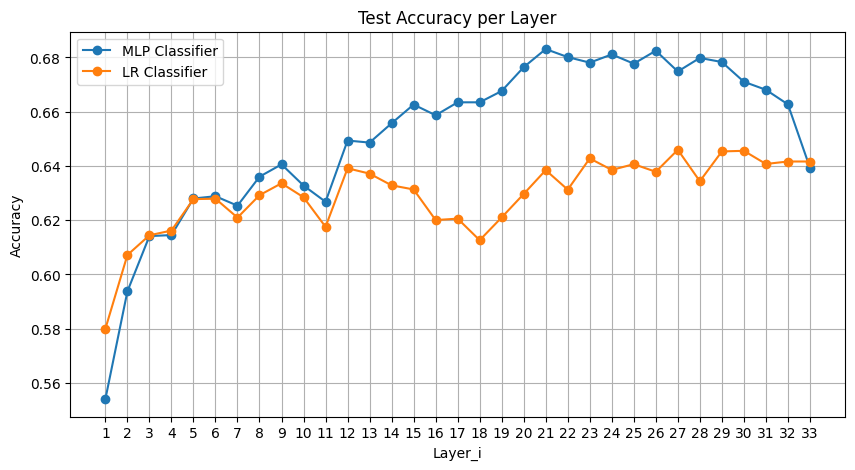

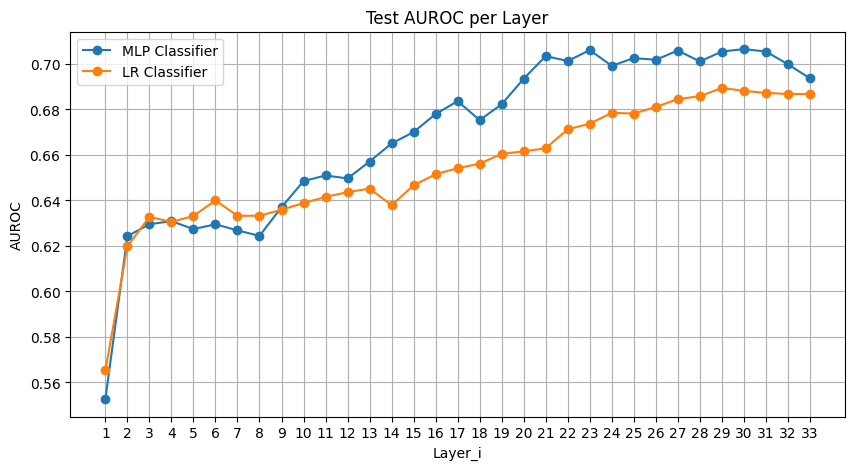

In [165]:
plot_1d_metrics([tabmlp_test_accs, tablr_test_accs], ['MLP Classifier','LR Classifier'], 'Accuracy')
plot_1d_metrics([tabmlp_test_aucs, tablr_test_aucs], ['MLP Classifier','LR Classifier'], 'AUROC')